In [10]:
import os
import glob

import tables as tb
import numpy  as np
import pandas as pd
from matplotlib.ticker import AutoMinorLocator


from scipy.interpolate import interp1d


from collections import defaultdict

from scipy import interpolate
from scipy.interpolate import UnivariateSpline
import scipy.optimize
from scipy.optimize import curve_fit

import matplotlib        as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
%matplotlib notebook
%matplotlib inline
### Useful parameters for plots
mpl.rcParams["figure.figsize"]          = 12,10
mpl.rcParams["font.size"]               = 20
mpl.rcParams["figure.max_open_warning"] = 100
mpl.rcParams["font.size"]               = 20
mpl.rcParams["font.weight"]             ='normal'
mpl.rcParams["axes.labelweight"] = "normal"
mpl.rcParams['axes.facecolor'] = 'w'
mpl.rcParams['figure.facecolor'] = 'w';

import invisible_cities.io.pmaps_io as pmapio
import invisible_cities.io.dst_io  as dstio
import invisible_cities.io.mcinfo_io as mcio
import gres.database.load_db as db
import invisible_cities.io.run_and_event_io as rio
import invisible_cities.core.fit_functions as fitf
import invisible_cities.core.core_functions as coref

from lmfit.models import GaussianModel, LinearModel, ExponentialModel, ConstantModel

In [11]:
df_input = pd.DataFrame({})



In [125]:
#To save input parameters for each run
main_path = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/save_plots/'
file = 'save_inputs_plots_over_time.txt'

df_input = pd.read_csv(main_path + file, delimiter='\t', header=None, names=['Runs', 'Dates', 'Getters', 'Shift_time'])

print("Runs are :", df_input['Runs'])
convert_factor = 5.9/678.5245125977976

#runs = [2661, 2662, 2663, 2664, 2665, 2666, 2667, 2668, 2669, 2670, 2671, 2672, 2673, 2674, 2675, 2676, 2677, 2678, 2679, 2680, 2681, 2682, 2683, 2684, 2685, 2686, 2687, 2688, 2689, 2690, 2691, 2692, 2693]
runs = [2661, 2662, 2663, 2664]
#runs = [2483, 2484, 2489, 2490, 2491, 2492, 2493]
#runs = [2483, 2484, 2489, 2490, 2491, 2492, 2493] #keep it ar
#runs = [2322]
#runs = [ 2579, 2580, 2581, 2582, 2583, 2584]
#runs = [2797, 2798, 2799]
#runs = [2999]
#runs = [3131, 3132, 3133, 3134]#, 3135, 3136, 3137, 3138, 3139]
runs = [2665]
keV_plot = 'no'

dates = []
getters = []
shift = []

dates = ["2026-03-09 10:48:00", "2026-03-09 12:53:00", "2026-03-09 14:29:00", "2026-03-09 16:16:00"
        , "2026-03-10 10:30:00"
        , "2026-03-10 12:59:00", "2026-03-10 15:53:00", "2026-03-10 16:53:00", "2026-03-10 16:53:00", "2026-03-10 16:53:00", "2026-03-10 16:53:00"]
getters = ['H']
shift = [1]

#save dates and getters used in a txt file in case it is not saved yet
for i in range(len(runs)):
    if runs[i] not in df_input['Runs'].values:
        df_input.loc[len(df_input)] = [runs[i], dates[i], getters[0], shift[0]]

print(df_input['Runs'])
df_input.to_csv(main_path + file, sep='\t', index=False, header=None)

#definition of a sub data frame to store only the input parameters we want to plot
df_used_input = pd.DataFrame({})

df_used_input = df_input[df_input['Runs'].isin(runs)]
print(df_used_input)





Runs are : 0      2572
1      2573
2      2574
3      2575
4      2576
       ... 
179    3138
180    3139
181    3140
182    3141
183    2999
Name: Runs, Length: 184, dtype: int64
0      2572
1      2573
2      2574
3      2575
4      2576
       ... 
179    3138
180    3139
181    3140
182    3141
183    2999
Name: Runs, Length: 184, dtype: int64
    Runs                Dates Getters  Shift_time
66  2665  2025-11-11 09:24:00       H           1


/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_19551/4029988076.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


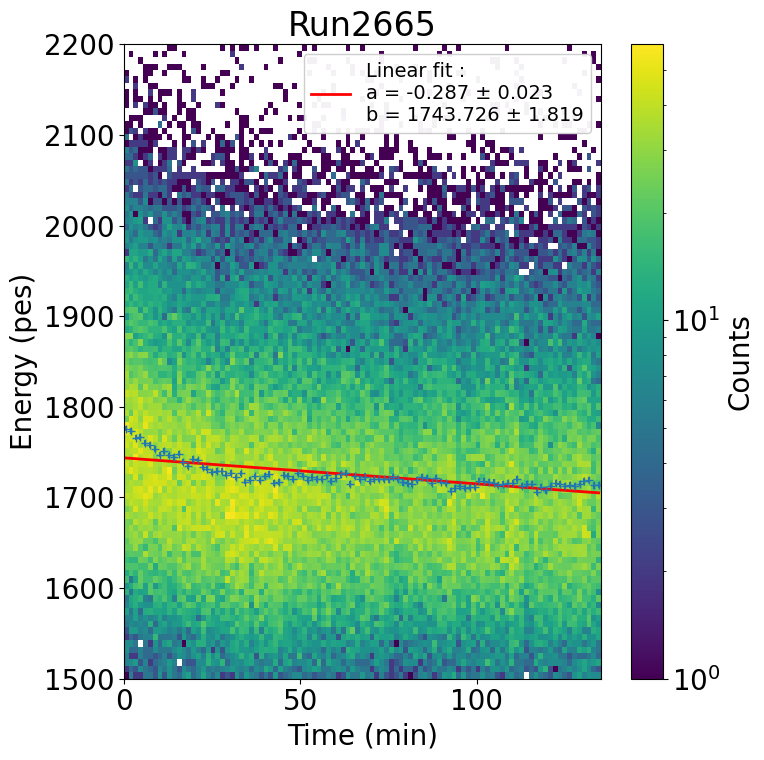

real dates pd :  ['2025-11-11 09:24:00']
[1762853040.0]
time max is :  135.132916922
time sum is :  135.132916922


/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_19551/4029988076.py:125: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['real_timestamp'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min()) * 8e-9 + timestamp[i]
/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_19551/4029988076.py:127: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/Energy_vs_Time/Runs_together_2665_2665.png


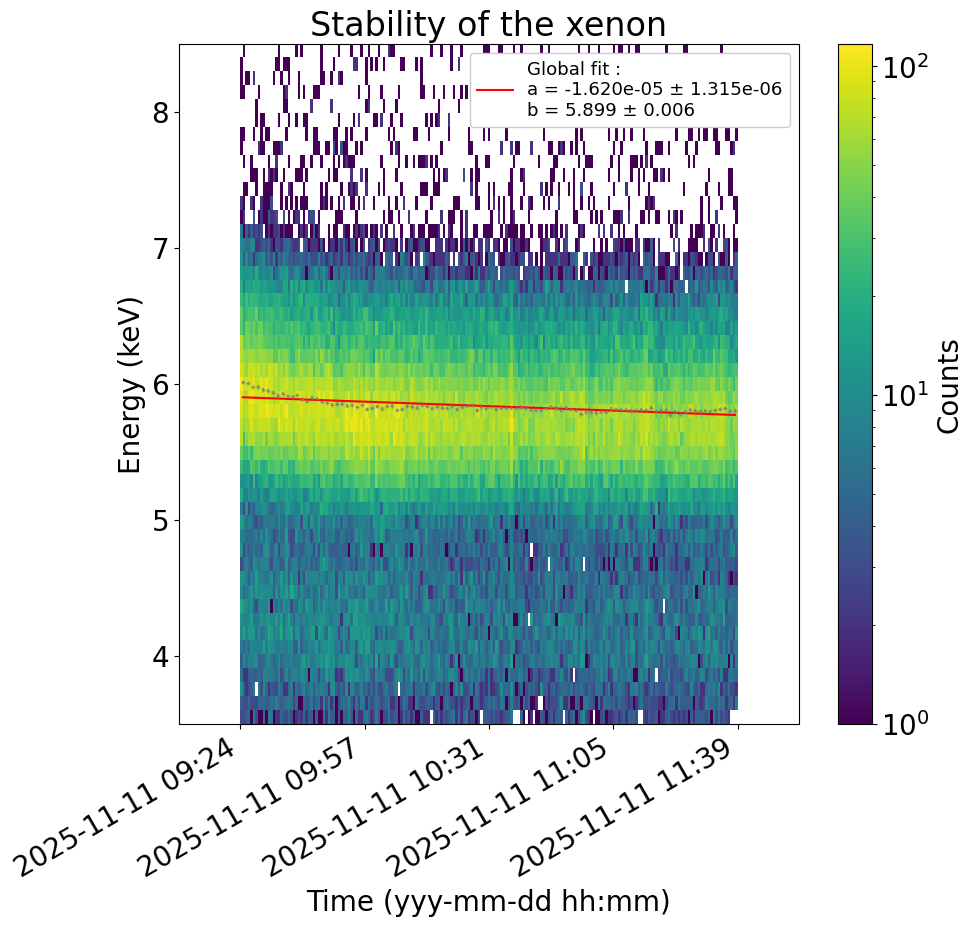

In [126]:
# ---------------------------------------------------------
# To have a look at the runs and fit them
# ---------------------------------------------------------
from matplotlib.colors import LogNorm
all_run = runs
coef_a_store = []
sigma_a_store = []
coef_b_store = []
sigma_b_store = []
energy_ref = []

# --- NEW: storage of everything needed to reproduce each run's fit later ---
fit_results = []   # one dict per run: run number, fit params, and the x-range used for the fit

for run in range(len(all_run)):

    run_nb = [all_run[run]]

    #ene_min = 1400
    #ene_max = 2200 #scale of the plot
    ene_min = 1500
    ene_max = 2200 #scale of the plot
    #ene_min = 2500
    #ene_max = 4000 #scale of the plot

    for i in range(len(run_nb)):
        dst_hot = '/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R'+str(run_nb[i])+'/octavia/DST_run_'+str(run_nb[i])+'_pmaps.h5'
        dst_hot      = pd.read_hdf(dst_hot, 'WVF')

        #dst_hot['energy'] = dst_hot['s1_energy']
        dst_rd_hot = dst_hot[['timestamp', 'energy']]
        dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60
        tbins     = np.linspace(dst_rd_hot['time'].min(), dst_rd_hot['time'].max(), 100)
        ebins     = np.linspace(dst_rd_hot['energy'].min(),dst_rd_hot['energy'].max(), 100)
        erange = [ene_min, ene_max]

        sel1 = np.full(len(dst_rd_hot), True)
        enebins   = np.linspace(ene_min, ene_max, 100)
        plt.figure(figsize=(8, 8))

        h = plt.hist2d(dst_rd_hot['time'], dst_rd_hot['energy'], [tbins, enebins], norm=LogNorm(), cmap='viridis')
        tprof = fitf.profileX(dst_rd_hot['time'], dst_rd_hot['energy'], xrange=[tbins[0], tbins[-1]], yrange=erange, nbins=100)
        plt.errorbar(tprof[0], tprof[1], yerr=tprof[2], linestyle='', marker='+')
        plt.colorbar(h[3], label='Counts')

        x = tprof[0]
        y = tprof[1]
        energy_ref.append(y[0])

        popt, pcov = np.polyfit(x, y, deg=1, cov=True)
        a, b = popt
        sigma_a, sigma_b = np.sqrt(np.diag(pcov))
        y_lin = a * x + b
        plt.plot(x, y_lin, '-', label=f'Linear fit :\na = {a:.3f} ± {sigma_a:.3f}\nb = {b:.3f} ± {sigma_b:.3f}', color='red', linewidth=2)

        coef_a_store.append(a)
        coef_b_store.append(b)
        sigma_a_store.append(sigma_a)
        sigma_b_store.append(sigma_b)

        # --- NEW: save everything needed to redraw this exact fit line later ---
        # x is "time" in minutes elapsed since the start of THIS run (local time axis).
        # We only need the min/max of x (a straight line is fully defined by 2 points).
        fit_results.append({
            "run": run_nb[i],
            "a": a,
            "b": b,
            "sigma_a": sigma_a,
            "sigma_b": sigma_b,
            "x_min_local": x.min(),   # local time (minutes) at start of the run's fit
            "x_max_local": x.max(),   # local time (minutes) at end of the run's fit
            # --- NEW: on garde aussi tous les points du profil (pas juste min/max) ---
            "x_all_local": np.array(x),
            "y_all": np.array(y),
            "yerr_all": np.array(tprof[2]),
        })

        plt.xlabel('Time (min)')
        plt.ylabel('Energy (pes)')
        plt.title('Run'+str(run_nb[i]))
        plt.xlim(np.min(dst_rd_hot['time']), np.max(dst_rd_hot['time']))
        plt.legend(fontsize=14, framealpha=0.95)
        plt.tight_layout()
        plt.savefig('/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/Energy_vs_Time/Single_Run_'+str(run_nb[i])+'.png', bbox_inches='tight')
        plt.show()

mean_pes = np.mean(coef_b_store)

# ---------------------------------------------------------
# real dates are converted in timestamps
# ---------------------------------------------------------
from datetime import datetime
real_dates = df_used_input['Dates'].tolist()
print("real dates pd : ", real_dates)
getters = df_used_input['Getters'].tolist()
shift_time = df_used_input['Shift_time'].tolist() #change in case data are taken with 1h or 2h shift
timestamp = []
for i in range(len(real_dates)):
    dt = datetime.strptime(str(real_dates[i]), "%Y-%m-%d %H:%M:%S")
    timestamp.append(dt.timestamp() + shift_time[i]*3600)
    print(timestamp)

# ---------------------------------------------------------
# To convert the acquired timestamps into real timestamps and to concat different runs in the same dataset
# ---------------------------------------------------------
from matplotlib.colors import LogNorm
run_nb = all_run
mid_time_store = []
err_period = []
dfs = []
nb_event = []
line_coord = [0]
line_sum = 0
index = []
time_tot = 0
for i in range(len(run_nb)):
    dst_hot = '/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R'+str(run_nb[i])+'/octavia/DST_run_'+str(run_nb[i])+'_pmaps.h5'
    dst_hot      = pd.read_hdf(dst_hot, 'WVF')

    dst_rd_hot = dst_hot[['timestamp', 'energy']] #we only take the intersting columns of the general dst

    nb_event.append(len(dst_rd_hot))

    #Here we convert the timestamps acquired in real timestamps
    dst_rd_hot['real_timestamp'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min()) * 8e-9 + timestamp[i]
    #Conversion from real timestamps to minutes
    dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60

    print('time max is : ', dst_rd_hot.time.max())
    time_tot += dst_rd_hot.time.max()
    print('time sum is : ', time_tot)
    mid_time_store.append(dst_rd_hot['real_timestamp'].min() + (dst_rd_hot['real_timestamp'].max() - dst_rd_hot['real_timestamp'].min())/2)
    err_period.append((dst_rd_hot['real_timestamp'].max() - dst_rd_hot['real_timestamp'].min())/2)

    #we put all the dst for all the runs in the same variable
    dfs.append(dst_rd_hot)

    index.append(dst_rd_hot['real_timestamp'].min())
    index.append(dst_rd_hot['real_timestamp'].max())

# we concat all the dst in dst_conc, we will use it to plot all the periods on the same plot
dst_conc = pd.concat(dfs, ignore_index=True)

# ---------------------------------------------------------
# To plot Energy vs Time with real dates
# ---------------------------------------------------------
import matplotlib.dates as mdates
import os
os.environ["TZ"] = "Europe/Paris"
import time
time.tzset()
import datetime
if (keV_plot == 'no'):
    ene_min = 3.5
    ene_max = 8.5
if (keV_plot == 'yes'):
    ene_min = 0
    ene_max = 15
x_line = []
enebins   = np.linspace(ene_min, ene_max, 50)
#To convert real timestamps into real dates
dst_conc['date'] = pd.to_datetime(dst_conc['real_timestamp'], unit='s')
dst_conc['date'] = pd.to_datetime(dst_conc['real_timestamp'], unit="s") + pd.Timedelta(minutes=30)
dst_conc["date"] = mdates.date2num(dst_conc["date"])
tmin = dst_conc['real_timestamp'].min()
tmax = dst_conc['real_timestamp'].max()
#To generate the 2D histo of Energy vs Time
dst_conc['energy'] = dst_conc['energy'] * 5.9/mean_pes
tbins     = np.linspace(tmin, tmax, 200)
ebins     = np.linspace(dst_conc['energy'].min(),dst_conc['energy'].max(), 200)
plt.figure(figsize=(10, 10))
if (keV_plot == 'no'):
    h = plt.hist2d(dst_conc['real_timestamp'], dst_conc['energy'], [tbins, enebins], norm=LogNorm(), cmap='viridis')
plt.colorbar(h[3], label='Counts')
ax = plt.gca()
def format_timestamp(x, pos=None): #function to plot the x axis in the good format
    return datetime.datetime.utcfromtimestamp(x).strftime('%Y-%m-%d %H:%M')
ax.xaxis.set_major_formatter(plt.FuncFormatter(format_timestamp))
xmin, xmax = dst_conc['real_timestamp'].min(),dst_conc['real_timestamp'].max()
num_ticks = 5  # Number of thick on x axis
new_ticks = np.linspace(xmin, xmax, num_ticks)
ax.set_xticks(new_ticks)
plt.gcf().autofmt_xdate()
ymin, ymax = plt.ylim()
time_max = len(line_coord)
color = ['red']
#for i in range(len(timestamp)):
 #   if (getters[i] == 'C'):
        #plt.axvline(timestamp[i], color = 'blue')
  #  if (getters[i] == 'H'):
        #plt.axvline(timestamp[i], color = 'red')
   # if (getters[i] == 'H/C'):
        #plt.axvline(timestamp[i], color = 'darkorange')

# --- NEW: reproduce each run's linear fit on this combined plot, with its equation in the legend ---
# fit_results was built during the first loop, using local (per-run) time in minutes.
# Here we convert each fit's x-range from "local minutes" to "real timestamp" (this plot's x axis),
# and convert the y-values from pes to keV using the same mean_pes factor used for dst_conc['energy'].
fit_colors = plt.cm.tab10.colors

# --- NEW: pour stocker l'ensemble des points (toutes runs confondues) pour le fit global ---
x_real_all_points = []
y_kev_all_points   = []

for k, fr in enumerate(fit_results):
    # find the timestamp offset for this run (same order as run_nb/timestamp lists)
    try:
        run_index = list(run_nb).index(fr["run"])
    except ValueError:
        continue  # run not found in run_nb/timestamp (shouldn't normally happen)

    t_offset = timestamp[run_index]

    x_local = np.array([fr["x_min_local"], fr["x_max_local"]])  # minutes elapsed within the run
    x_real  = x_local * 60 + t_offset                            # convert to real_timestamp (seconds)

    y_pes = fr["a"] * x_local + fr["b"]
    y_kev = y_pes * 5.9 / mean_pes
    
    fr["b_keV"] = fr["b"] * 5.9 / mean_pes
    fr["sigma_b_keV"] = fr["sigma_b"] * 5.9 / mean_pes
    line_color = fit_colors[k % len(fit_colors)+3]
    #plt.plot(
     #   x_real, y_kev, '-', linewidth=2, color=line_color,
      #  label=(f'Run {fr["run"]}: '
       #        f'a = {fr["a"]:.3f} ± {fr["sigma_a"]:.3f}, '
        #       f'b = {fr["b_keV"]:.3f} ± {fr["sigma_b_keV"]:.3f}')
    #)

    # --- NEW: on convertit et on affiche les points du profil (comme sur les premiers plots) ---
    x_pts_real = fr["x_all_local"] * 60 + t_offset
    y_pts_kev  = fr["y_all"] * 5.9 / mean_pes
    yerr_pts_kev = fr["yerr_all"] * 5.9 / mean_pes

    plt.errorbar(
        x_pts_real, y_pts_kev, yerr=yerr_pts_kev,
        linestyle='', marker='+',color='gray', alpha=0.7, markersize=3
    )

    # --- NEW: on accumule tous les points pour le fit global ---
    x_real_all_points.append(x_pts_real)
    y_kev_all_points.append(y_pts_kev)

# --- NEW: fit linéaire global sur l'ensemble des points de toutes les runs ---
x_real_all_points = np.concatenate(x_real_all_points)
y_kev_all_points  = np.concatenate(y_kev_all_points)

# Use the first timestamp as the time origin
t0 = x_real_all_points.min()
x_fit = x_real_all_points - t0

popt_global, pcov_global = np.polyfit(x_fit, y_kev_all_points, deg=1, cov=True)
a_global, b_global = popt_global


sigma_a_global, sigma_b_global = np.sqrt(np.diag(pcov_global))

x_global_line = np.array([x_real_all_points.min(), x_real_all_points.max()])
y_global_line = a_global * (x_global_line - t0) + b_global

plt.plot(
    x_global_line, y_global_line, '-', linewidth=1.5, color='red',
    label=(f'Global fit :\n'
           f'a = {a_global:.3e} ± {sigma_a_global:.3e}\n'
           f'b = {b_global:.3f} ± {sigma_b_global:.3f}')
)

plt.title('Stability of the xenon')
plt.legend(fontsize=13, framealpha=1, loc='upper right')

plt.xlim(dst_conc['real_timestamp'].min() - 1000, dst_conc['real_timestamp'].max() + 1000)
plt.xlabel('Time (yyy-mm-dd hh:mm)')
#plt.ylabel('Energy (keV)')
if (keV_plot == 'no'):
    plt.ylabel('Energy (keV)')
plt.savefig('/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/Energy_vs_Time/Runs_together_'+str(np.min(run_nb))+'_'+str(np.max(run_nb))+'.png', bbox_inches='tight')
print('/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/Energy_vs_Time/Runs_together_'+str(np.min(run_nb))+'_'+str(np.max(run_nb))+'.png')

/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_19551/1501414554.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


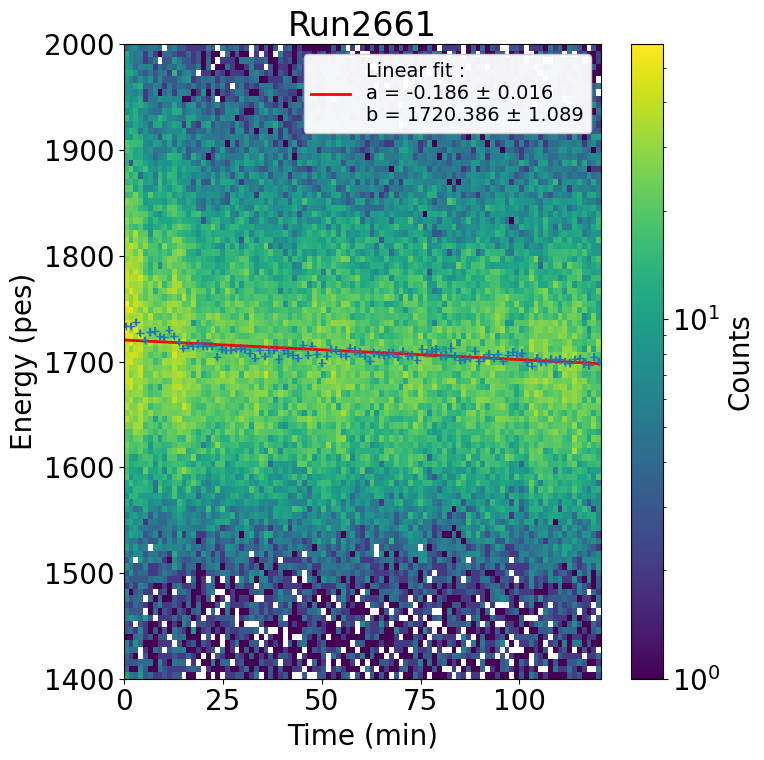

/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_19551/1501414554.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


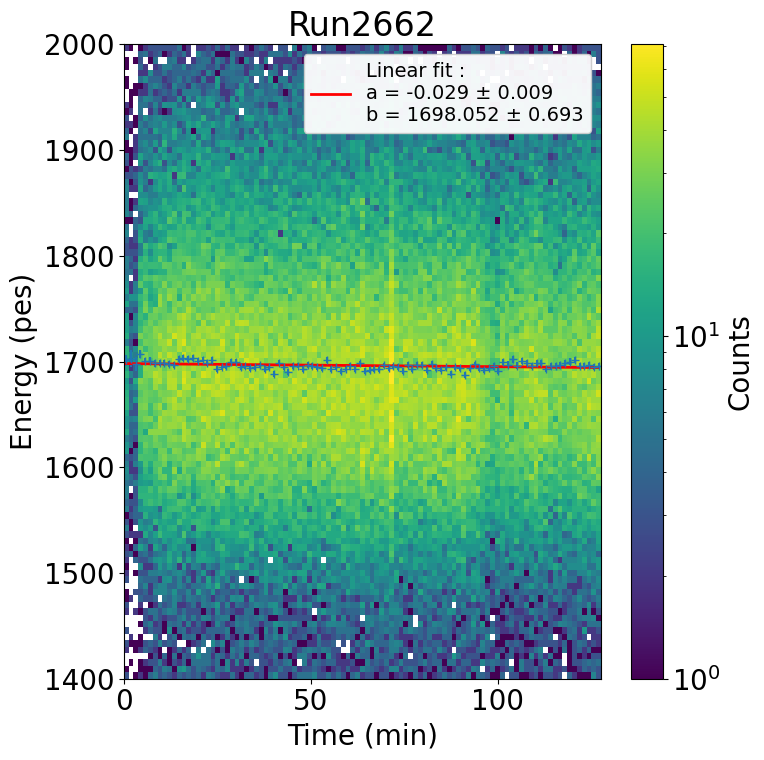

/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_19551/1501414554.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


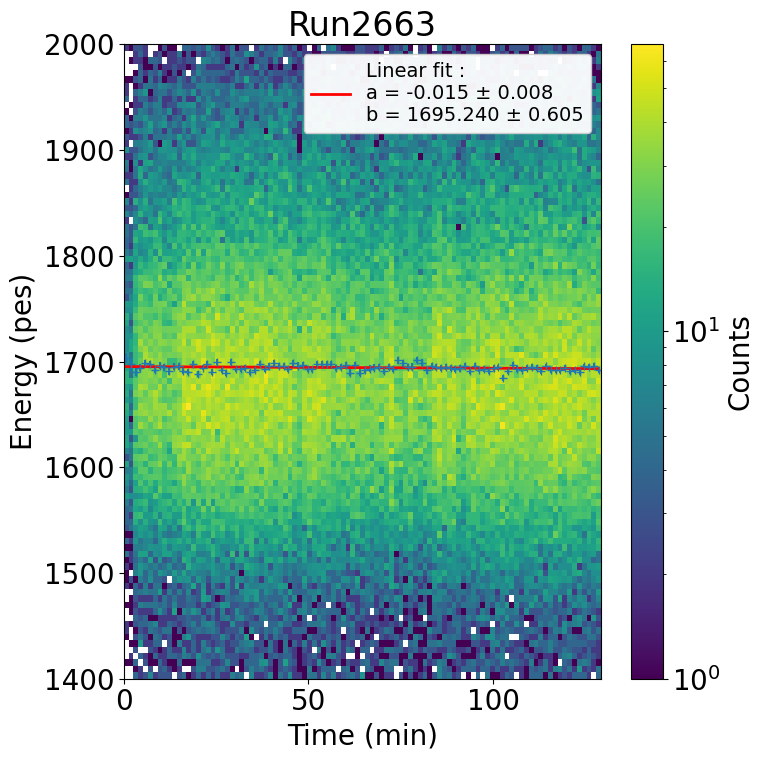

/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_19551/1501414554.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


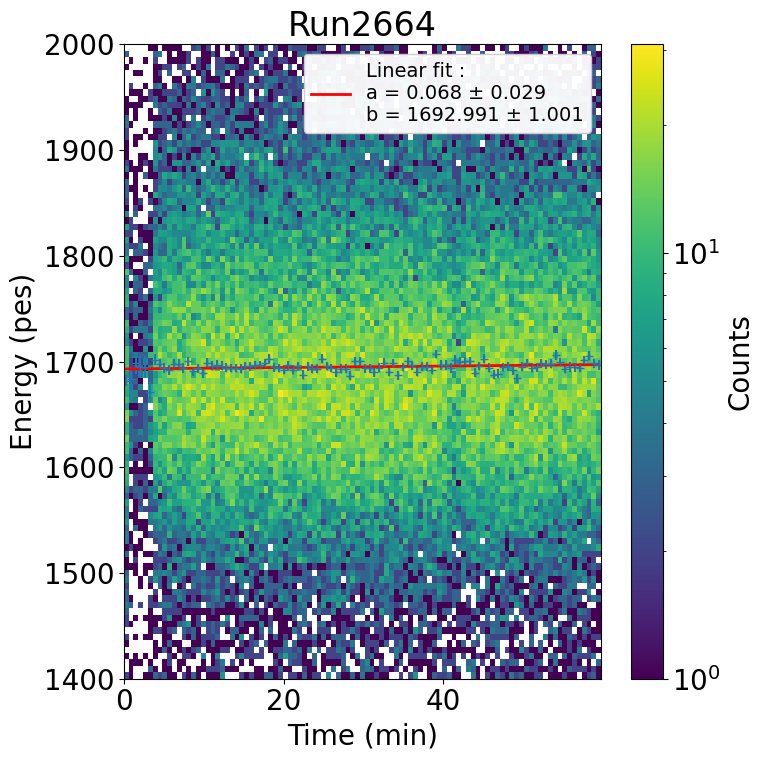

real dates pd :  ['2025-11-10 10:35:00', '2025-11-10 12:37:00', '2025-11-10 14:46:00', '2025-11-10 16:59:00']
[1762770900.0]
[1762770900.0, 1762778220.0]
[1762770900.0, 1762778220.0, 1762785960.0]
[1762770900.0, 1762778220.0, 1762785960.0, 1762793940.0]
time max is :  120.60022375666668
time sum is :  120.60022375666668


/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_19551/1501414554.py:121: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['real_timestamp'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min()) * 8e-9 + timestamp[i]
/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_19551/1501414554.py:123: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


time max is :  127.60684813680001
time sum is :  248.2070718934667
time max is :  129.20926253413333
time sum is :  377.4163344276
time max is :  59.74270404466667
time sum is :  437.1590384722667
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/Energy_vs_Time/Runs_together_2661_2664.png


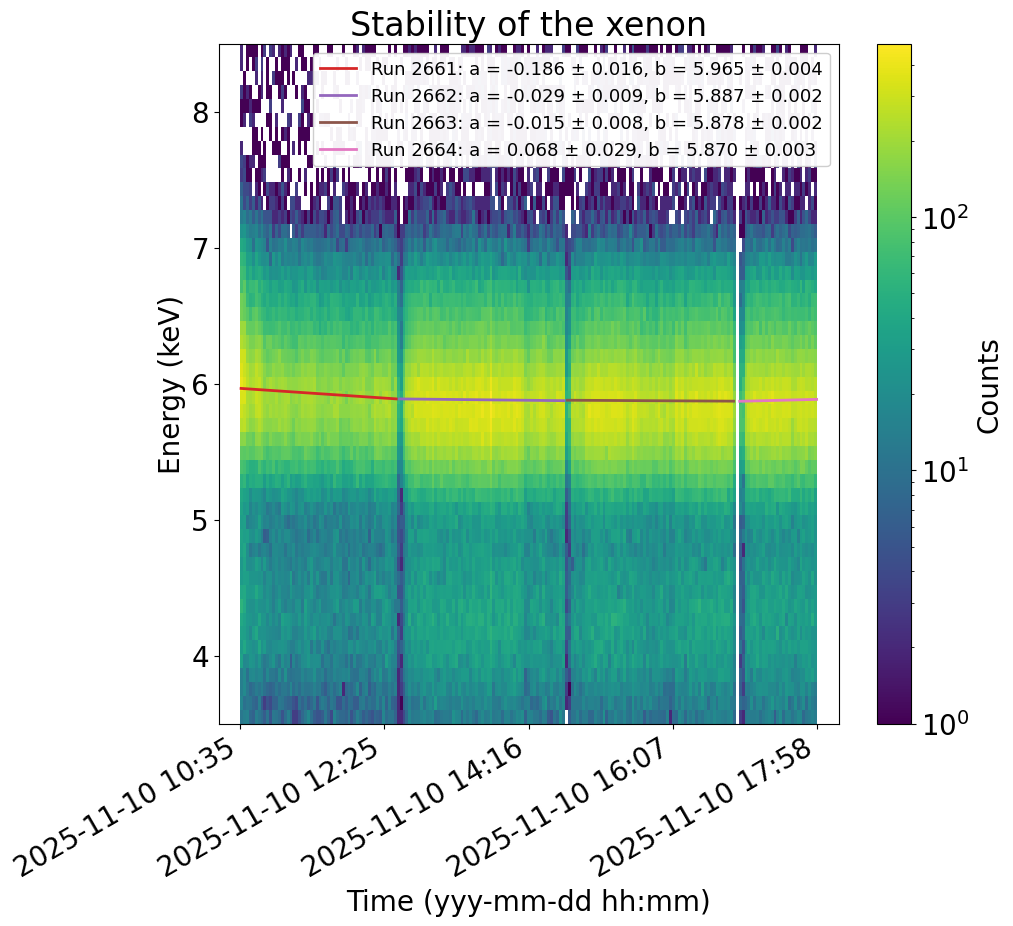

In [100]:
#here, we have a look to each run and we make a general plot with all the runs according to the real dates


# ---------------------------------------------------------
# To have a look at the runs and fit them
# ---------------------------------------------------------
from matplotlib.colors import LogNorm
all_run = runs
coef_a_store = []
sigma_a_store = []
coef_b_store = []
sigma_b_store = []
energy_ref = []

# --- NEW: storage of everything needed to reproduce each run's fit later ---
fit_results = []   # one dict per run: run number, fit params, and the x-range used for the fit

for run in range(len(all_run)):

    run_nb = [all_run[run]]

    #ene_min = 1400
    #ene_max = 2200 #scale of the plot
    #ene_min = 1000
    #ene_max = 1500 #scale of the plot
    ene_min = 1400
    ene_max = 2000 #scale of the plot

    for i in range(len(run_nb)):
        dst_hot = '/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R'+str(run_nb[i])+'/octavia/DST_run_'+str(run_nb[i])+'_pmaps.h5'
        dst_hot      = pd.read_hdf(dst_hot, 'WVF')

        #dst_hot['energy'] = dst_hot['s1_energy']
        dst_rd_hot = dst_hot[['timestamp', 'energy']]
        dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60
        tbins     = np.linspace(dst_rd_hot['time'].min(), dst_rd_hot['time'].max(), 100)
        ebins     = np.linspace(dst_rd_hot['energy'].min(),dst_rd_hot['energy'].max(), 100)
        erange = [ene_min, ene_max]

        sel1 = np.full(len(dst_rd_hot), True)
        enebins   = np.linspace(ene_min, ene_max, 100)
        plt.figure(figsize=(8, 8))

        h = plt.hist2d(dst_rd_hot['time'], dst_rd_hot['energy'], [tbins, enebins], norm=LogNorm(), cmap='viridis')
        tprof = fitf.profileX(dst_rd_hot['time'], dst_rd_hot['energy'], xrange=[tbins[0], tbins[-1]], yrange=erange, nbins=100)
        plt.errorbar(tprof[0], tprof[1], yerr=tprof[2], linestyle='', marker='+')
        plt.colorbar(h[3], label='Counts')

        x = tprof[0]
        y = tprof[1]
        energy_ref.append(y[0])

        popt, pcov = np.polyfit(x, y, deg=1, cov=True)
        a, b = popt
        sigma_a, sigma_b = np.sqrt(np.diag(pcov))
        y_lin = a * x + b
        plt.plot(x, y_lin, '-', label=f'Linear fit :\na = {a:.3f} ± {sigma_a:.3f}\nb = {b:.3f} ± {sigma_b:.3f}', color='red', linewidth=2)

        coef_a_store.append(a)
        coef_b_store.append(b)
        sigma_a_store.append(sigma_a)
        sigma_b_store.append(sigma_b)

        # --- NEW: save everything needed to redraw this exact fit line later ---
        # x is "time" in minutes elapsed since the start of THIS run (local time axis).
        # We only need the min/max of x (a straight line is fully defined by 2 points).
        fit_results.append({
            "run": run_nb[i],
            "a": a,
            "b": b,
            "sigma_a": sigma_a,
            "sigma_b": sigma_b,
            "x_min_local": x.min(),   # local time (minutes) at start of the run's fit
            "x_max_local": x.max(),   # local time (minutes) at end of the run's fit
        })

        plt.xlabel('Time (min)')
        plt.ylabel('Energy (pes)')
        plt.title('Run'+str(run_nb[i]))
        plt.xlim(np.min(dst_rd_hot['time']), np.max(dst_rd_hot['time']))
        plt.legend(fontsize=14, framealpha=0.95)
        plt.tight_layout()
        plt.savefig('/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/Energy_vs_Time/Single_Run_'+str(run_nb[i])+'.png', bbox_inches='tight')
        plt.show()

mean_pes = np.mean(coef_b_store)

# ---------------------------------------------------------
# real dates are converted in timestamps
# ---------------------------------------------------------
from datetime import datetime
real_dates = df_used_input['Dates'].tolist()
print("real dates pd : ", real_dates)
getters = df_used_input['Getters'].tolist()
shift_time = df_used_input['Shift_time'].tolist() #change in case data are taken with 1h or 2h shift
timestamp = []
for i in range(len(real_dates)):
    dt = datetime.strptime(str(real_dates[i]), "%Y-%m-%d %H:%M:%S")
    timestamp.append(dt.timestamp() + shift_time[i]*3600)
    print(timestamp)

# ---------------------------------------------------------
# To convert the acquired timestamps into real timestamps and to concat different runs in the same dataset
# ---------------------------------------------------------
from matplotlib.colors import LogNorm
run_nb = all_run
mid_time_store = []
err_period = []
dfs = []
nb_event = []
line_coord = [0]
line_sum = 0
index = []
time_tot = 0
for i in range(len(run_nb)):
    dst_hot = '/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R'+str(run_nb[i])+'/octavia/DST_run_'+str(run_nb[i])+'_pmaps.h5'
    dst_hot      = pd.read_hdf(dst_hot, 'WVF')

    dst_rd_hot = dst_hot[['timestamp', 'energy']] #we only take the intersting columns of the general dst

    nb_event.append(len(dst_rd_hot))

    #Here we convert the timestamps acquired in real timestamps
    dst_rd_hot['real_timestamp'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min()) * 8e-9 + timestamp[i]
    #Conversion from real timestamps to minutes
    dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60

    print('time max is : ', dst_rd_hot.time.max())
    time_tot += dst_rd_hot.time.max()
    print('time sum is : ', time_tot)
    mid_time_store.append(dst_rd_hot['real_timestamp'].min() + (dst_rd_hot['real_timestamp'].max() - dst_rd_hot['real_timestamp'].min())/2)
    err_period.append((dst_rd_hot['real_timestamp'].max() - dst_rd_hot['real_timestamp'].min())/2)

    #we put all the dst for all the runs in the same variable
    dfs.append(dst_rd_hot)

    index.append(dst_rd_hot['real_timestamp'].min())
    index.append(dst_rd_hot['real_timestamp'].max())

# we concat all the dst in dst_conc, we will use it to plot all the periods on the same plot
dst_conc = pd.concat(dfs, ignore_index=True)

# ---------------------------------------------------------
# To plot Energy vs Time with real dates
# ---------------------------------------------------------
import matplotlib.dates as mdates
import os
os.environ["TZ"] = "Europe/Paris"
import time
time.tzset()
import datetime
if (keV_plot == 'no'):
    ene_min = 3.5
    ene_max = 8.5
if (keV_plot == 'yes'):
    ene_min = 0
    ene_max = 15
x_line = []
enebins   = np.linspace(ene_min, ene_max, 50)
#To convert real timestamps into real dates
dst_conc['date'] = pd.to_datetime(dst_conc['real_timestamp'], unit='s')
dst_conc['date'] = pd.to_datetime(dst_conc['real_timestamp'], unit="s") + pd.Timedelta(minutes=30)
dst_conc["date"] = mdates.date2num(dst_conc["date"])
tmin = dst_conc['real_timestamp'].min()
tmax = dst_conc['real_timestamp'].max()
#To generate the 2D histo of Energy vs Time
dst_conc['energy'] = dst_conc['energy'] * 5.9/mean_pes
tbins     = np.linspace(tmin, tmax, 200)
ebins     = np.linspace(dst_conc['energy'].min(),dst_conc['energy'].max(), 200)
plt.figure(figsize=(10, 10))
if (keV_plot == 'no'):
    h = plt.hist2d(dst_conc['real_timestamp'], dst_conc['energy'], [tbins, enebins], norm=LogNorm(), cmap='viridis')
plt.colorbar(h[3], label='Counts')
ax = plt.gca()
def format_timestamp(x, pos=None): #function to plot the x axis in the good format
    return datetime.datetime.utcfromtimestamp(x).strftime('%Y-%m-%d %H:%M')
ax.xaxis.set_major_formatter(plt.FuncFormatter(format_timestamp))
xmin, xmax = dst_conc['real_timestamp'].min(),dst_conc['real_timestamp'].max()
num_ticks = 5  # Number of thick on x axis
new_ticks = np.linspace(xmin, xmax, num_ticks)
ax.set_xticks(new_ticks)
plt.gcf().autofmt_xdate()
ymin, ymax = plt.ylim()
time_max = len(line_coord)
color = ['red']
#for i in range(len(timestamp)):
 #   if (getters[i] == 'C'):
        #plt.axvline(timestamp[i], color = 'blue')
  #  if (getters[i] == 'H'):
        #plt.axvline(timestamp[i], color = 'red')
   # if (getters[i] == 'H/C'):
        #plt.axvline(timestamp[i], color = 'darkorange')

# --- NEW: reproduce each run's linear fit on this combined plot, with its equation in the legend ---
# fit_results was built during the first loop, using local (per-run) time in minutes.
# Here we convert each fit's x-range from "local minutes" to "real timestamp" (this plot's x axis),
# and convert the y-values from pes to keV using the same mean_pes factor used for dst_conc['energy'].
fit_colors = plt.cm.tab10.colors
for k, fr in enumerate(fit_results):
    # find the timestamp offset for this run (same order as run_nb/timestamp lists)
    try:
        run_index = list(run_nb).index(fr["run"])
    except ValueError:
        continue  # run not found in run_nb/timestamp (shouldn't normally happen)

    t_offset = timestamp[run_index]

    x_local = np.array([fr["x_min_local"], fr["x_max_local"]])  # minutes elapsed within the run
    x_real  = x_local * 60 + t_offset                            # convert to real_timestamp (seconds)

    y_pes = fr["a"] * x_local + fr["b"]
    y_kev = y_pes * 5.9 / mean_pes
    
    fr["b_keV"] = fr["b"] * 5.9 / mean_pes
    fr["sigma_b_keV"] = fr["sigma_b"] * 5.9 / mean_pes
    line_color = fit_colors[k % len(fit_colors)+3]
    plt.plot(
        x_real, y_kev, '-', linewidth=2, color=line_color,
        label=(f'Run {fr["run"]}: '
               f'a = {fr["a"]:.3f} ± {fr["sigma_a"]:.3f}, '
               f'b = {fr["b_keV"]:.3f} ± {fr["sigma_b_keV"]:.3f}')
    )
plt.title('Stability of the xenon')
plt.legend(fontsize=13, framealpha=0.95, loc='best')

plt.xlim(dst_conc['real_timestamp'].min() - 1000, dst_conc['real_timestamp'].max() + 1000)
plt.xlabel('Time (yyy-mm-dd hh:mm)')
#plt.ylabel('Energy (keV)')
if (keV_plot == 'no'):
    plt.ylabel('Energy (keV)')
plt.savefig('/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/Energy_vs_Time/Runs_together_'+str(np.min(run_nb))+'_'+str(np.max(run_nb))+'.png', bbox_inches='tight')
print('/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/Energy_vs_Time/Runs_together_'+str(np.min(run_nb))+'_'+str(np.max(run_nb))+'.png')

/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_19551/592302926.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


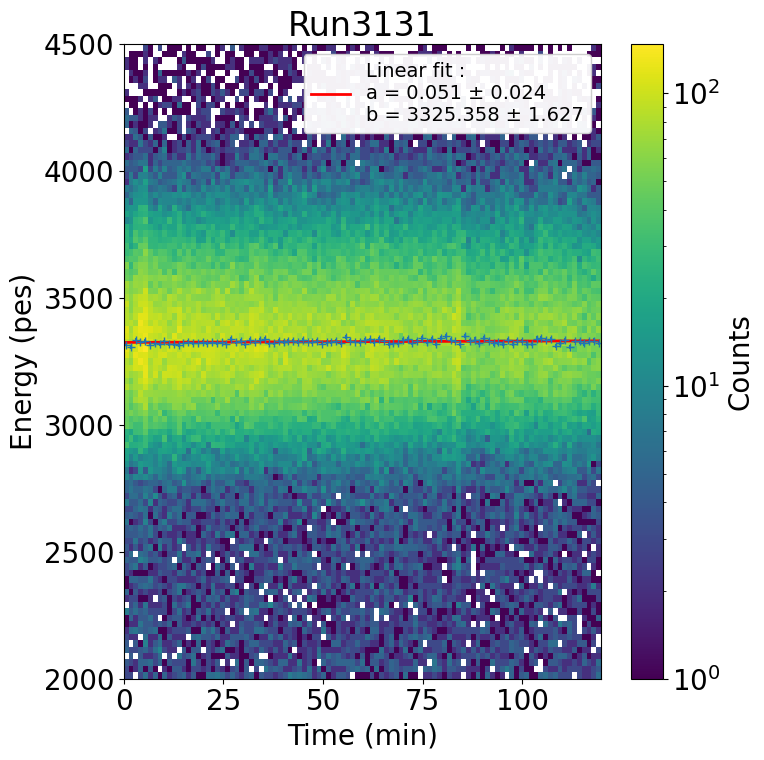

/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_19551/592302926.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


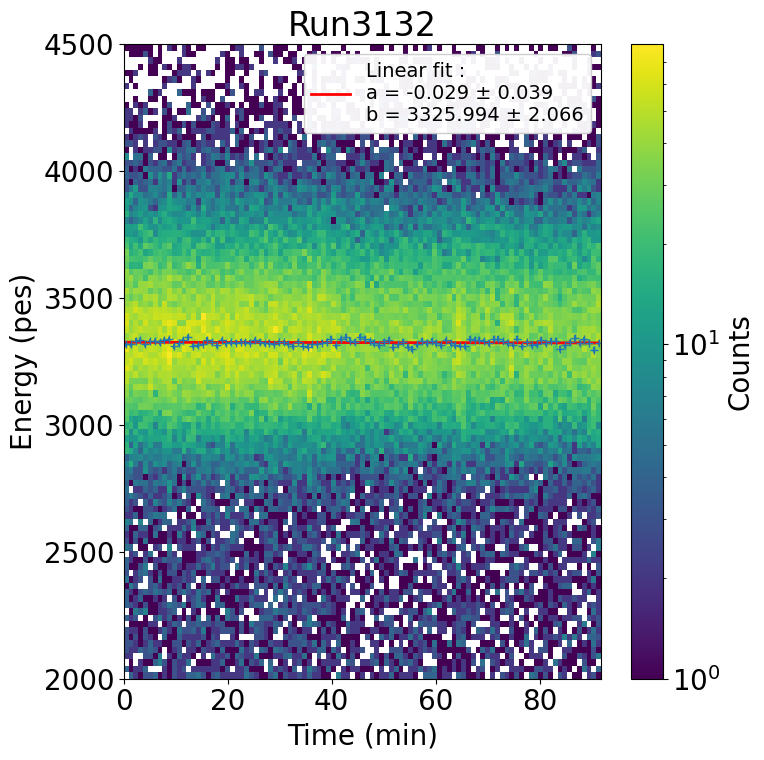

/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_19551/592302926.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


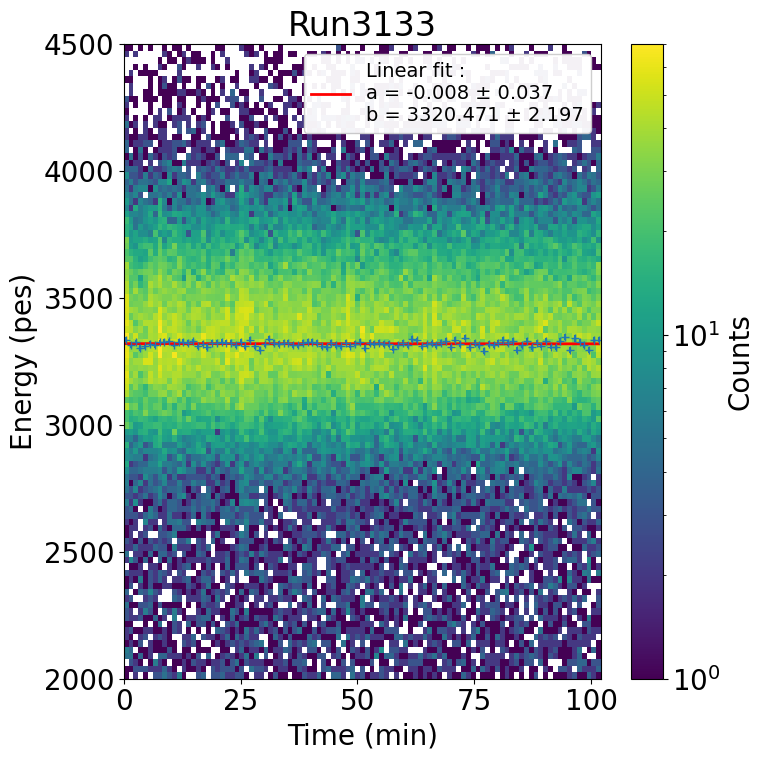

/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_19551/592302926.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


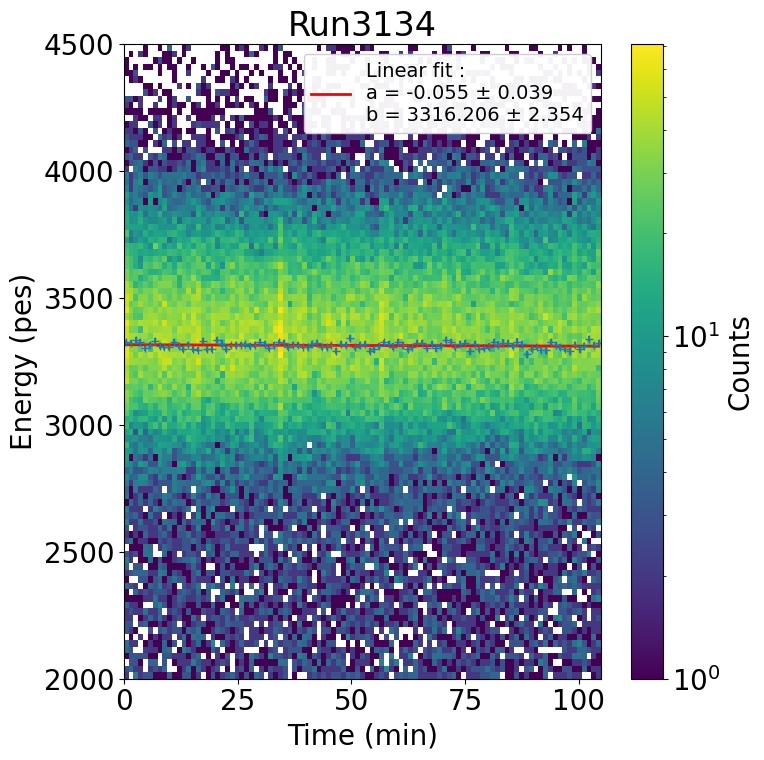

In [92]:
#To have a look to the runs and fit them 
from matplotlib.colors import LogNorm

all_run = runs
coef_a_store = []
sigma_a_store = []
coef_b_store = []
sigma_b_store = []
energy_ref = []

for run in range(len(all_run)):
    
    run_nb = [all_run[run]]
    
    #ene_min = 1400
    #ene_max = 2200 #scale of the plot
    #ene_min = 1000
    #ene_max = 1500 #scale of the plot
    ene_min = 2000
    ene_max = 4500 #scale of the plot
    
    for i in range(len(run_nb)):
        dst_hot = '/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R'+str(run_nb[i])+'/octavia/DST_run_'+str(run_nb[i])+'_pmaps.h5'
        dst_hot      = pd.read_hdf(dst_hot, 'WVF')
        
        #dst_hot['energy'] = dst_hot['s1_energy']

        dst_rd_hot = dst_hot[['timestamp', 'energy']]

        dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60

        tbins     = np.linspace(dst_rd_hot['time'].min(), dst_rd_hot['time'].max(), 100)
        ebins     = np.linspace(dst_rd_hot['energy'].min(),dst_rd_hot['energy'].max(), 100)
        erange = [ene_min, ene_max]
        
        sel1 = np.full(len(dst_rd_hot), True)

        enebins   = np.linspace(ene_min, ene_max, 100)

        plt.figure(figsize=(8, 8))
        
        h = plt.hist2d(dst_rd_hot['time'], dst_rd_hot['energy'], [tbins, enebins], norm=LogNorm(), cmap='viridis')
        tprof = fitf.profileX(dst_rd_hot['time'], dst_rd_hot['energy'], xrange=[tbins[0], tbins[-1]], yrange=erange, nbins=100)
        plt.errorbar(tprof[0], tprof[1], yerr=tprof[2], linestyle='', marker='+')
        plt.colorbar(h[3], label='Counts')
        
        x = tprof[0]
        y = tprof[1]
        energy_ref.append(y[0])
        
        popt, pcov = np.polyfit(x, y, deg=1, cov=True)
        a, b = popt
        sigma_a, sigma_b = np.sqrt(np.diag(pcov))
        y_lin = a * x + b
        plt.plot(x, y_lin, '-', label=f'Linear fit :\na = {a:.3f} ± {sigma_a:.3f}\nb = {b:.3f} ± {sigma_b:.3f}', color='red', linewidth=2)
        
        coef_a_store.append(a)
        coef_b_store.append(b)
        sigma_a_store.append(sigma_a)
        sigma_b_store.append(sigma_b)
        plt.xlabel('Time (min)')
        plt.ylabel('Energy (pes)')
        plt.title('Run'+str(run_nb[i]))
        plt.xlim(np.min(dst_rd_hot['time']), np.max(dst_rd_hot['time']))
        plt.legend(fontsize=14, framealpha=0.95)
        plt.tight_layout()
        plt.savefig('/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/Energy_vs_Time/Single_Run_'+str(run_nb[i])+'.png', bbox_inches='tight')

        plt.show()
        
mean_pes = np.mean(coef_b_store)       

In [58]:
#real dates are converted in timestamps
from datetime import datetime
real_dates = df_used_input['Dates'].tolist()

print("real dates pd : ", real_dates)

getters = df_used_input['Getters'].tolist()
shift_time = df_used_input['Shift_time'].tolist() #change in case data are taken with 1h or 2h shift


timestamp = []
for i in range(len(real_dates)):
    dt = datetime.strptime(str(real_dates[i]), "%Y-%m-%d %H:%M:%S")
    timestamp.append(dt.timestamp() + shift_time[i]*3600)

    print(timestamp)

real dates pd :  ['2026-03-09 10:48:00', '2026-03-09 12:53:00', '2026-03-09 14:29:00', '2026-03-09 16:16:00']
[1773056880.0]
[1773056880.0, 1773064380.0]
[1773056880.0, 1773064380.0, 1773070140.0]
[1773056880.0, 1773064380.0, 1773070140.0, 1773076560.0]


In [59]:
#To convert the acquired timestamps into real timestamps and to concat different runs in the same dataset
from matplotlib.colors import LogNorm

run_nb = all_run
mid_time_store = []
err_period = []

dfs = []
nb_event = []
line_coord = [0]
line_sum = 0
index = []
time_tot = 0
for i in range(len(run_nb)):
    dst_hot = '/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R'+str(run_nb[i])+'/octavia/DST_run_'+str(run_nb[i])+'_pmaps.h5'
    dst_hot      = pd.read_hdf(dst_hot, 'WVF')
    
    dst_rd_hot = dst_hot[['timestamp', 'energy']] #we only take the intersting columns of the general dst
    
    nb_event.append(len(dst_rd_hot))
    
    #Here we convert the timestamps acquired in real timestamps
    dst_rd_hot['real_timestamp'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min()) * 8e-9 + timestamp[i]
    #Conversion from real timestamps to minutes
    dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60
    
    print('time max is : ', dst_rd_hot.time.max())
    time_tot += dst_rd_hot.time.max()
    print('time sum is : ', time_tot)
    mid_time_store.append(dst_rd_hot['real_timestamp'].min() + (dst_rd_hot['real_timestamp'].max() - dst_rd_hot['real_timestamp'].min())/2)
    err_period.append((dst_rd_hot['real_timestamp'].max() - dst_rd_hot['real_timestamp'].min())/2)
    
    #we put all the dst for all the runs in the same variable
    dfs.append(dst_rd_hot)
    
    index.append(dst_rd_hot['real_timestamp'].min())
    index.append(dst_rd_hot['real_timestamp'].max())
    
# we concat all the dst in dst_conc, we will use it to plot all the periods on the same plot
dst_conc = pd.concat(dfs, ignore_index=True)







/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_19551/1182646675.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['real_timestamp'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min()) * 8e-9 + timestamp[i]
/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_19551/1182646675.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


time max is :  119.70099829453333
time sum is :  119.70099829453333
time max is :  91.7867113388
time sum is :  211.48770963333334
time max is :  102.13643370946667
time sum is :  313.62414334280004
time max is :  104.8520795272
time sum is :  418.47622287


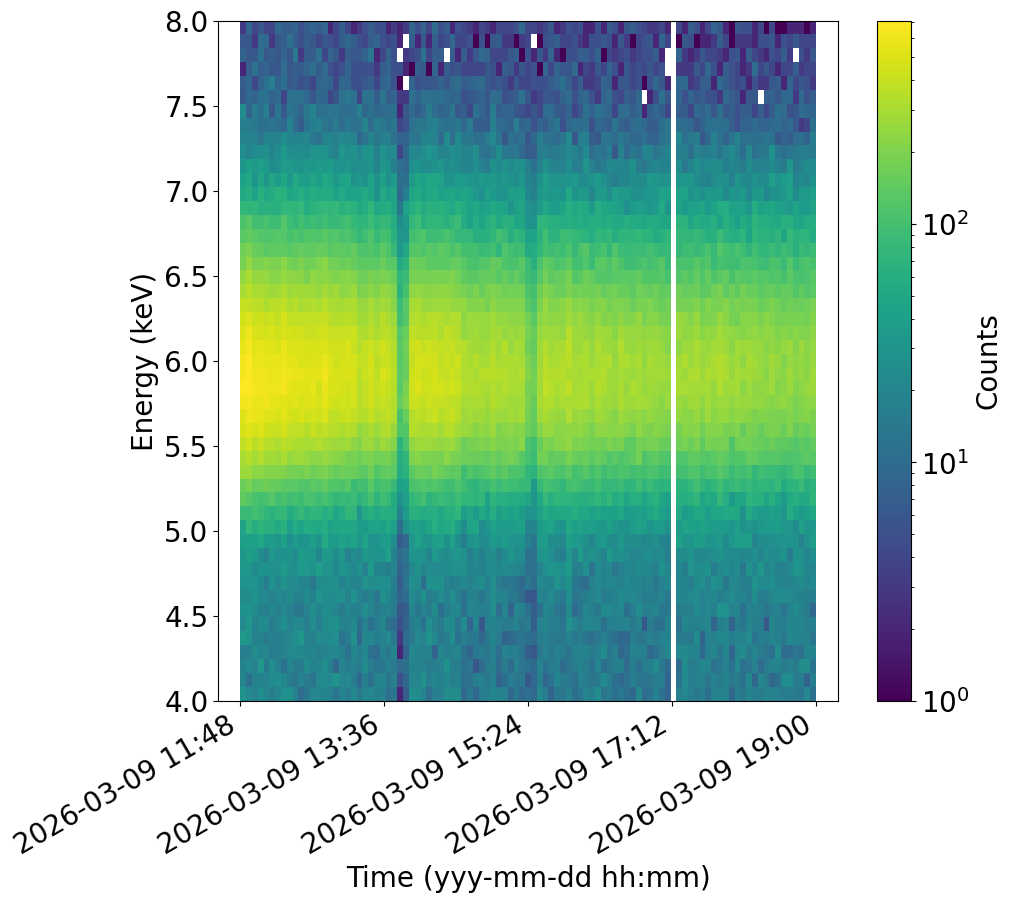

In [62]:
#To plot Energy vs Time with real dates
import matplotlib.dates as mdates
import os
os.environ["TZ"] = "Europe/Paris"
import time
time.tzset()
import datetime

if (keV_plot == 'no'):
    ene_min = 4
    ene_max = 8

if (keV_plot == 'yes'):
    ene_min = 0
    ene_max = 15

x_line = []
enebins   = np.linspace(ene_min, ene_max, 50)

#To convert real timestamps into real dates

dst_conc['date'] = pd.to_datetime(dst_conc['real_timestamp'], unit='s')
dst_conc['date'] = pd.to_datetime(dst_conc['real_timestamp'], unit="s") + pd.Timedelta(minutes=30)
dst_conc["date"] = mdates.date2num(dst_conc["date"])

tmin = dst_conc['real_timestamp'].min()
tmax = dst_conc['real_timestamp'].max()

#To generate the 2D histo of Energy vs Time

dst_conc['energy'] = dst_conc['energy'] * 5.9/mean_pes

tbins     = np.linspace(tmin, tmax, 100)
ebins     = np.linspace(dst_conc['energy'].min(),dst_conc['energy'].max(), 100)

plt.figure(figsize=(10, 10))

if (keV_plot == 'no'):
    h = plt.hist2d(dst_conc['real_timestamp'], dst_conc['energy'], [tbins, enebins], norm=LogNorm(), cmap='viridis')

plt.colorbar(h[3], label='Counts')

ax = plt.gca()


def format_timestamp(x, pos=None): #function to plot the x axis in the good format
    return datetime.datetime.utcfromtimestamp(x).strftime('%Y-%m-%d %H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(format_timestamp))

xmin, xmax = dst_conc['real_timestamp'].min(),dst_conc['real_timestamp'].max()
num_ticks = 5  # Number of thick on x axis
new_ticks = np.linspace(xmin, xmax, num_ticks)
ax.set_xticks(new_ticks)

plt.gcf().autofmt_xdate()

ymin, ymax = plt.ylim()

time_max = len(line_coord)

color = ['red']

#for i in range(len(timestamp)):
 #   if (getters[i] == 'C'):
        #plt.axvline(timestamp[i], color = 'blue')
  #  if (getters[i] == 'H'):
        #plt.axvline(timestamp[i], color = 'red')
   # if (getters[i] == 'H/C'):
        #plt.axvline(timestamp[i], color = 'darkorange')
        

plt.xlim(dst_conc['real_timestamp'].min() - 1000, dst_conc['real_timestamp'].max() + 1000)
plt.xlabel('Time (yyy-mm-dd hh:mm)')
#plt.ylabel('Energy (keV)')
if (keV_plot == 'no'):
    plt.ylabel('Energy (keV)')

plt.savefig('/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/Energy_vs_Time/Runs_together_'+str(np.min(run_nb))+'_'+str(np.max(run_nb))+'.png', bbox_inches='tight')




/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_19551/2802517171.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60
/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_19551/2802517171.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['energy_corr'] = energy_corr


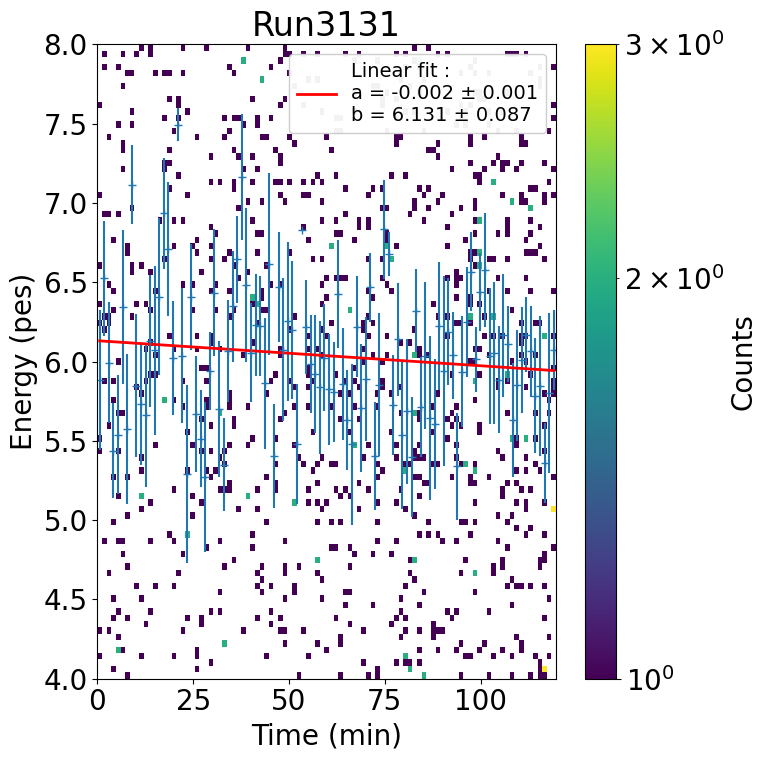

ValueError: the number of data points must exceed order to scale the covariance matrix

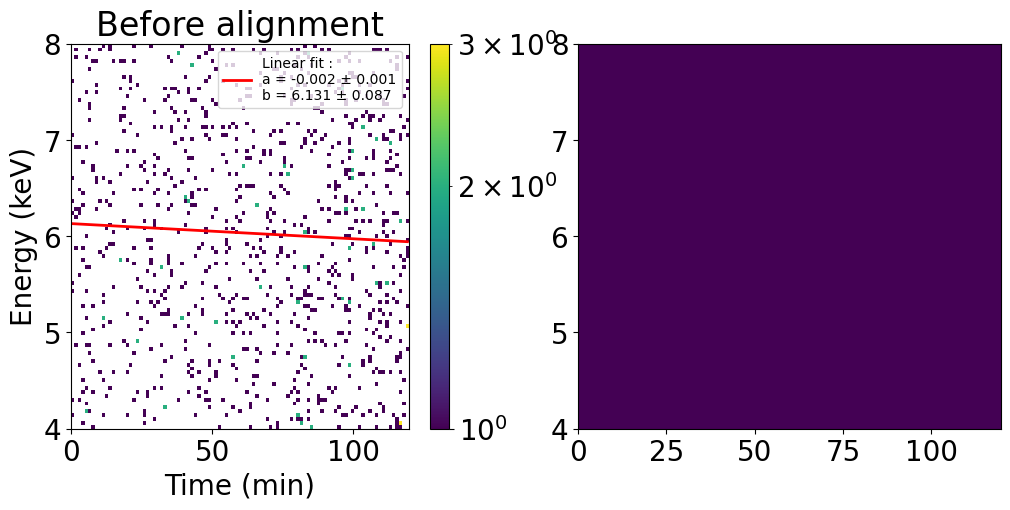

In [61]:
#To have a look to the runs and fit them 
from matplotlib.colors import LogNorm

all_run = runs
coef_a_store = []
sigma_a_store = []
coef_b_store = []
sigma_b_store = []
energy_plot = []
energy_plot_before_corr = []
source = 5.89
dst_store = []
for run in range(len(all_run)):
    
    run_nb = [all_run[run]]
    
    
    for i in range(len(run_nb)):
        dst_hot = '/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R'+str(run_nb[i])+'/octavia/DST_run_'+str(run_nb[i])+'_pmaps.h5'
        dst_hot      = pd.read_hdf(dst_hot, 'WVF')
        #dst_hot['energy'] = dst_hot['s1_energy']
        dst_rd_hot = dst_hot[['timestamp', 'energy', 'x', 'y']]

        dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60

        tbins     = np.linspace(dst_rd_hot['time'].min(), dst_rd_hot['time'].max(), 100)
        ebins     = np.linspace(dst_rd_hot['energy'].min(),dst_rd_hot['energy'].max(), 20)
        erange = [ene_min, ene_max]
        
        sel1 = np.full(len(dst_rd_hot), True)

        enebins   = np.linspace(ene_min, ene_max, 100)

        plt.figure(figsize=(8, 8))
        
        h = plt.hist2d(dst_rd_hot['time'], dst_rd_hot['energy'], [tbins, enebins], norm=LogNorm(), cmap='viridis')
        tprof = fitf.profileX(dst_rd_hot['time'], dst_rd_hot['energy'], xrange=[tbins[0], tbins[-1]], yrange=erange, nbins=100)
        plt.errorbar(tprof[0], tprof[1], yerr=tprof[2], linestyle='', marker='+')
        plt.colorbar(h[3], label='Counts')
        time_edges = np.linspace(tbins[0], tbins[-1], 100 + 1)
       
        x = tprof[0]
        y = tprof[1]

        popt, pcov = np.polyfit(x, y, deg=1, cov=True)
        a, b = popt
        sigma_a, sigma_b = np.sqrt(np.diag(pcov))
        y_lin = a * x + b
        plt.plot(x, y_lin, '-', label=f'Linear fit :\na = {a:.3f} ± {sigma_a:.3f}\nb = {b:.3f} ± {sigma_b:.3f}', color='red', linewidth=2)
        
        cs = interp1d(x,y)
        t_centers = x
        tmin = t_centers.min()
        tmax = t_centers.max()

        time_safe = np.clip(dst_rd_hot['time'], tmin, tmax)
        
        E_expected = cs(time_safe)
        
        energy_corr = dst_rd_hot['energy'] * (energy_ref[0] / E_expected)

        dst_rd_hot['energy_corr'] = energy_corr
        dst_store.append(dst_rd_hot)
        energy_plot_before_corr.extend(dst_rd_hot['energy'] * source / energy_ref[0])
        energy_plot.extend(energy_corr * source / energy_ref[0])
        
        coef_a_store.append(a)
        coef_b_store.append(b)
        sigma_a_store.append(sigma_a)
        sigma_b_store.append(sigma_b)
        plt.xlabel('Time (min)')
        plt.ylabel('Energy (pes)')
        plt.title('Run'+str(run_nb[i]))
        plt.xlim(np.min(dst_rd_hot['time']), np.max(dst_rd_hot['time']))
        plt.legend(fontsize=14, framealpha=0.95)
        plt.tight_layout()
        plt.savefig('/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/Energy_vs_Time/Single_Run_'+str(run_nb[i])+'.png', bbox_inches='tight')

        plt.show()
        
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1)
        plt.hist2d(time_safe, dst_rd_hot['energy'], [tbins, enebins], norm=LogNorm(), cmap='viridis')
        tprof = fitf.profileX(time_safe, dst_rd_hot['energy'], xrange=[tbins[0], tbins[-1]], yrange=erange, nbins=100)
        x = tprof[0]
        y = tprof[1]
        popt, pcov = np.polyfit(x, y, deg=1, cov=True)
        a, b = popt
        sigma_a, sigma_b = np.sqrt(np.diag(pcov))
        y_lin = a * x + b
        plt.plot(x, y_lin, '-', label=f'Linear fit :\na = {a:.3f} ± {sigma_a:.3f}\nb = {b:.3f} ± {sigma_b:.3f}', color='red', linewidth=2)

        plt.title("Before alignment")
        plt.xlabel("Time (min)")
        plt.ylabel("Energy (keV)")
        plt.colorbar()
        plt.legend(fontsize=10)

        plt.subplot(1,2,2)
        plt.hist2d(time_safe, energy_corr, [tbins, enebins], norm=LogNorm(), cmap='viridis')
        tprof = fitf.profileX(time_safe, energy_corr, xrange=[tbins[0], tbins[-1]], yrange=erange, nbins=100)
        x = tprof[0]
        y = tprof[1]
        popt, pcov = np.polyfit(x, y, deg=1, cov=True)
        a, b = popt
        sigma_a, sigma_b = np.sqrt(np.diag(pcov))
        y_lin = a * x + b
        plt.plot(x, y_lin, '-', label=f'Linear fit :\na = {a:.3f} ± {sigma_a:.3f}\nb = {b:.3f} ± {sigma_b:.3f}', color='red', linewidth=2)

        plt.title("After alignment")
        plt.xlabel("Time (min)")
        plt.ylabel("Energy (keV)")
        plt.colorbar()
        plt.legend(fontsize=10)

        plt.tight_layout()
        plt.show()
        
        
        
        



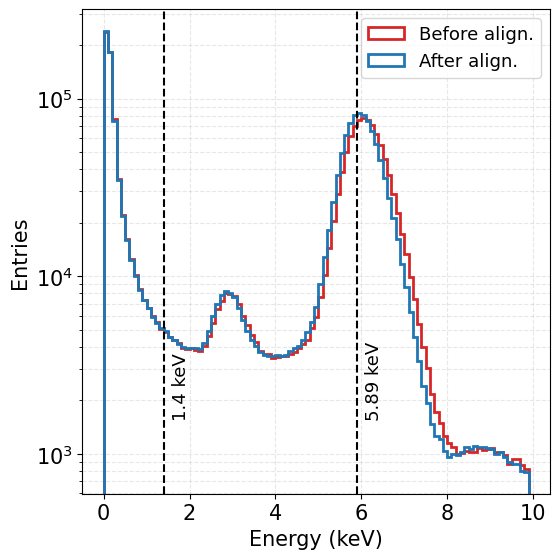

In [14]:
#plot the cumulative energy spectrums of each run aligned and compare before and after spline
bins_ = np.arange(0, 10, 0.1)

text_size = 15

fig, ax = plt.subplots(figsize=(6,6))

# histograms
ax.hist(
    energy_plot_before_corr,
    bins=bins_,
    histtype='step',
    linewidth=2,
    color='tab:red',
    label='Before align.'
)

ax.hist(
    energy_plot,
    bins=bins_,
    histtype='step',
    linewidth=2,
    color='tab:blue',
    label='After align.'
)

# axes formatting
ax.set_yscale('log')
ax.set_xlabel('Energy (keV)', fontsize=text_size)
ax.set_ylabel('Entries', fontsize=text_size)

ax.tick_params(axis='both', labelsize=text_size)

# grid (very helpful with log scale)
ax.grid(True, which='both', linestyle='--', alpha=0.3)

# vertical reference lines
lines = [
    (1.4, '1.4 keV'),
    (5.89, '5.89 keV')
]

ymin, ymax = ax.get_ylim()

for xval, label in lines:
    ax.axvline(xval, linestyle='--', color='black', linewidth=1.5)
    ax.text(
        xval + 0.2,
        ymin * 2.6,
        label,
        fontsize=text_size-2,
        rotation=90,
        verticalalignment='bottom'
    )

# legend
ax.legend(fontsize=text_size-2, frameon=True)

plt.tight_layout()
plt.show()

6
datasel1 is :            timestamp       energy           x          y       time  \
0       697505853196  1743.766740   -1.457225   2.960015  93.000779   
1       697505884858  3371.658415    0.985969   2.637536  93.000783   
2       697548475233    47.708225    9.900978   4.244295  93.006462   
3       697548531728     5.260508 -235.626221 -18.519758  93.006469   
4       697548686970  3460.613561    3.796881   3.702805  93.006490   
...              ...          ...         ...        ...        ...   
298286  106768751821  3604.164032    1.429340   2.000070  14.235832   
298287  106768848327  2796.921385    1.139292   0.866888  14.235845   
298288  106768925935  3422.583701    4.229150   3.734069  14.235855   
298289  106769076201  3679.598239   -1.709537  -0.179674  14.235875   
298290  106769137651  3430.989208    0.243856  -0.182309  14.235883   

        energy_corr  
0       1732.814144  
1       3350.481009  
2         47.408083  
3          5.227413  
4       3438.842038  

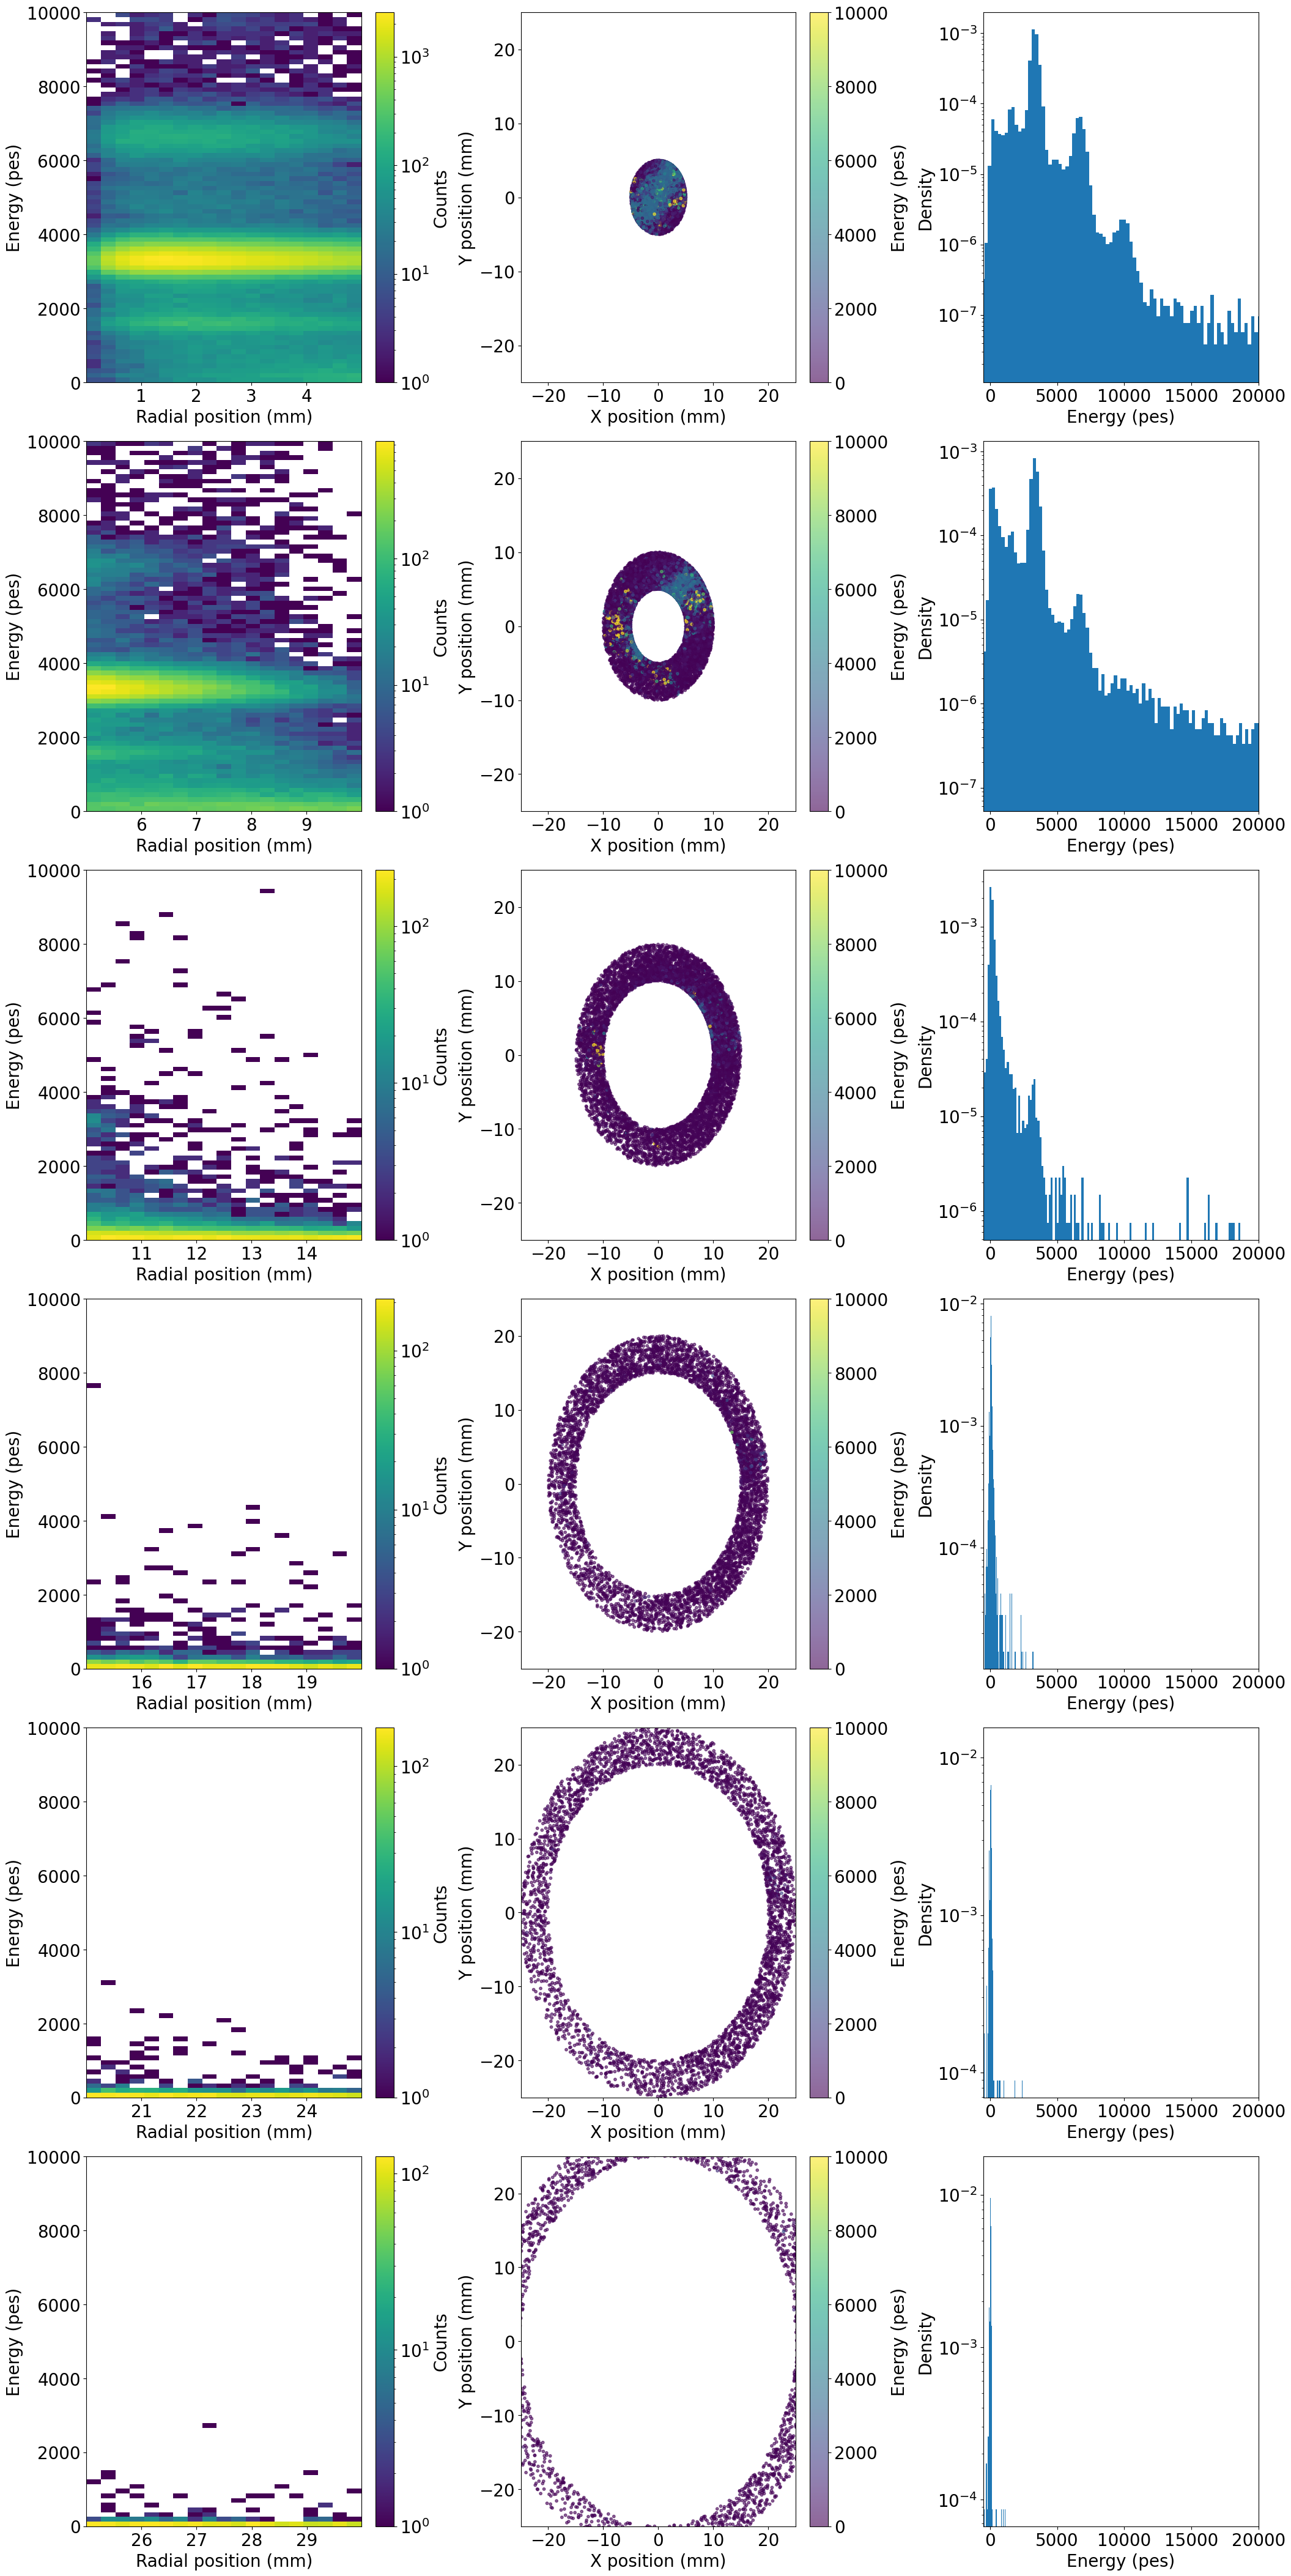

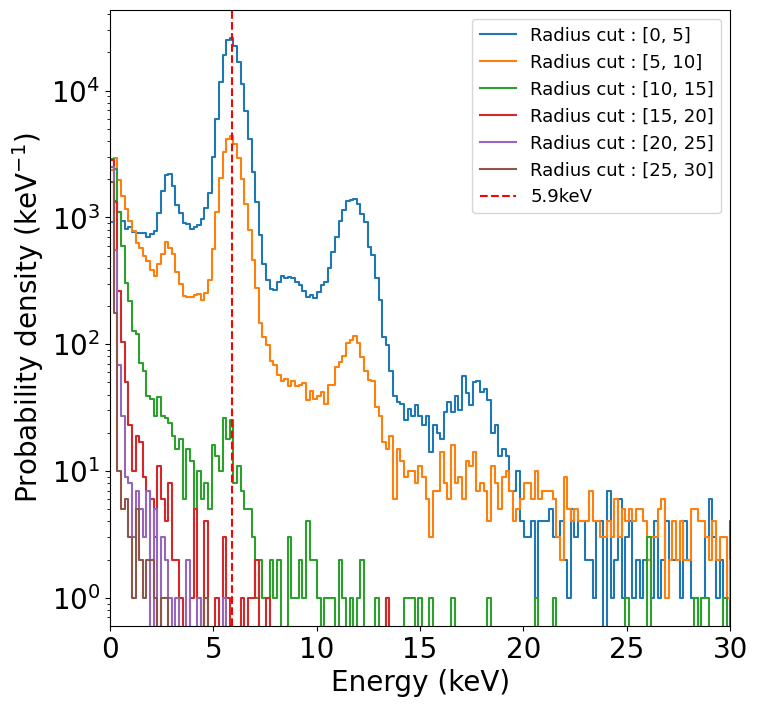

In [49]:
# study xy positions of cumulative energy from each run after alignment

cut_min = [0, 5, 10, 15, 20, 25]#, 30, 35, 40, 45]
cut_max = [5, 10, 15, 20, 25, 30]#, 35, 40, 45, 50]

size_plot = 7
row = int(len(cut_min))
print(row)

col = 3
fig, axes = plt.subplots(row, col, figsize=(size_plot * col, size_plot * row), constrained_layout=True)
axes = axes.flatten()
h_store = []



data_sel1 = pd.concat(dst_store, ignore_index=True)
print('datasel1 is :', data_sel1)
data_sel1['r'] = np.sqrt(data_sel1['x']**2 + data_sel1['y']**2)


for j in range(len(cut_min)): 

    idx = i*len(cut_min) + j

    data_sel = data_sel1[(data_sel1['r'] >= cut_min[j]) & (data_sel1['r'] <= cut_max[j])]

    print('cutmin is :', cut_min[j])
    print('cutmax is :', cut_max[j])

    x = data_sel["x"].values
    y = data_sel["y"].values
    z = data_sel["energy_corr"].values


    # definition of binnings
    rbins   = np.linspace(data_sel['r'].min(), data_sel['r'].max(), 20)
    enebins = np.linspace(0, 10000, 80)

    xbins = np.linspace(data_sel['x'].min(), data_sel['x'].max(), 1000)
    ybins = np.linspace(data_sel['y'].min(), data_sel['y'].max(), 1000)

    # ---- 2D histo energy vs r ----
    h = axes[idx*col].hist2d(
        data_sel['r'],
        data_sel['energy_corr'],
        bins=[rbins, enebins],
        norm=LogNorm(),
        cmap='viridis'
    )

    axes[idx*col].set_xlabel('Radial position (mm)')
    axes[idx*col].set_ylabel('Energy (pes)')

    cbar1 = fig.colorbar(h[3], ax=axes[idx*col])
    cbar1.set_label("Counts")

    # ---- scatter x-y with energy color ----
    sc = axes[idx*col + 1].scatter(
        x, y,
        c=z,
        cmap="viridis",
        s=10,
        alpha=0.6
    )
    sc.set_clim(0, 10000)
    axes[idx*col + 1].set_xlabel("X position (mm)")
    axes[idx*col + 1].set_ylabel("Y position (mm)")

    window = 25
    axes[idx*col + 1].set_xlim(-window, window)
    axes[idx*col + 1].set_ylim(-window, window)

    cbar2 = fig.colorbar(sc, ax=axes[idx*col + 1])
    cbar2.set_label("Energy (pes)")
    

    # ---- energy spectrum ----
    axes[idx*col + 2].hist(data_sel['energy_corr'], bins=5000, density=True)
    print(len(data_sel['energy_corr']))

    bins_ = np.arange(0, 20000, 100)
    bin_centers = 0.5 * (bins_[1:] + bins_[:-1])
    h, _ = np.histogram(data_sel['energy'], bins_)
    h_store.append(h)

    axes[idx*col + 2].set_xlim(-500, 20000)
    axes[idx*col + 2].set_yscale('log')
    axes[idx*col + 2].set_xlabel("Energy (pes)")
    axes[idx*col + 2].set_ylabel("Density")

fig, ax = plt.subplots(figsize=(8,8))
#convert = 1
for k in range(len(h_store)):
    ax.plot(bin_centers * 5.9/np.mean(coef_b_store), h_store[k],  drawstyle='steps-mid', label=f'Radius cut : [{cut_min[k]}, {cut_max[k]}]')     
    ax.set_yscale('log')
    #ax.legend(fontsize=13)
    ax.set_xlabel('Energy (keV)')
    ax.set_ylabel('Probability density (keV$^{-1}$)')
    ax.set_xlim(0,30)
ax.axvline(5.9, ls='--', color='red', label='5.9keV')
ax.legend(fontsize=13, loc='upper right')


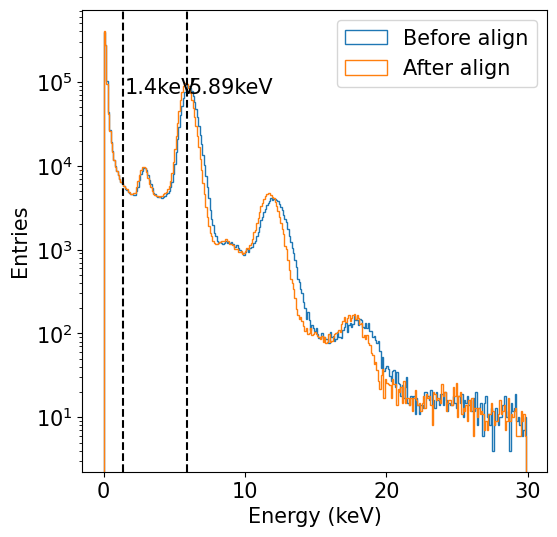

In [18]:
bins_ = np.arange(0, 30, 0.1)

text_size = 15
plt.figure(figsize=(6,6))
plt.hist(energy_plot_before_corr, bins_, histtype='step', label='Before align')
plt.hist(energy_plot , bins_, histtype='step', label='After align')
plt.xticks(fontsize=text_size)
plt.yticks(fontsize=text_size)
plt.yscale('log')
plt.xlabel('Energy (keV)', fontsize=text_size)
plt.ylabel('Entries', fontsize=text_size)
ymin, ymax = plt.ylim()
plt.axvline(1.4, linestyle='--', c='k')
plt.text(1.4 + 0.1, ymin + (ymax - ymin) * 0.1, '1.4keV', fontsize=text_size, c='k')

#plt.axvline(2.96, linestyle='--', c='k')
#plt.text(2.96 + 0.1, ymax, '2.96keV', fontsize=text_size)
plt.axvline(5.89, linestyle='--', c='k')
plt.text(5.89 + 0.1, ymin + (ymax - ymin) * 0.1, '5.89keV', fontsize=text_size)
#plt.xlim(0,10)

plt.legend(fontsize=text_size)
#plt.ylim(5e2, 2e5)

#np.savetxt("/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/GaP_G4/data/Ar_8.5bar_data.txt", energy_plot)


In [237]:
#energy_plot1 = energy_plot
energy_plot2 = energy_plot

Before align | Pic 2.8 keV : A = 26.565 +/- 2.640, mu = 2.925 ± 0.130 keV, sigma = 0.679
Before align | Pic 5.9 keV : A = 317.577 +/- 6.916, mu = 5.943 ± 0.012 keV, sigma = 0.460
After align | Pic 2.8 keV : A = 0.006 +/- 0.000, mu = 2.811 ± 0.058 keV, sigma = 0.570
After align | Pic 5.9 keV : A = 0.063 +/- 0.002, mu = 5.843 ± 0.015 keV, sigma = 0.460


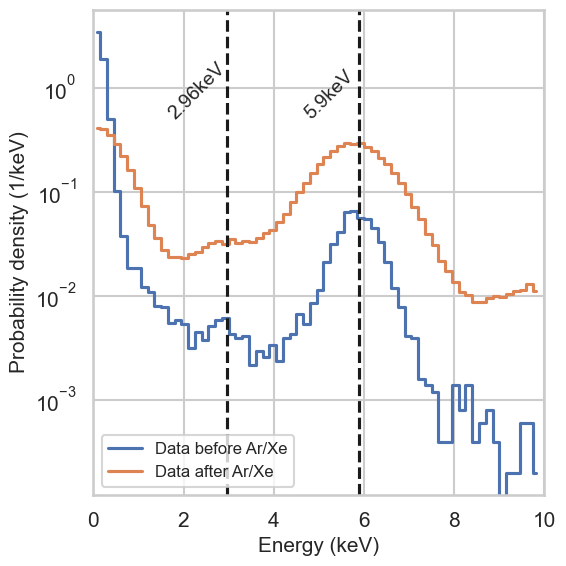

In [202]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -------------------------
# Fonction gaussienne
# -------------------------
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

bins_ = np.arange(0, 10, 0.15)
bin_centers = 0.5 * (bins_[1:] + bins_[:-1])

# -------------------------
# Histogrammes
# -------------------------
h_before, _ = np.histogram(energy_plot_before_corr, bins_)
#h_after,  _ = np.histogram(energy_plot2, bins_, density=True)
#h_2, _ = np.histogram(energy_plot1, bins_, density=True)

# -------------------------
# Fenêtres de fit indépendantes
# -------------------------
windows = {
    'Before align': {
        '2.8': (2.4, 4),
        '5.9': (4.8, 7)
    },
    'After align': {
        '2.8': (2.2, 3.6),
        '5.9': (4.5, 7.5)
    }
}

# -------------------------
# Plots
# -------------------------
text_size = 15
plt.figure(figsize=(6,6))
#plt.plot(bin_centers, h_before, drawstyle='steps-mid', label='Before align')
plt.plot(bin_centers, h_after,  drawstyle='steps-mid', label='Data before Ar/Xe')
plt.plot(bin_centers, h_2,  drawstyle='steps-mid', label='Data after Ar/Xe')

plt.yscale('log')
plt.xlabel('Energy (keV)', fontsize=text_size)
plt.ylabel('Probability density (1/keV)', fontsize=text_size)
plt.xticks(fontsize=text_size)
plt.yticks(fontsize=text_size)
plt.text(1.6, 0.5, '2.96keV', fontsize=14, rotation=45)
plt.text(4.6, 0.5, '5.9keV', fontsize=14, rotation=45)

plt.axvline(2.955, linestyle='--' , c='k')
plt.axvline(5.9, linestyle='--', c='k')

# -------------------------
# Fits
# -------------------------
for label, histo in zip(
        ['Before align', 'After align'],
        [h_before, h_after]):

    for key, (xmin, xmax) in windows[label].items():

        mask = (bin_centers >= xmin) & (bin_centers <= xmax)
        xfit = bin_centers[mask]
        yfit = histo[mask]

        # Paramètres initiaux
        A0 = yfit.max()
        mu0 = xfit[yfit.argmax()]
        sigma0 = 0.15

        try:
            popt, pcov = curve_fit(
                gaussian, xfit, yfit,
                p0=[A0, mu0, sigma0]
            )

            A, mu, sigma = popt
            sigma_mu = np.sqrt(pcov[1,1])
            sigma_A = np.sqrt(pcov[0, 0])
            xfine = np.linspace(xmin, xmax, 300)
            ygauss = gaussian(xfine, *popt)

            #plt.plot(xfine, ygauss, '--', lw=2)

            print(f"{label} | Pic {key} keV : A = {A:.3f} +/- {sigma_A:.3f}, mu = {mu:.3f} ± {sigma_mu:.3f} keV, sigma = {sigma:.3f}")

        except RuntimeError:
            print(f"Fit échoué pour {label}, pic {key}")

plt.xlim(0,10)
plt.legend(fontsize=text_size-3, loc='lower left')
plt.tight_layout()
plt.show()


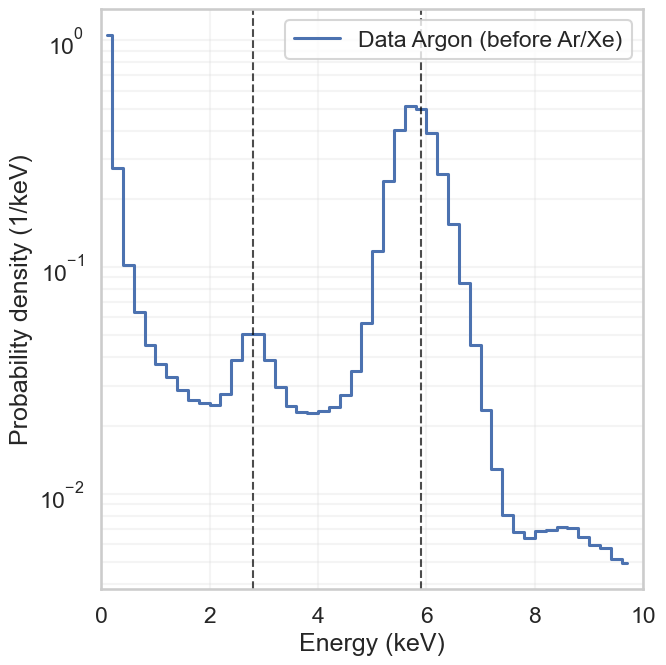

In [238]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Style Seaborn
# -------------------------
sns.set_theme(style="whitegrid", context="talk")
sns.set_palette("deep")

bins_ = np.arange(0, 10, 0.2)
bin_centers = 0.5 * (bins_[1:] + bins_[:-1])

# -------------------------
# Histogrammes
# -------------------------
h_before, _ = np.histogram(energy_plot_before_corr, bins_)
h_after,  _ = np.histogram(energy_plot, bins_, density=True)

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(7,7))

# Histogramme principal (normalisé)
ax.step(
    bin_centers,
    h_after,
    where="mid",
    linewidth=2.2,
    label="Data Argon (before Ar/Xe)"
)

ax.set_yscale('log')

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Probability density (1/keV)")
ax.set_xlim(0, 10)

# Lignes verticales aux pics attendus
for energy in [2.8, 5.9]:
    ax.axvline(
        energy,
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
        color="black"
    )

# Grille subtile adaptée au log
ax.grid(which="both", alpha=0.2)

ax.legend(frameon=True)
plt.tight_layout()
plt.show()


[ 215   60 -102  -82  -58  -14   -6   -2    2   -1   -3   -4    7   -2
   -2    3   -9    1    2   -2    6   -4    1    0   -2    8   -1   -2
    8   -5   -5    1   -3    3   -3    0   -1    2    0    3   -5    2
    3    6   -7   -1    3    2    5    2   21   24   30   13   15   62
   31   23   -5  -34   10  -18  -40  -22  -28   -9  -28   -9  -21   -9
   -9   -3   -4   -1    1    4   -7   -1    0    1    2    2    0   -2
   -3    0    1    2   -2    1   -4   -1    1    0    2   -1    1    0
   -2]


<ErrorbarContainer object of 3 artists>

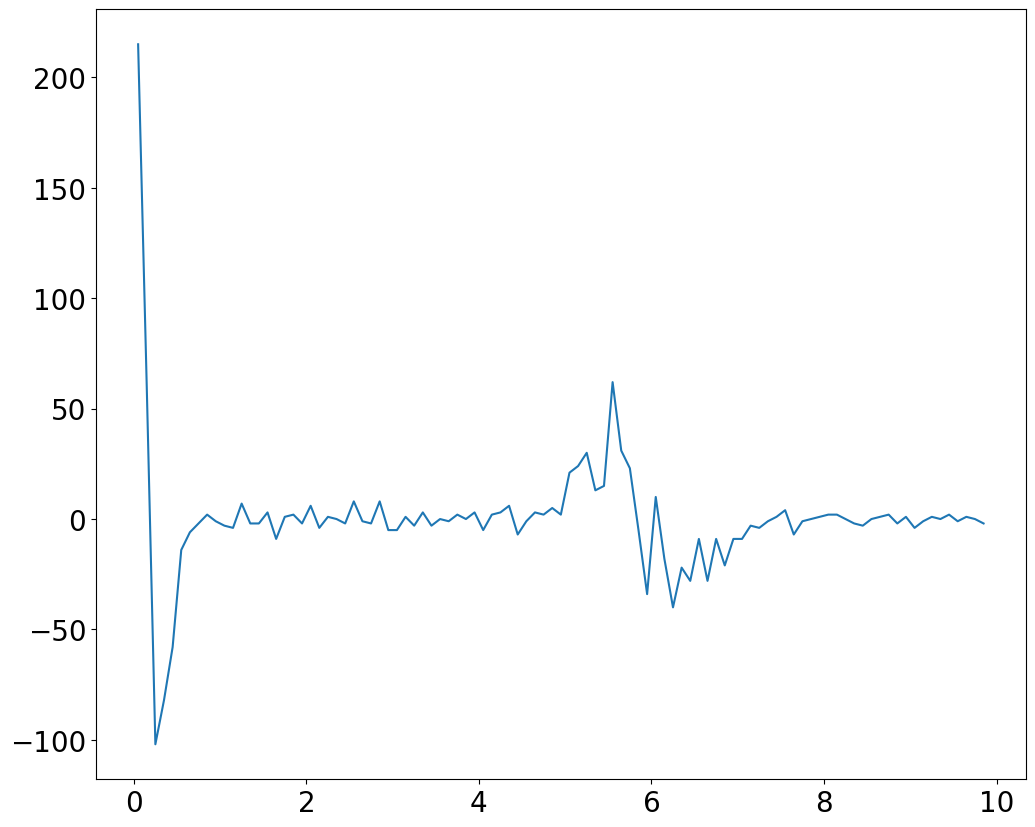

In [155]:
#plt.hist(energy_plot_before_corr, bins_, histtype='step', label='Before align')
#plt.hist(energy_plot , bins_, histtype='step', label='After align')


count1, bin_edges1 = np.histogram(energy_plot_before_corr, bins_)
count2, bin_edges2 = np.histogram(energy_plot, bins_)
bin_centers1 = (bin_edges1[1:] + bin_edges1[:-1]) / 2
bin_centers2 = (bin_edges2[1:] + bin_edges2[:-1]) / 2

diff = count2 - count1
print(diff)
plt.errorbar(bin_centers1, diff)

/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


55Fe peak : 5.824342847896562 0.49582242001049415
Al peak   : -20.383322137477144 6.429191093035311


/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


Text(1.05, 500000.0, 'Background induced threshold')

/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/IPython/core/events.py:89: UserWarning: AutoMinorLocator does not work with logarithmic scale
  func(*args, **kwargs)


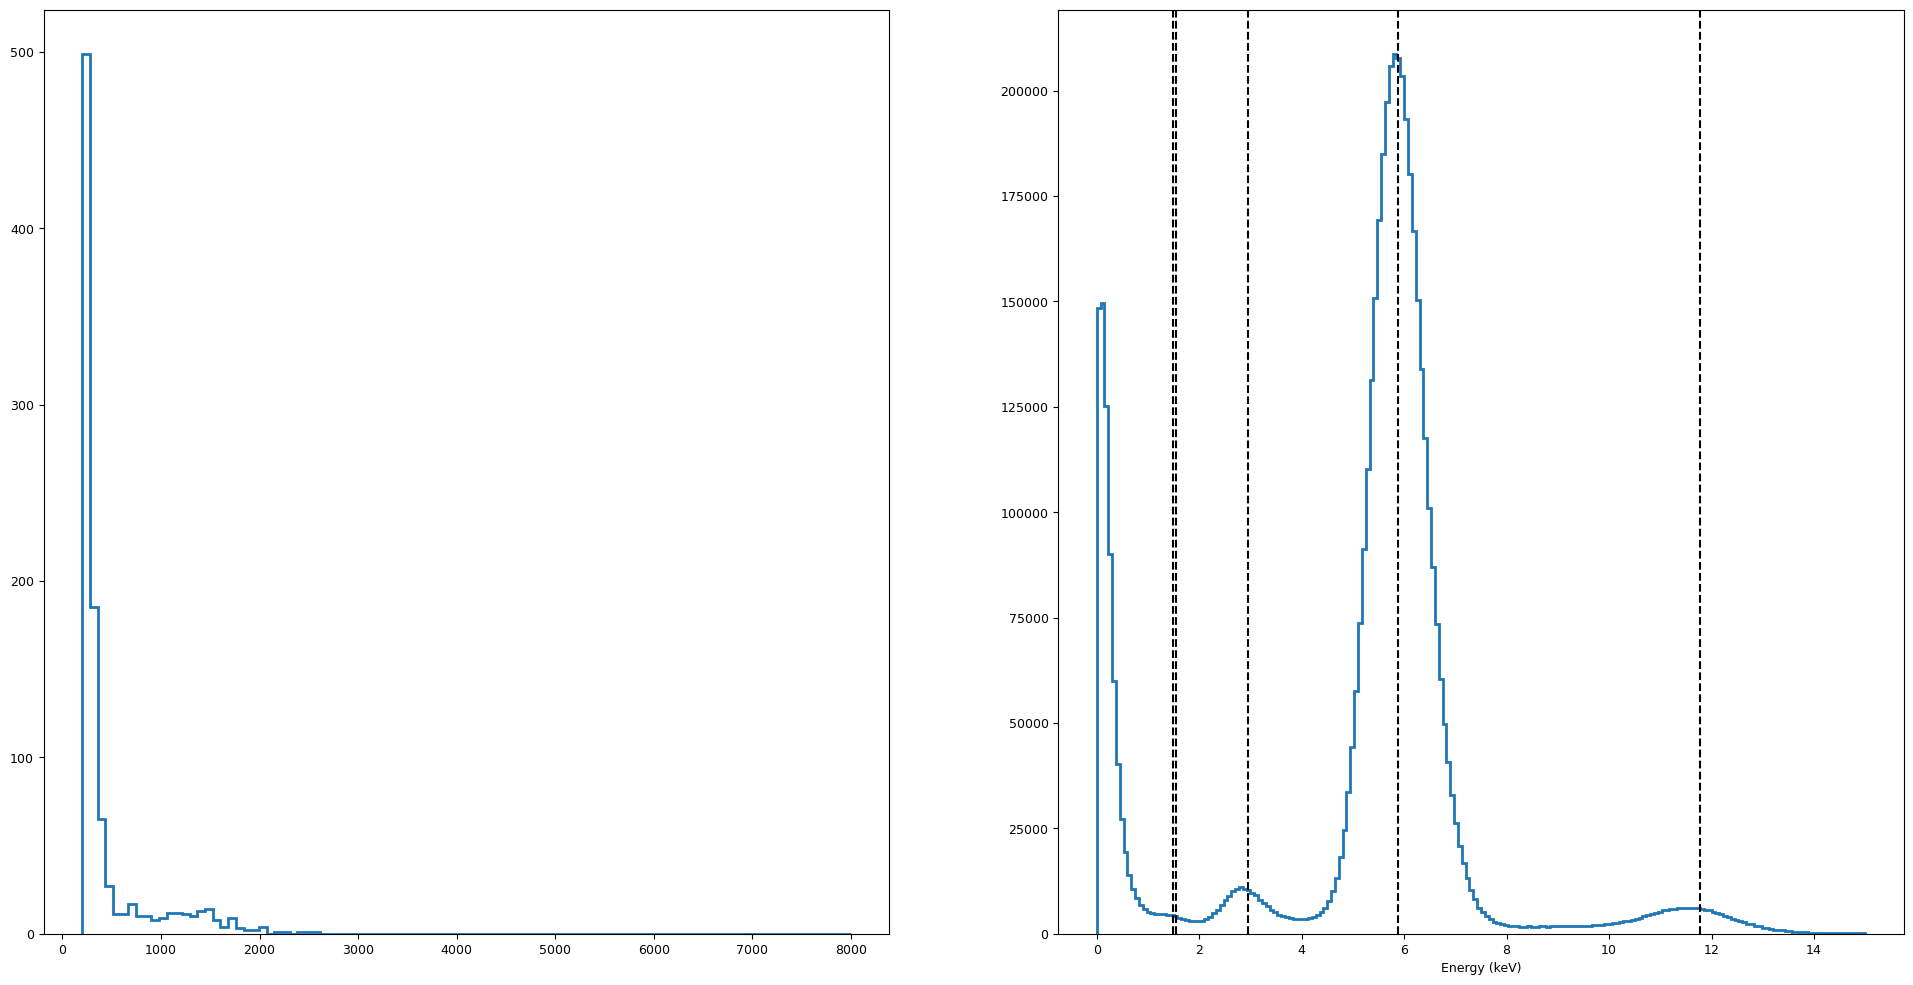

/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: AutoMinorLocator does not work with logarithmic scale
  fig.canvas.print_figure(bytes_io, **kw)


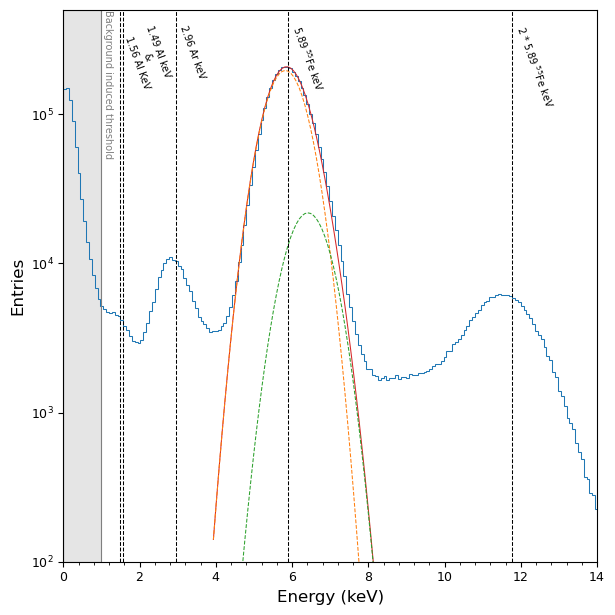

In [29]:
### ARGON

# ============================================================
# 1. FIGURE SETUP AND STYLE PARAMETERS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(24, 12))

plot_size     = 6
font_size     = 9
leg_font_size = 7
text_size     = 7
dpi           = 1200
marker_size   = 1.5
line_width    = 0.75
padding       = 0.2
rot_text      = 290

mpl.rcParams["font.size"] = font_size

fig = plt.figure(figsize=(plot_size, plot_size),
                 tight_layout={'pad': padding})
axes2 = plt.gca()


# ============================================================
# 2. HISTOGRAM DEFINITIONS & GENERAL PARAMETERS
# ============================================================

enebins   = np.linspace(200,   8000, 101)
enebins_c = np.linspace(0.,    15,   201)

# === variable à tracer ===
energy_var = np.array(energy_plot)

# === Poids ===
weights = np.ones(len(energy_var))

normed = False
eref   = 5.9


# ============================================================
# 3. RAW HISTOGRAM (déjà en keV)
# ============================================================

y, x, *_ = axes[0].hist(
    energy_var,
    enebins,
    histtype='step',
    lw=2,
    weights=weights/len(energy_var) if normed else weights,
    label="dataset"
)
x = coref.shift_to_bin_centers(x)


# ============================================================
# 4. HISTOGRAM IN KEV
# ============================================================

axes[1].hist(
    energy_var,
    enebins_c,
    histtype='step',
    lw=2,
    weights=weights/len(energy_var) if normed else weights,
    label="dataset"
)
axes[1].set_xlabel('Energy (keV)')
#axes[1].set_yscale('log')


# ============================================================
# 5. HISTOGRAM FOR FITTING
# ============================================================

eref_kev = 5.9
centers = np.array([5.9, 6.5])
int_ratio = np.array([11142, 1299])

y, x, *_ = axes2.hist(
    energy_var,
    enebins_c,
    histtype='step',
    lw=line_width,
    weights=weights,
    alpha=1
)
x = coref.shift_to_bin_centers(x)


# ============================================================
# 6. FIRST FIT (55Fe)
# ============================================================

xd = x.copy()
yd = y.copy()

peak_center = x[y.argmax()]
sigma_ref = 150
new_sigma = sigma_ref
nsigma = 1

efit = [peak_center - nsigma * new_sigma,
        peak_center + nsigma * new_sigma]

sel_f = coref.in_range(xd, *efit)

mod = GaussianModel(prefix='g1_')
pars = mod.guess(yd[sel_f], x=xd[sel_f])
pars['g1_amplitude'].set(min=0)

for i in range(1, len(centers)):
    g = GaussianModel(prefix=f'g{i+1}_')
    mod += g
    params = g.make_params(center=pars['g1_center'],
                           sigma=pars['g1_sigma'],
                           amplitude=pars['g1_amplitude'])

    params[f'g{i+1}_center'].set(expr=f"g1_center * {centers[i]/centers[0]}")
    params[f'g{i+1}_sigma'].set(expr=f"g1_sigma * {np.sqrt(centers[i]/centers[0])}")
    params[f'g{i+1}_amplitude'].set(expr=f"g1_amplitude * {int_ratio[i]/int_ratio[0]}")

    pars.update(params)

out = mod.fit(yd[sel_f], pars, x=xd[sel_f])

sel_plot1 = (xd >= 5.9 - 2) & (xd <= 5.9 + 3)
axes2.plot(xd[sel_plot1], out.eval(x=xd)[sel_plot1],
           '-', c='C3', lw=line_width)

components = out.eval_components(x=xd)
cols = ['C1', 'C2']
for (name, model), c in zip(components.items(), cols):
    axes2.plot(xd[sel_plot1], model[sel_plot1],
               '--', lw=line_width, color=c)


# ============================================================
# 7. SECOND FIT (Al : 1.486 / 1.557)
# ============================================================

centers_low = np.array([1.486, 1.557])
int_ratio_low = np.array([1, 0.6])

sel_low = (xd >= 1) & (xd <= 2.2)
xd_low = xd[sel_low]
yd_low = yd[sel_low]

mod2 = GaussianModel(prefix="h1_")
pars2 = mod2.guess(yd_low, x=xd_low)
pars2["h1_amplitude"].set(min=0)

g2 = GaussianModel(prefix="h2_")
mod2 += g2

params2 = g2.make_params(center=pars2["h1_center"],
                         sigma=pars2["h1_sigma"],
                         amplitude=pars2["h1_amplitude"])

params2["h2_center"].set(expr=f"h1_center * {centers_low[1]/centers_low[0]}")
params2["h2_sigma"].set(expr=f"h1_sigma * {np.sqrt(centers_low[1]/centers_low[0])}")
params2["h2_amplitude"].set(expr=f"h1_amplitude * {int_ratio_low[1]/int_ratio_low[0]}")

pars2.update(params2)

out_low = mod2.fit(yd_low, pars2, x=xd_low)


# === NEW : plot full Al fit + components =====================

sel_plot2 = (xd >= 1 - 0.5) & (xd <= 1.557 + 0.5)

#axes2.plot(xd[sel_plot2], out_low.eval(x=xd)[sel_plot2],
 #          '-', c='C4', lw=line_width)

components_low = out_low.eval_components(x=xd)
cols2 = ['C5', 'C6']

#for (name, model), c in zip(components_low.items(), cols2):
 #   axes2.plot(xd[sel_plot2], model[sel_plot2],
  #             '--', lw=line_width, color=c)


# ============================================================
# 8. EXTRACT μ AND σ
# ============================================================

mu_59 = out.result.params['g1_center'].value
sigma_59 = out.result.params['g1_sigma'].value

mu_15 = out_low.result.params['h1_center'].value
sigma_15 = out_low.result.params['h1_sigma'].value

print("55Fe peak :", mu_59, sigma_59)
print("Al peak   :", mu_15, sigma_15)


# ============================================================
# 9. PLOTTING STYLING
# ============================================================

axes2.set_xlabel('Energy (keV)', fontsize=12)
axes2.set_ylabel('Entries', fontsize=12)
axes2.set_yscale('log')
axes2.set_xlim(0, 14)
axes2.set_ylim(1e2, 5e5)
axes2.xaxis.set_minor_locator(AutoMinorLocator(5))
axes2.yaxis.set_minor_locator(AutoMinorLocator(5))

energy_lines = [1.486, 1.557, 2.96, 5.89, 2 * 5.89]
y_line = [4e5] * len(energy_lines)
colors = ['k'] * len(energy_lines)

texts  = [
    '1.49 Al keV \n        &     \n 1.56 Al KeV',
    ' ',
    '2.96 Ar keV',
    r'5.89 $^{55}$Fe keV',
    r'2 * 5.89 $^{55}$Fe keV']

for color, line, text, yline in zip(colors, energy_lines, texts, y_line):
    axes[1].axvline(line, c=color, ls='--')
    axes2.axvline(line, c=color, ls='--', lw=line_width)
    axes2.text(x=line + 0.05, y=yline, s=text,
               c=color, verticalalignment='top',
               rotation=rot_text, size=text_size)

axes2.axvspan(0, 1, color='C7', alpha=0.2)
axes2.axvline(1, c='C7', lw=line_width)
axes2.text(
    x=1 + 0.05,
    y=axes2.get_ylim()[1],
    s='Background induced threshold',
    c='C7',
    verticalalignment='top',
    rotation=270,
    size=text_size
)


/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/lmfit/parameter.py:519: RuntimeWarning: invalid value encountered in sqrt
  par.stderr = sqrt(covar[vindex, vindex])
/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/uncertainties/core.py:116: RuntimeWarning: invalid value encountered in sqrt
  std_devs = numpy.sqrt(numpy.diag(covariance_mat))
/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat obje

55Fe peak : 10.98881773854585 1.1271023213065572
Al peak   : -28.964063672290493 7.8752261436912665
Ar peak   : 2.3682833910944714 0.42910510086293874
2×55Fe   : 11.11079814520302 0.9999995832502341


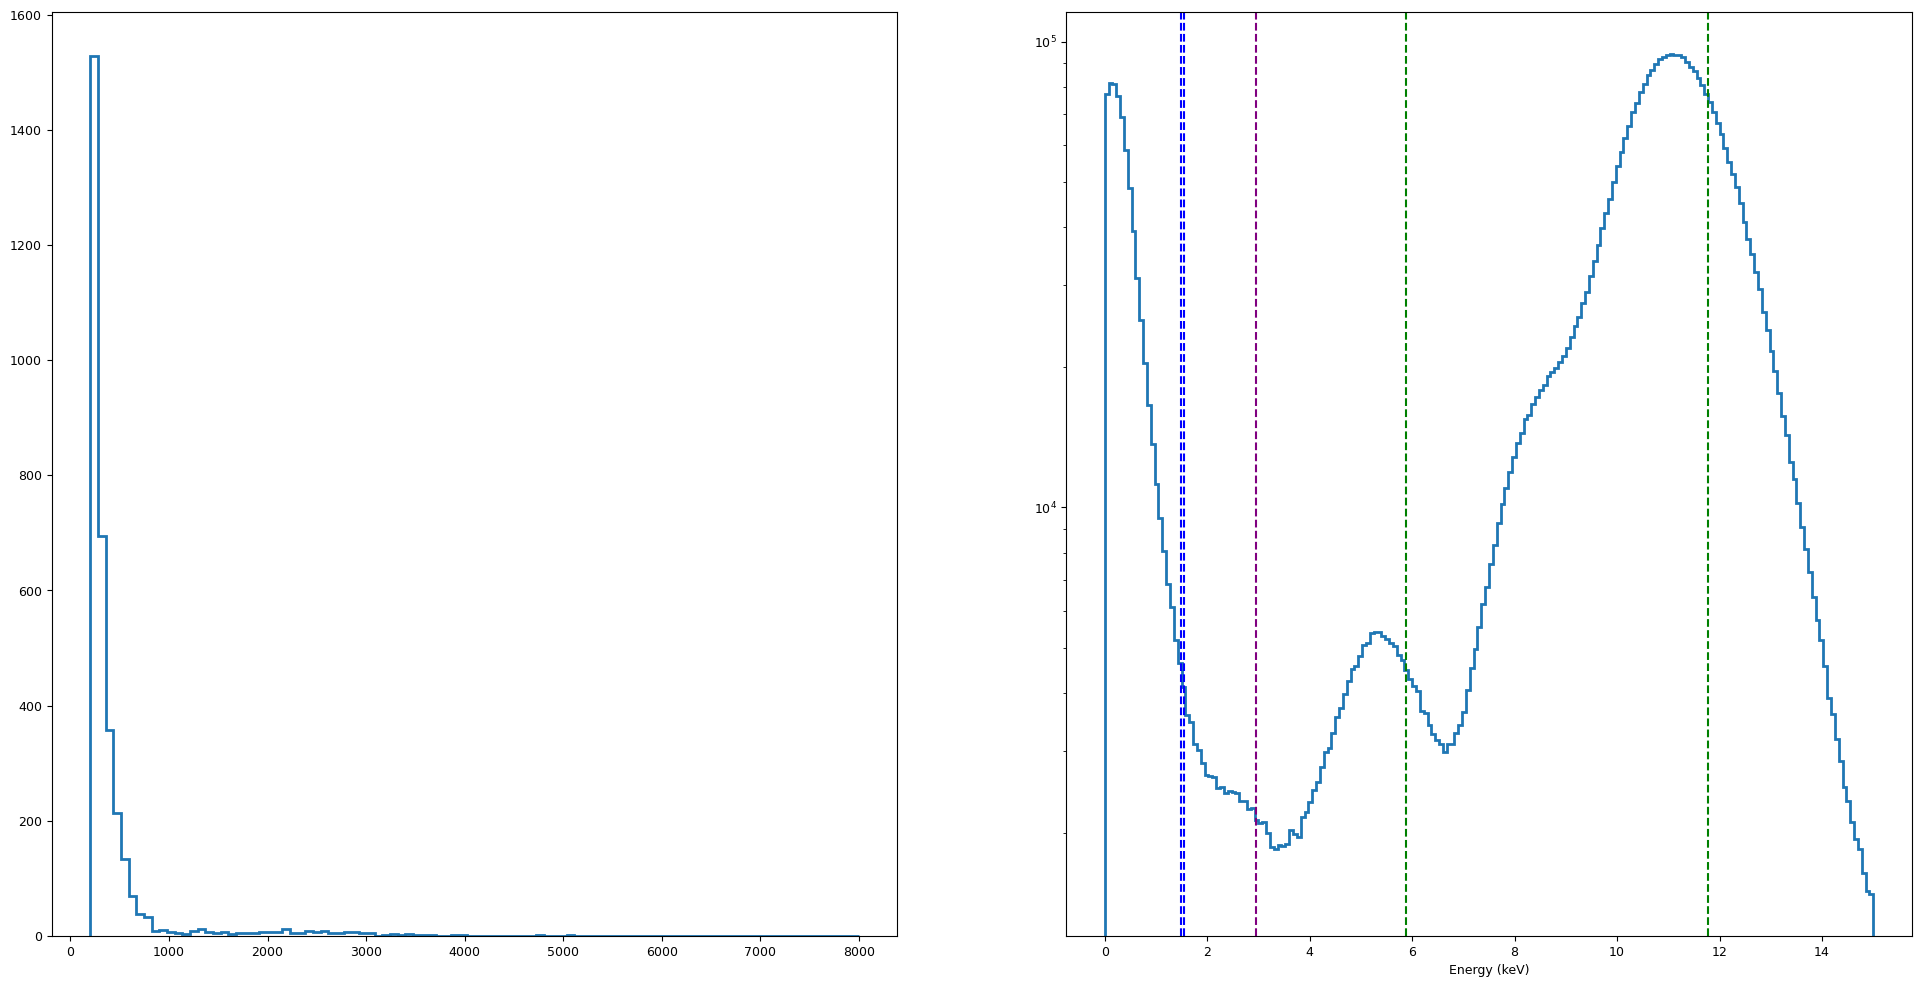

/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: AutoMinorLocator does not work with logarithmic scale
  fig.canvas.print_figure(bytes_io, **kw)


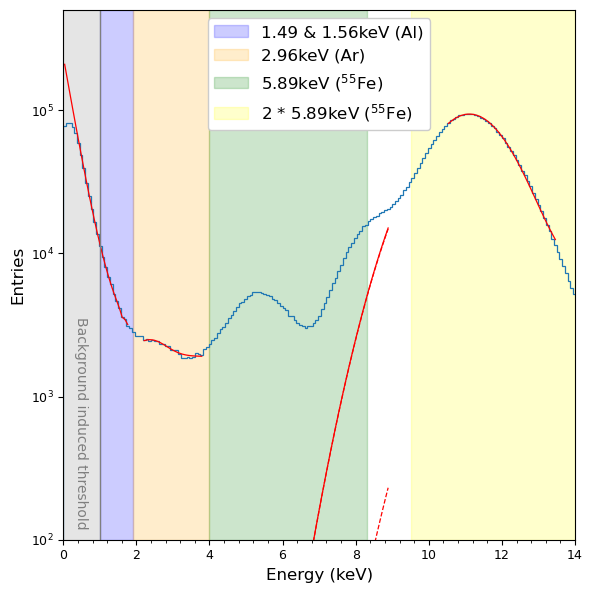

In [12]:
### ARGON

# ============================================================
# 1. FIGURE SETUP AND STYLE PARAMETERS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(24, 12))

plot_size     = 6
font_size     = 9
leg_font_size = 7
text_size     = 10
dpi           = 1200
marker_size   = 1.5
line_width    = 0.9
padding       = 0.2
rot_text      = 300

mpl.rcParams["font.size"] = font_size

fig = plt.figure(figsize=(plot_size, plot_size),
                 tight_layout={'pad': padding})
axes2 = plt.gca()


# ============================================================
# 2. HISTOGRAM DEFINITIONS & GENERAL PARAMETERS
# ============================================================

enebins   = np.linspace(200,   8000, 101)
enebins_c = np.linspace(0.,    15,   201)

energy_var = np.array(energy_plot)
weights = np.ones(len(energy_var))

normed = False
eref   = 5.9


# ============================================================
# 3. RAW HISTOGRAM (déjà en keV)
# ============================================================

y, x, *_ = axes[0].hist(
    energy_var,
    enebins,
    histtype='step',
    lw=2,
    weights=weights/len(energy_var) if normed else weights,
    label="dataset"
)
x = coref.shift_to_bin_centers(x)


# ============================================================
# 4. HISTOGRAM IN KEV
# ============================================================

axes[1].hist(
    energy_var,
    enebins_c,
    histtype='step',
    lw=2,
    weights=weights/len(energy_var) if normed else weights,
    label="dataset"
)
axes[1].set_xlabel('Energy (keV)')
axes[1].set_yscale('log')


# ============================================================
# 5. HISTOGRAM FOR FITTING
# ============================================================

y, x, *_ = axes2.hist(
    energy_var,
    enebins_c,
    histtype='step',
    lw=line_width,
    weights=weights,
    alpha=1
)
x = coref.shift_to_bin_centers(x)


# ============================================================
# 6. FIRST FIT (55Fe with 3 Gaussians)
# ============================================================

xd = x.copy()
yd = y.copy()

# central peak and satellites
centers = np.array([5.9, 6.5])
int_ratio = np.array([11142, 1299])

peak_center = 5.9
sigma_ref = 150
nsigma = 1

efit = [peak_center - nsigma * sigma_ref, peak_center + nsigma * sigma_ref]
sel_f = coref.in_range(xd, *efit)

mod = GaussianModel(prefix='g1_')
pars = mod.guess(yd[sel_f], x=xd[sel_f])
pars['g1_amplitude'].set(min=0)

# add 2 satellites
for i in range(1, len(centers)):
    g = GaussianModel(prefix=f'g{i+1}_')
    mod += g
    params = g.make_params(center=pars['g1_center'],
                           sigma=pars['g1_sigma'],
                           amplitude=pars['g1_amplitude'])
    params[f'g{i+1}_center'].set(expr=f"g1_center * {centers[i]/centers[0]}")
    params[f'g{i+1}_sigma'].set(expr=f"g1_sigma * {np.sqrt(centers[i]/centers[0])}")
    params[f'g{i+1}_amplitude'].set(expr=f"g1_amplitude * {int_ratio[i]/int_ratio[0]}")
    pars.update(params)

out = mod.fit(yd[sel_f], pars, x=xd[sel_f])

sel_plot1 = (xd >= 5.9 - 3) & (xd <= 5.9 + 3)
axes2.plot(xd[sel_plot1], out.eval(x=xd)[sel_plot1],
           '-', c='red', lw=line_width)

components = out.eval_components(x=xd)
cols = ['red', 'red', 'red']
for (name, model), c in zip(components.items(), cols):
    axes2.plot(xd[sel_plot1], model[sel_plot1], '--', lw=line_width, color=c)


# ============================================================
# 7. SECOND FIT (Al + background)
# ============================================================

sel_low = (xd >= 0.5) & (xd <= 1.9)
xd_low = xd[sel_low]
yd_low = yd[sel_low]

expo = ExponentialModel(prefix="bkg_")
g1   = GaussianModel(prefix="h1_")
g2   = GaussianModel(prefix="h2_")

mod2 = expo + g1 + g2
pars2 = expo.guess(yd_low, x=xd_low)
pars2["bkg_decay"].set(min=0)

pars_gauss1 = g1.guess(yd_low, x=xd_low)
pars_gauss1["h1_center"].set(value=1.486)
pars_gauss1["h1_sigma"].set(value=0.07)
pars_gauss1["h1_amplitude"].set(min=0)
pars2.update(pars_gauss1)

pars_gauss2 = g2.make_params(center=1.557,
                             sigma=0.07,
                             amplitude=pars_gauss1["h1_amplitude"].value * 0.6)
pars2.update(pars_gauss2)

out_low = mod2.fit(yd_low, pars2, x=xd_low)

sel_plot2 = (xd >= 0) & (xd <= 1.8)
axes2.plot(xd[sel_plot2],
           out_low.eval(x=xd)[sel_plot2],
           '-', c='red', lw=line_width)


# ============================================================
# 7bis. THIRD FIT (Ar escape peak at 2.96 keV)
# ============================================================

sel_ar = (xd >= 2.2) & (xd <= 3.8)
xd_ar = xd[sel_ar]
yd_ar = yd[sel_ar]

expo_ar = ExponentialModel(prefix="bkgAr_")
g_ar    = GaussianModel(prefix="Ar_")

mod_ar = expo_ar + g_ar
pars_ar = expo_ar.guess(yd_ar, x=xd_ar)
pars_ar["bkgAr_decay"].set(min=0)

pars_gauss_ar = g_ar.guess(yd_ar, x=xd_ar)
pars_gauss_ar["Ar_center"].set(value=2.96)
pars_gauss_ar["Ar_sigma"].set(value=0.15)
pars_gauss_ar["Ar_amplitude"].set(min=0)
pars_ar.update(pars_gauss_ar)

out_ar = mod_ar.fit(yd_ar, pars_ar, x=xd_ar)

sel_plot_ar = (xd >= 2.2) & (xd <= 3.8)
axes2.plot(xd[sel_plot_ar],
           out_ar.eval(x=xd)[sel_plot_ar],
           '-', c='red', lw=line_width)


# ============================================================
# 7ter. FOURTH FIT (2 × 5.89 keV)
# ============================================================

sel_2fe = (xd >= 9.5) & (xd <= 13.5)
xd_2fe = xd[sel_2fe]
yd_2fe = yd[sel_2fe]

expo_2fe = ExponentialModel(prefix="bkg2Fe_")
g_2fe    = GaussianModel(prefix="Fe2_")

mod_2fe = expo_2fe + g_2fe
pars_2fe = expo_2fe.guess(yd_2fe, x=xd_2fe)
pars_2fe["bkg2Fe_decay"].set(min=0)

pars_gauss_2fe = g_2fe.guess(yd_2fe, x=xd_2fe)
pars_gauss_2fe["Fe2_center"].set(value=2 * 5.89)
pars_gauss_2fe["Fe2_sigma"].set(value=0.25, min=0.05, max=1.0)
pars_gauss_2fe["Fe2_amplitude"].set(min=0)
pars_2fe.update(pars_gauss_2fe)

out_2fe = mod_2fe.fit(yd_2fe, pars_2fe, x=xd_2fe)

sel_plot_2fe = (xd >= 10.5) & (xd <= 13.5)
axes2.plot(xd[sel_plot_2fe],
           out_2fe.eval(x=xd)[sel_plot_2fe],
           '-', c='red', lw=line_width)


# ============================================================
# 8. EXTRACT μ AND σ
# ============================================================

mu_59    = out.result.params['g1_center'].value
sigma_59 = out.result.params['g1_sigma'].value

mu_15    = out_low.result.params['h1_center'].value
sigma_15 = out_low.result.params['h1_sigma'].value

mu_ar    = out_ar.result.params['Ar_center'].value
sigma_ar = out_ar.result.params['Ar_sigma'].value

mu_2fe    = out_2fe.result.params['Fe2_center'].value
sigma_2fe = out_2fe.result.params['Fe2_sigma'].value

print("55Fe peak :", mu_59, sigma_59)
print("Al peak   :", mu_15, sigma_15)
print("Ar peak   :", mu_ar, sigma_ar)
print("2×55Fe   :", mu_2fe, sigma_2fe)


# ============================================================
# 9. PLOTTING STYLING  (IDENTIQUE)
# ============================================================

axes2.set_xlabel('Energy (keV)', fontsize=12)
axes2.set_ylabel('Entries', fontsize=12)
axes2.set_yscale('log')
axes2.set_xlim(0, 14)
axes2.set_ylim(1e2, 5e5)
axes2.xaxis.set_minor_locator(AutoMinorLocator(5))
axes2.yaxis.set_minor_locator(AutoMinorLocator(5))

energy_lines = [1.486, 1.557, 2.96, 5.89, 2 * 5.89]
y_line = [2.5e6] * len(energy_lines)
colors = ['b', 'b', 'purple', 'g', 'g']

texts  = [
    '1.49keV (Al)', '1.56keV (Al) ',
    '2.96keV (Ar) ',
    r'5.89keV ($^{55}$Fe) ',
    r'2 * 5.89keV ($^{55}$Fe)']

for color, line, text, yline in zip(colors, energy_lines, texts, y_line):
    axes[1].axvline(line, c=color, ls='--')

axes2.axvspan(0, 1, color='C7', alpha=0.2)
axes2.axvspan(1, 1.9, color='blue', alpha=0.2, label='1.49 & 1.56keV (Al)')
axes2.axvspan(1.92, 4, color='orange', alpha=0.2, label='2.96keV (Ar)')
axes2.axvspan(4, 8.3, color='green', alpha=0.2, label='5.89keV ($^{55}$Fe)')
axes2.axvspan(9.5, 14, color='yellow', alpha=0.2, label='2 * 5.89keV ($^{55}$Fe)')

axes2.axvline(1, c='C7', lw=line_width)

axes2.text(
    x=0.3,
    y=axes2.get_ylim()[0] + 3.5e3,
    s='Background induced threshold',
    c='C7',
    verticalalignment='top',
    rotation=270,
    size=text_size
)

plt.legend(fontsize=12, framealpha=1)

plt.savefig(
    "/Users/ldonneger/Desktop/Energy_spectrum_Ar_2483-2484_2489-2493.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300
)


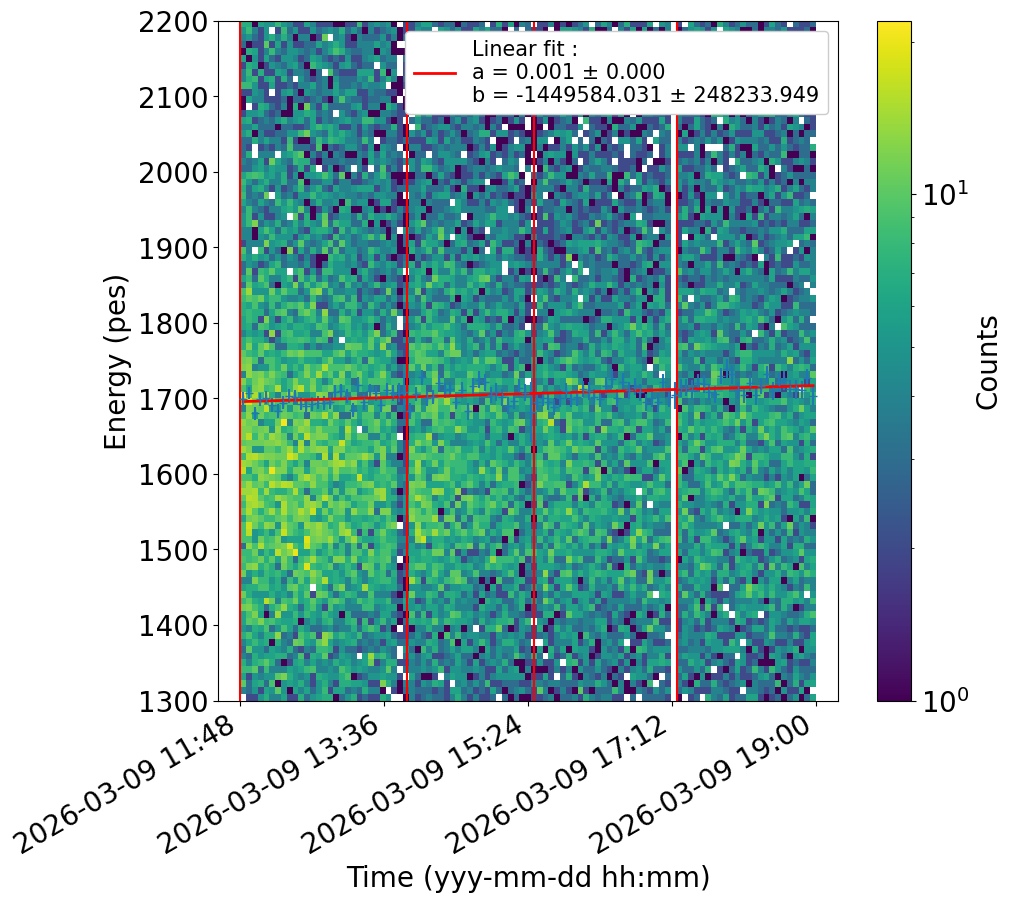

In [18]:
#To plot Energy vs Time with real dates and add the linear fitting on this global plot
import matplotlib.dates as mdates
import os
os.environ["TZ"] = "Europe/Paris"
import time
time.tzset()
import datetime

if (keV_plot == 'no'):
    ene_min = 1300
    ene_max = 2200

if (keV_plot == 'yes'):
    ene_min = 0
    ene_max = 15

x_line = []
enebins   = np.linspace(ene_min, ene_max, 100)

#To convert real timestamps into real dates

dst_conc['date'] = pd.to_datetime(dst_conc['real_timestamp'], unit='s')
dst_conc['date'] = pd.to_datetime(dst_conc['real_timestamp'], unit="s") + pd.Timedelta(minutes=30)
dst_conc["date"] = mdates.date2num(dst_conc["date"])

tmin = dst_conc['real_timestamp'].min()
tmax = dst_conc['real_timestamp'].max()

#To generate the 2D histo of Energy vs Time

tbins     = np.linspace(tmin, tmax, 100)
ebins     = np.linspace(dst_conc['energy'].min(),dst_conc['energy'].max(), 10000)

plt.figure(figsize=(10, 10))

if (keV_plot == 'no'):
    h = plt.hist2d(dst_conc['real_timestamp'], dst_conc['energy'], [tbins, enebins], norm=LogNorm(), cmap='viridis')

tprof = fitf.profileX(dst_conc['real_timestamp'], dst_conc['energy'], xrange=[tbins[0], tbins[-1]], yrange=[ene_min, ene_max], nbins=100)
        
plt.errorbar(tprof[0], tprof[1], yerr=tprof[2], linestyle='', marker='+')

x = tprof[0]
y = tprof[1]

popt, pcov = np.polyfit(x, y, deg=1, cov=True)
a, b = popt
sigma_a, sigma_b = np.sqrt(np.diag(pcov))

plt.plot(x, a * x + b, '-', label=f'Linear fit :\na = {a:.3f} ± {sigma_a:.3f}\nb = {b:.3f} ± {sigma_b:.3f}', color='red', linewidth=2)
plt.legend(fontsize=15, framealpha=1)
plt.colorbar(h[3], label='Counts')

ax = plt.gca()


def format_timestamp(x, pos=None): #function to plot the x axis in the good format
    return datetime.datetime.utcfromtimestamp(x).strftime('%Y-%m-%d %H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(format_timestamp))

xmin, xmax = dst_conc['real_timestamp'].min(),dst_conc['real_timestamp'].max()
num_ticks = 5  # Number of thick on x axis
new_ticks = np.linspace(xmin, xmax, num_ticks)
ax.set_xticks(new_ticks)

plt.gcf().autofmt_xdate()

ymin, ymax = plt.ylim()

time_max = len(line_coord)

color = ['red']

for i in range(len(timestamp)):
    if (getters[i] == 'C'):
        plt.axvline(timestamp[i], color = 'blue')
    if (getters[i] == 'H'):
        plt.axvline(timestamp[i], color = 'red')
    if (getters[i] == 'H/C'):
        plt.axvline(timestamp[i], color = 'darkorange')

plt.xlim(dst_conc['real_timestamp'].min() - 1000, dst_conc['real_timestamp'].max() + 1000)
plt.xlabel('Time (yyy-mm-dd hh:mm)')
#plt.ylabel('Energy (keV)')
if (keV_plot == 'no'):
    plt.ylabel('Energy (pes)')

#plt.savefig('/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/Energy_vs_Time/Runs_together_'+str(np.min(run_nb))+'_'+str(np.max(run_nb))+'.png', bbox_inches='tight')



33


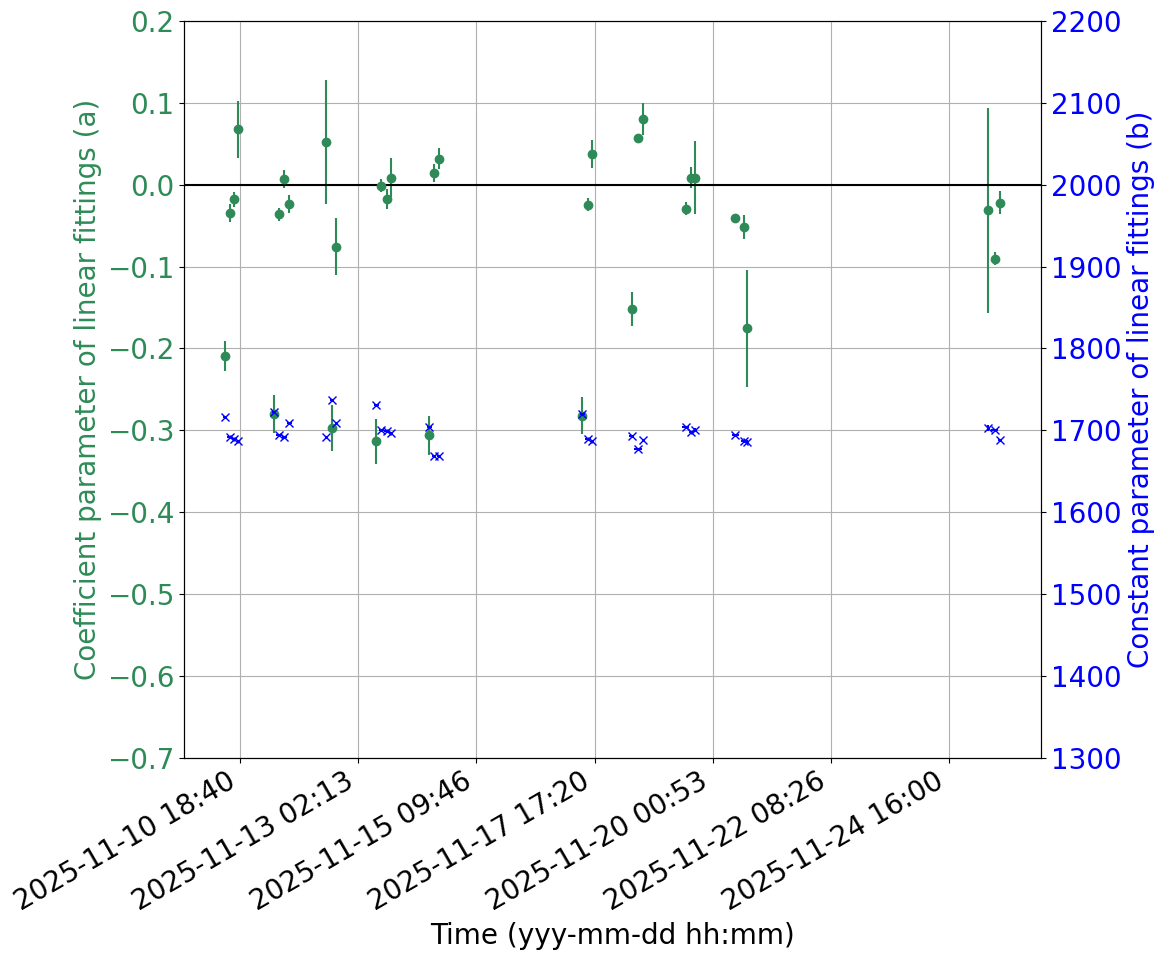

In [39]:

from matplotlib.ticker import MultipleLocator
print(len(coef_a_store))
#popt, pcov = np.polyfit(mid_time_store, coef_a_store, deg=1, cov=True)
#a, b = popt
#sigma_a, sigma_b = np.sqrt(np.diag(pcov))
#popt, pcov = np.polyfit(mid_time_store, coef_b_store, deg=1, cov=True)
#c, d = popt
#sigma_c, sigma_d = np.sqrt(np.diag(pcov))

fig, ax1 = plt.subplots()


#line5 = ax1.plot(x, y1, 'o', color='g', label='Day1')
ax1.errorbar(mid_time_store, coef_a_store, xerr=err_period, yerr=sigma_a_store, marker='o', linestyle='', color='seagreen')#, label='Day1')
#ax1.plot(x, y1_1, 'o', color='lime', label='Day2')
#line6 = ax1.errorbar(x, y, yerr=y1_1_err, marker='o', linestyle='', color='seagreen')#, label='Day2')
#ax1.plot(mid_time_store, a * np.array(mid_time_store) + b, '-', label=f'Linear fit (coeff a) :\na = {a:.3f} ± {sigma_a:.3f}\nb = {b:.3f} ± {sigma_b:.3f}\n', color='red', linewidth=2)
ax1.set_ylim(-0.7, 0.2)
#print(a - c)
ax1.set_xlabel('Time (yyy-mm-dd hh:mm)')
ax1.set_ylabel("Coefficient parameter of linear fittings (a)", color='seagreen')
#ax1.legend(loc='upper left')
ax1.tick_params(axis='y', labelcolor='seagreen')


ax2 = ax1.twinx()

ax2.errorbar(mid_time_store, coef_b_store, xerr=err_period, yerr=sigma_b_store, marker='x', linestyle='', color='b')#, label='Day1')
#ax2.plot(mid_time_store, c * np.array(mid_time_store) + d, '-', label=f'Linear fit (coeff b) :\na= {c:.3f} ± {sigma_c:.3f}\nb = {d:.3f} ± {sigma_d:.3f}\n', color='orange', linewidth=2)

#line3 = ax2.errorbar(x, y2, yerr=y2_err, linestyle='-', color='b', label='Day 1')
#line4 = ax2.errorbar(x, y2_2, yerr=y2_2_err, linestyle='--', color='b', label='Day 2')
#ax2.legend(loc='upper left')
ax2.set_ylabel("Constant parameter of linear fittings (b)", color='b')

ax2.tick_params(axis='y', labelcolor='b')
ax2.set_ylim(ene_min, ene_max)
#ax1.set_ylim(0, 1.5)
#ax1.legend( loc='lower left',fontsize=16, framealpha=1)

#ax2.legend( loc='lower right',fontsize=16, framealpha=1)
ax1.grid(True)
ax = plt.gca()


def format_timestamp(x, pos=None):
    return datetime.datetime.utcfromtimestamp(x).strftime('%Y-%m-%d %H:%M')

ax.xaxis.set_major_formatter(plt.FuncFormatter(format_timestamp))


xmin, xmax = dst_conc['real_timestamp'].min(),dst_conc['real_timestamp'].max()

plt.gcf().autofmt_xdate()
ax1.axhline(0, color='black')
fig.tight_layout()
plt.savefig('/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/Energy_vs_Time/Fit_Runs_together_'+str(np.min(run_nb))+'_'+str(np.max(run_nb))+'.png', bbox_inches='tight')


0.0


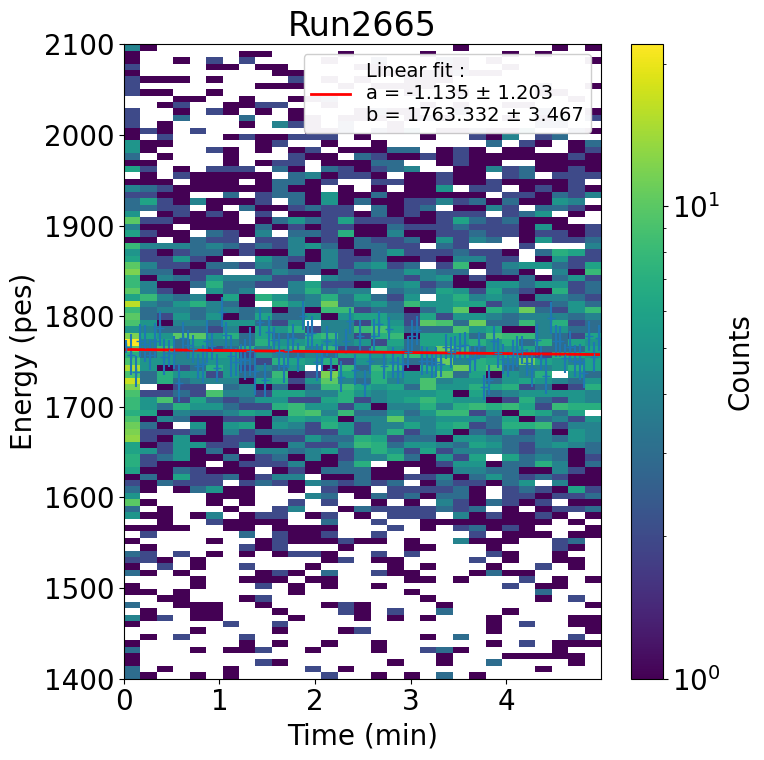

5.001841367333333


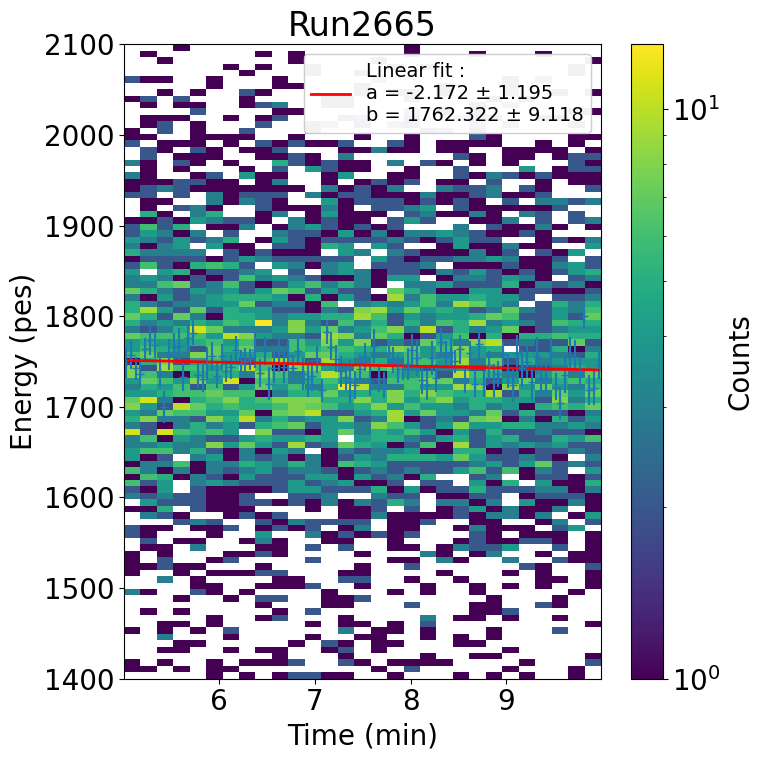

10.004618930933335


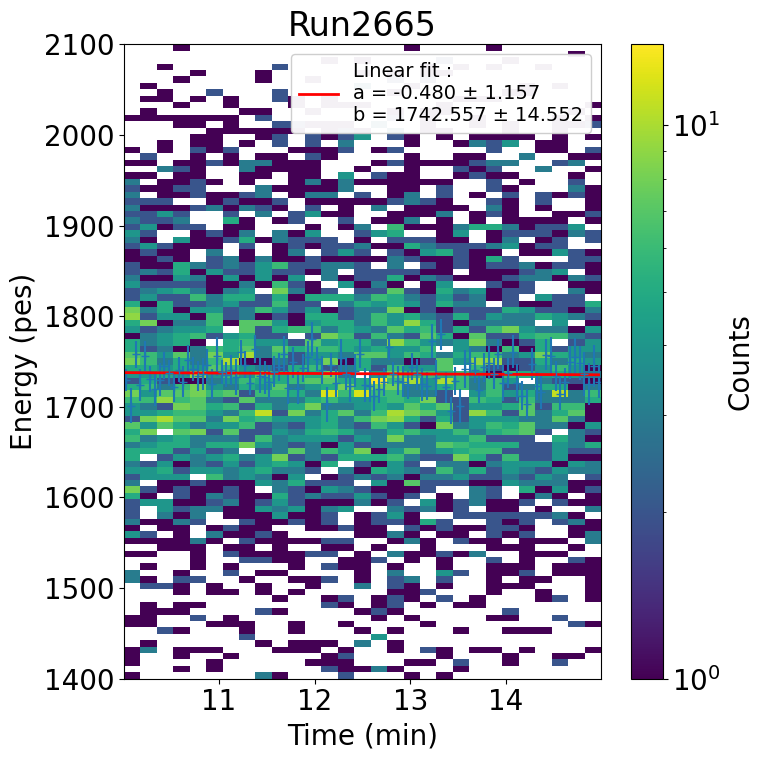

15.003391779600001


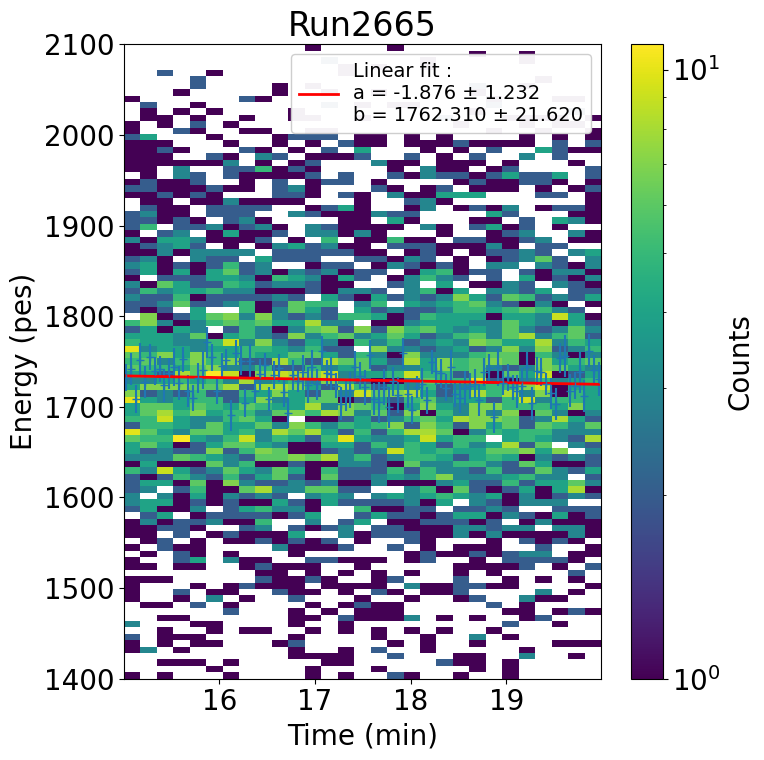

20.000224758


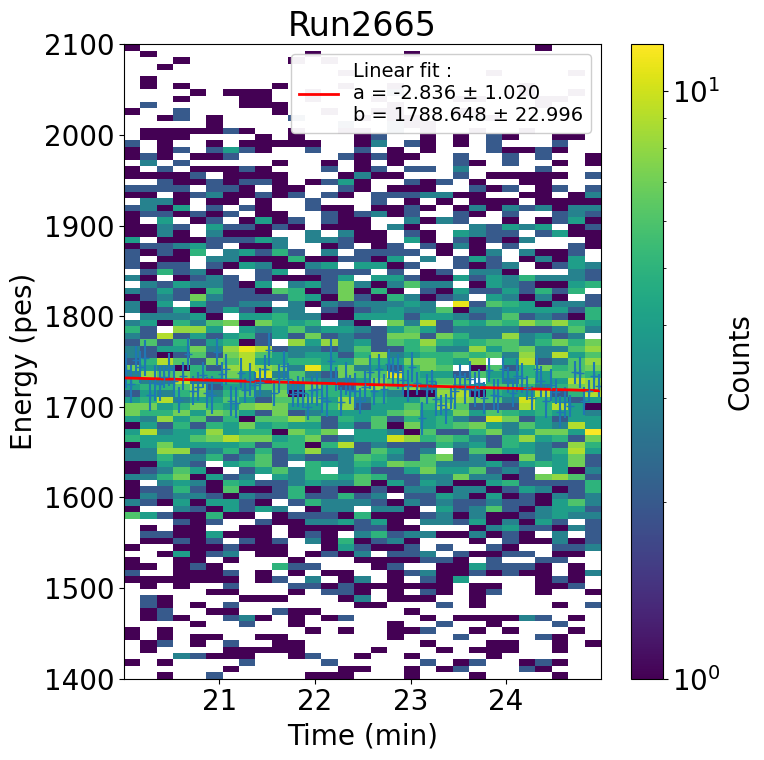

25.001591586533333


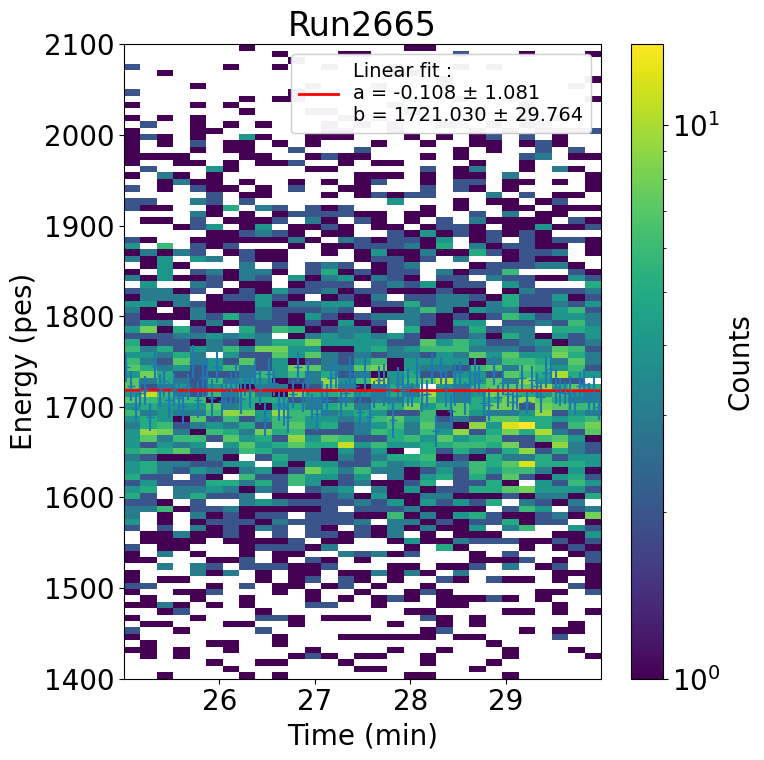

30.008175591200004


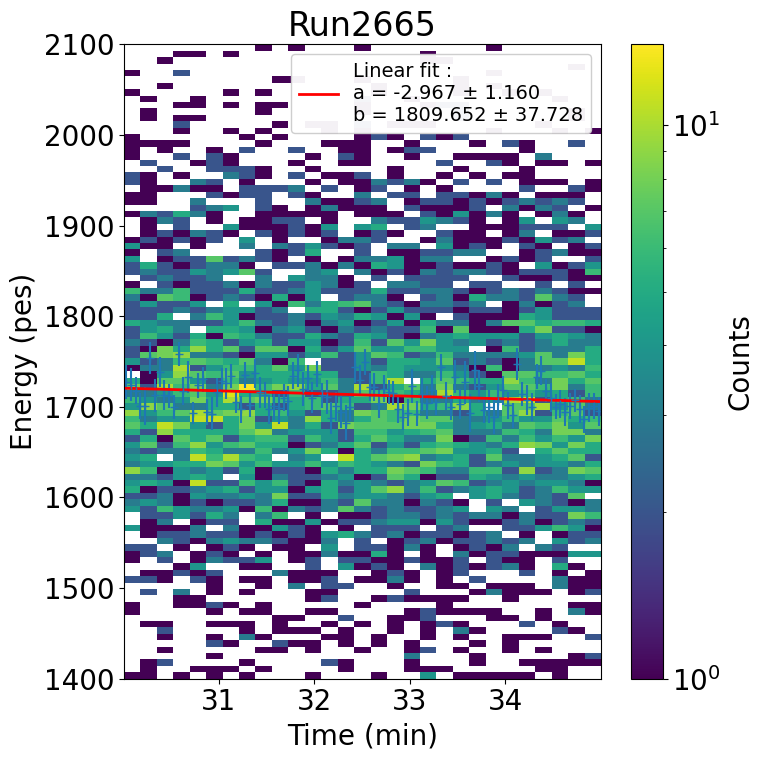

35.00806962733334


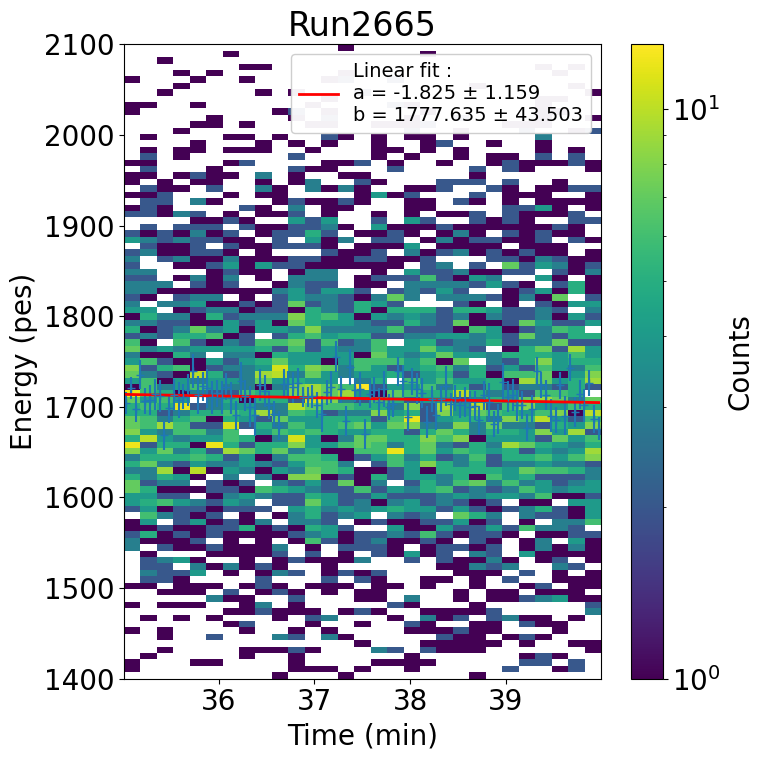

40.00540422826667


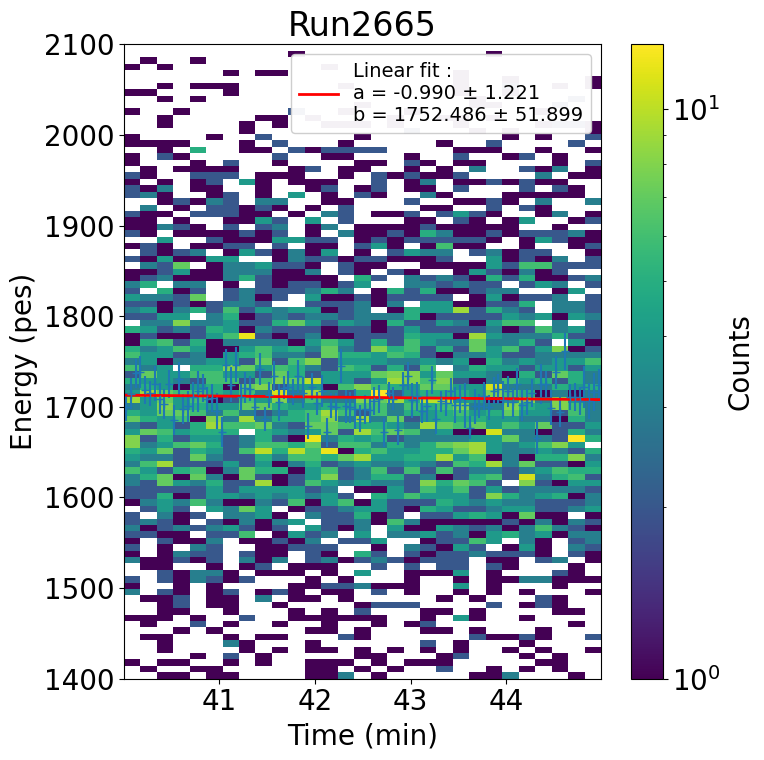

45.0028523152


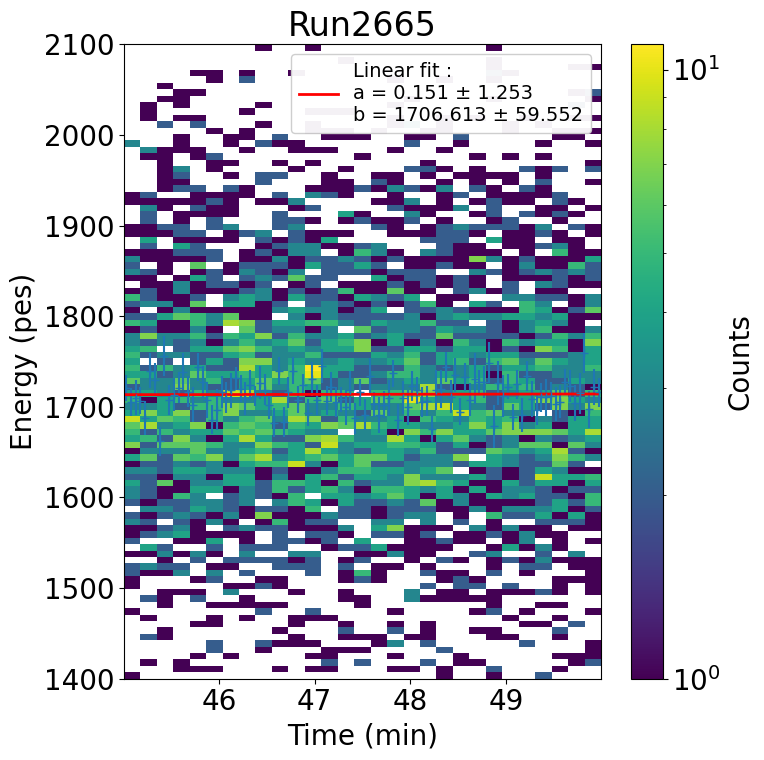

50.0063824288


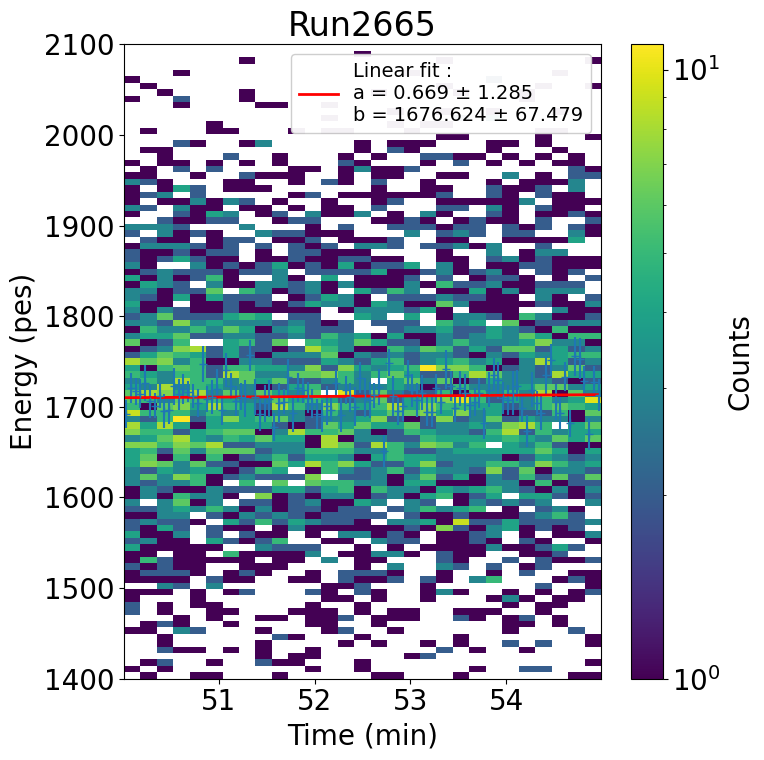

55.01037753440001


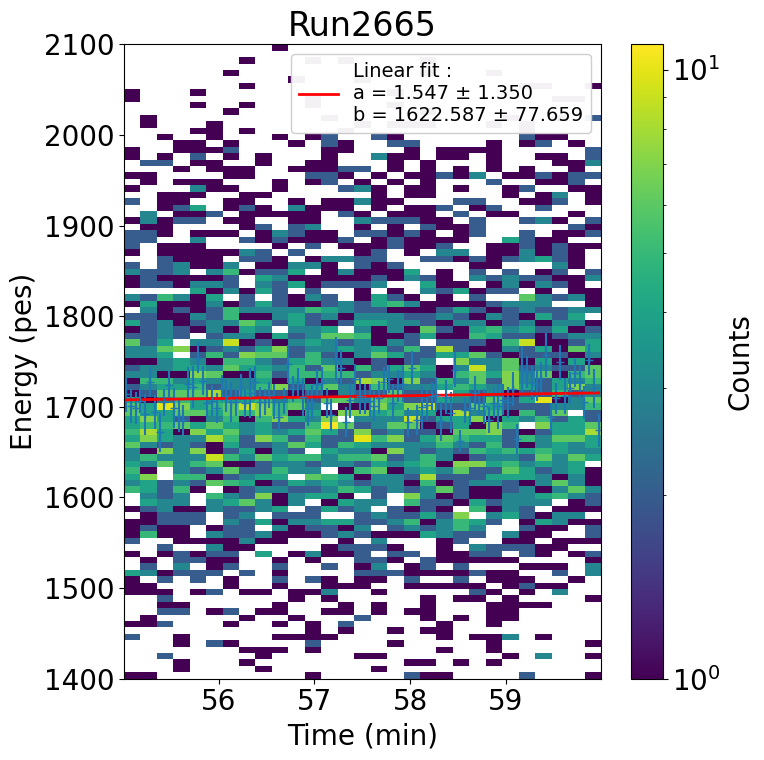

60.00442926506667


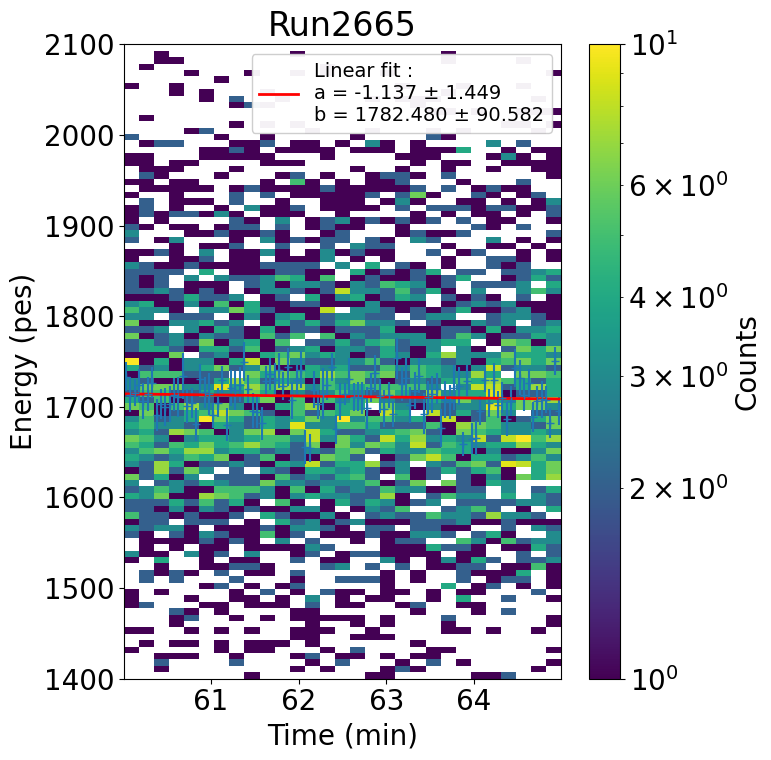

65.00937342813333


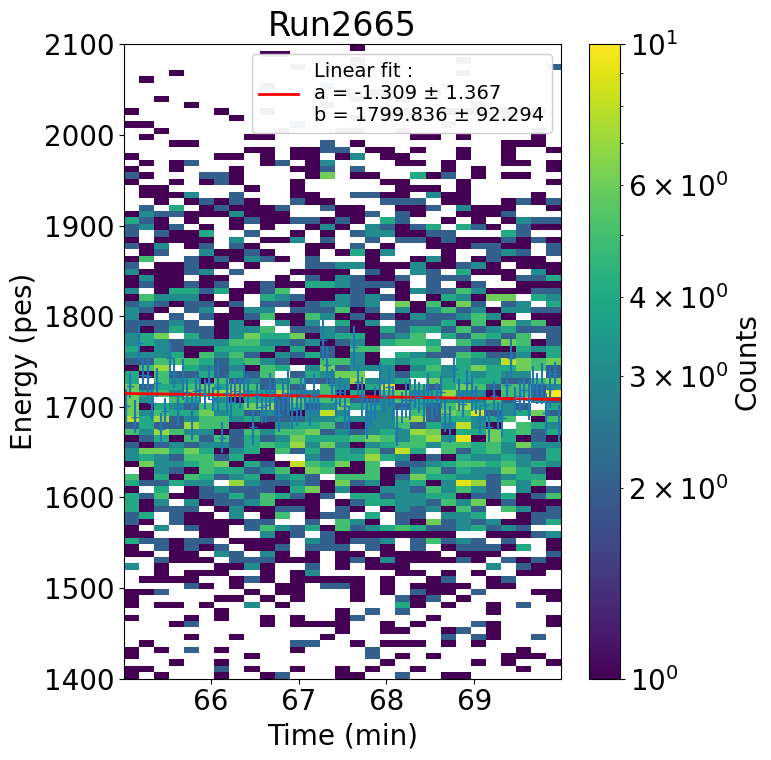

70.0042443988


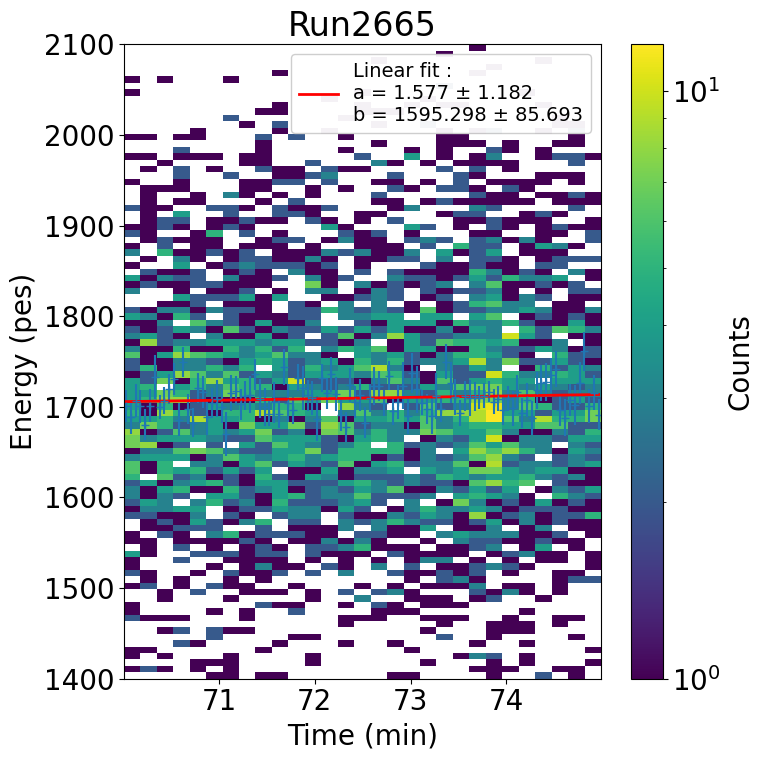

75.00473492226666


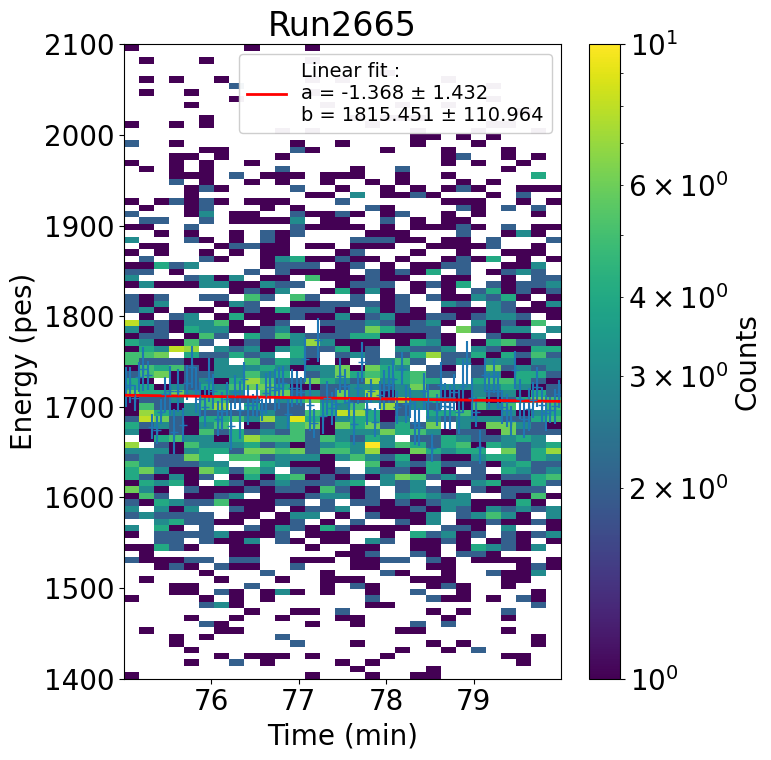

80.01527871786668


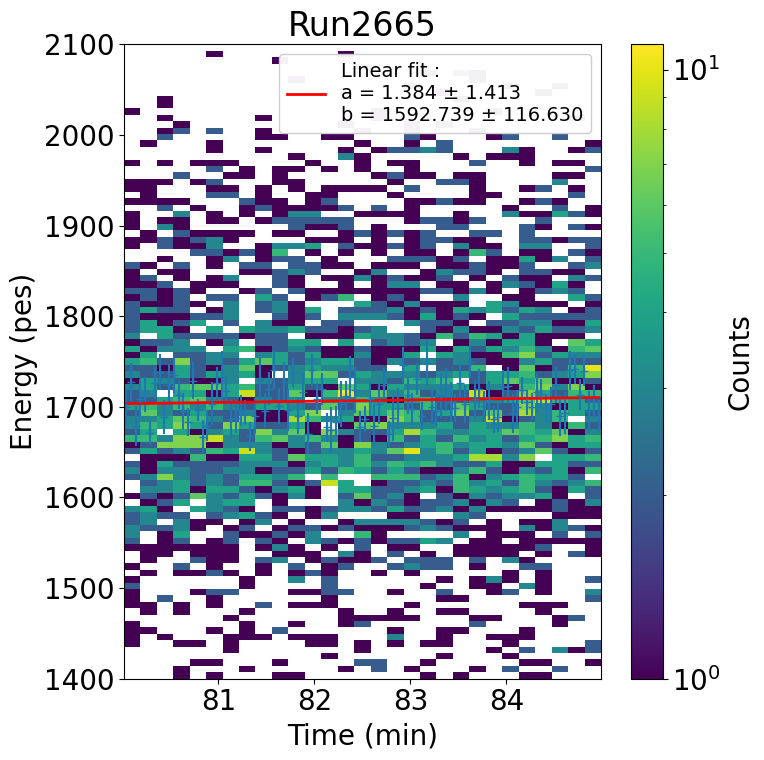

85.0012088928


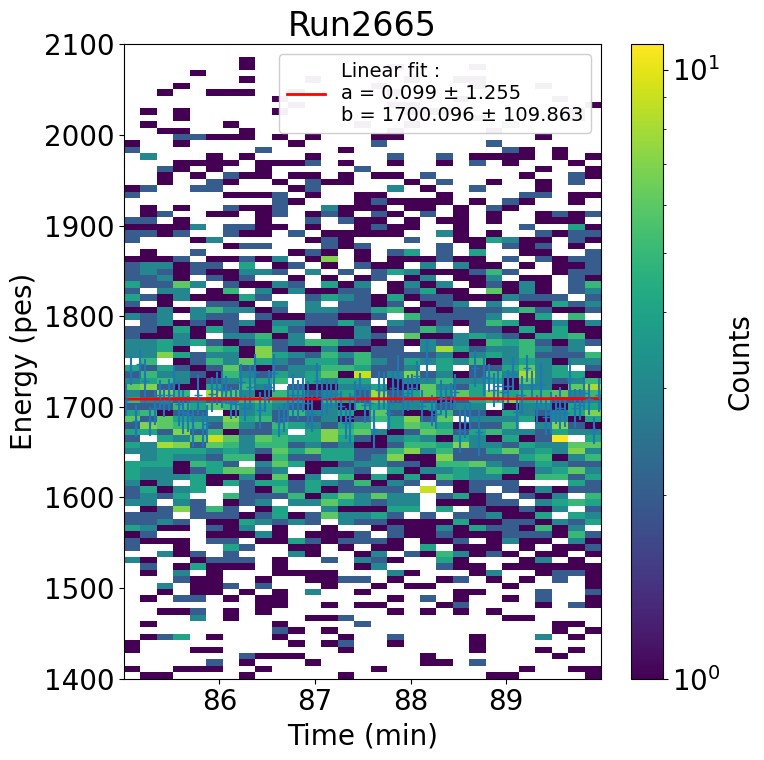

90.00311291346667


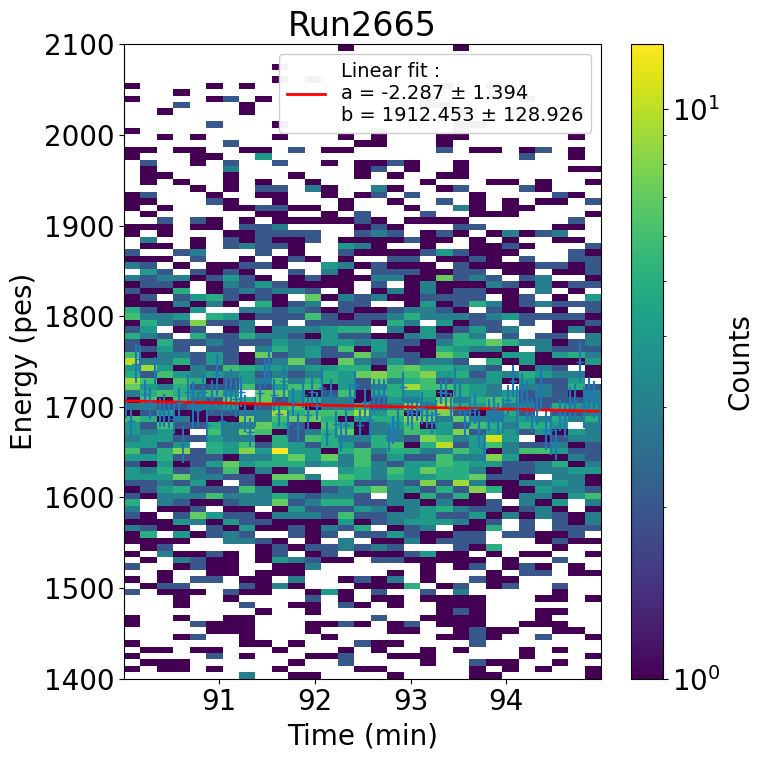

95.00103444280002


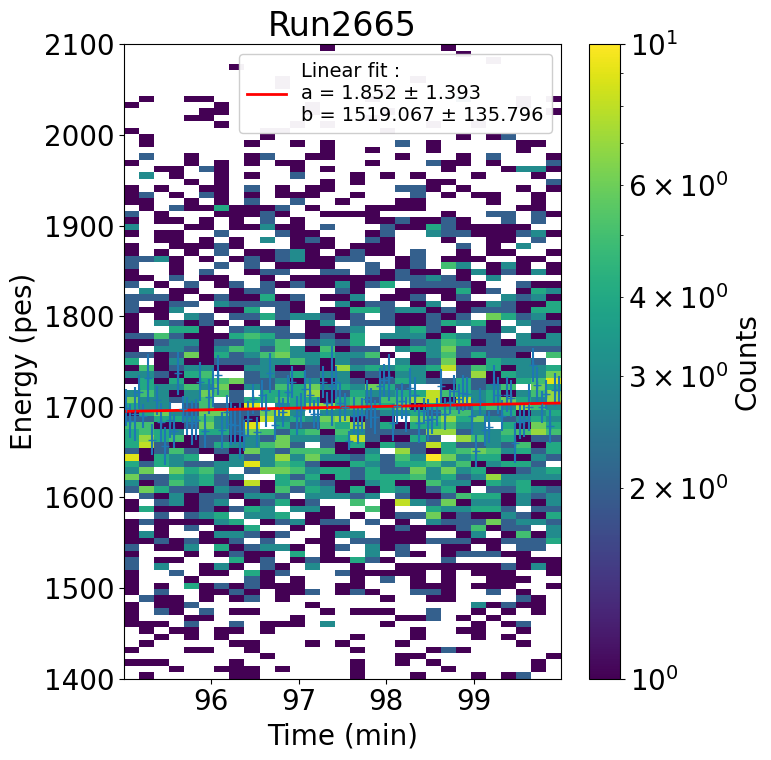

100.01204245573334


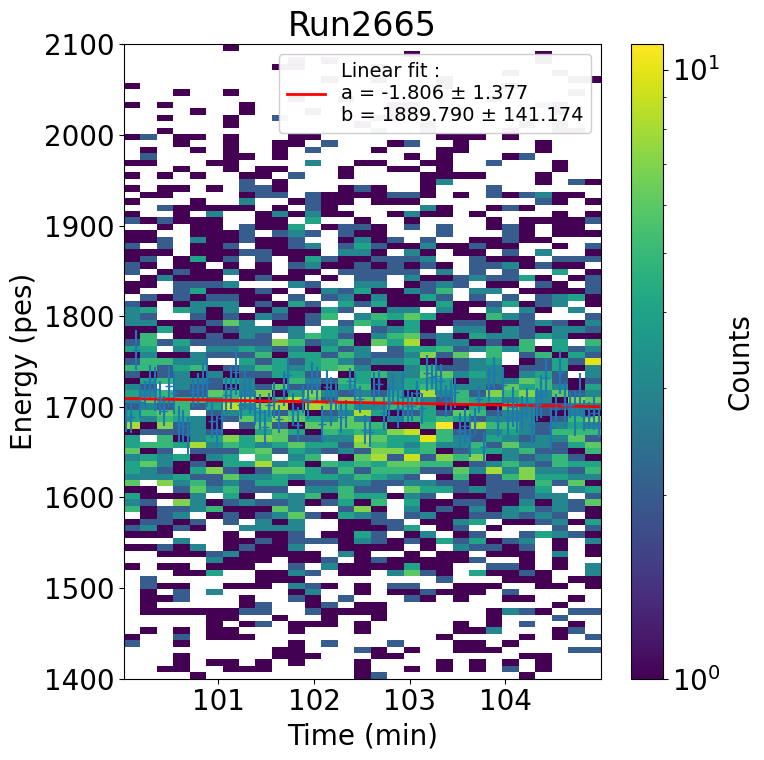

105.010457706


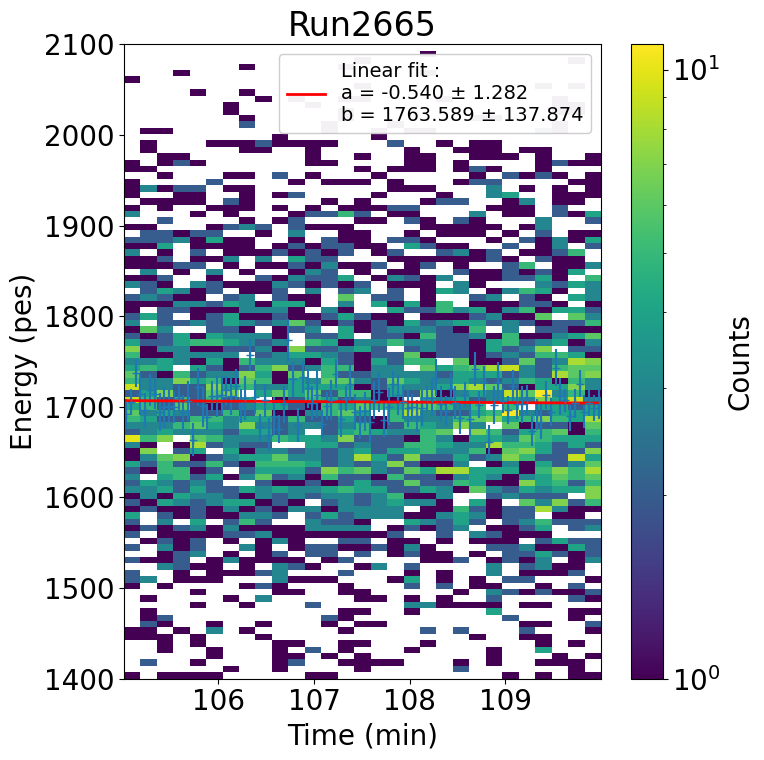

110.00000801733334


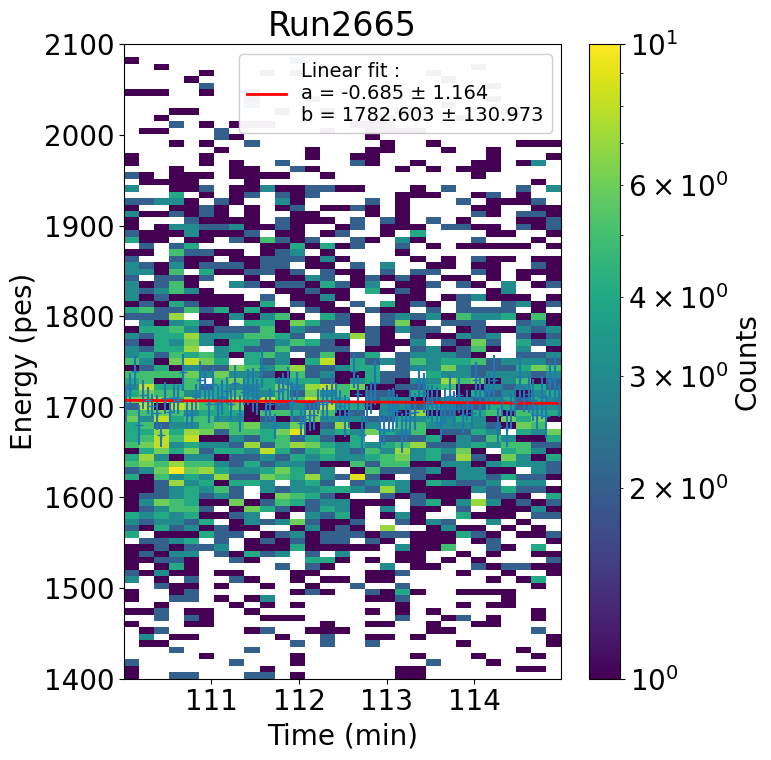

115.00870950146667


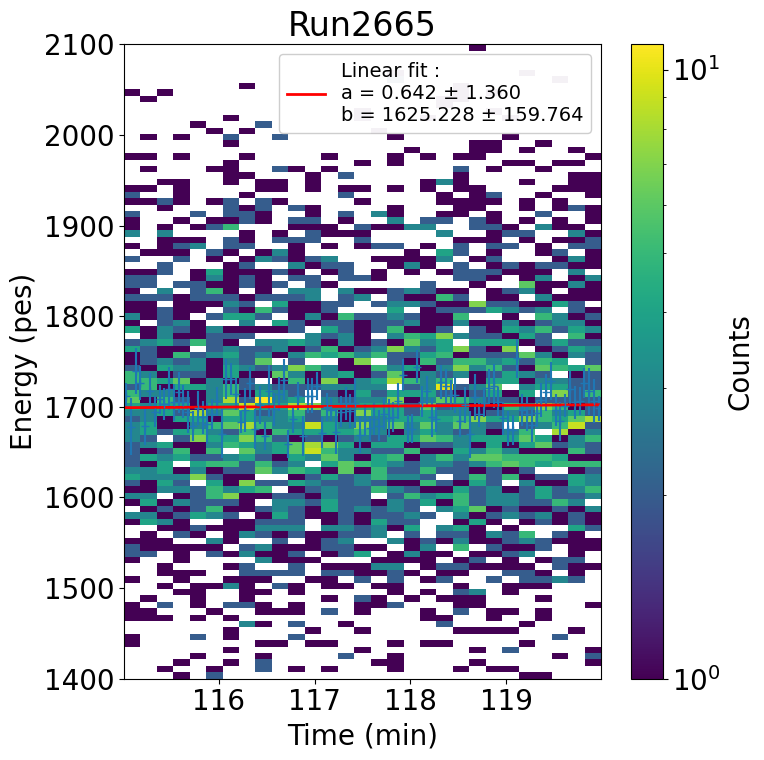

120.00416609693335


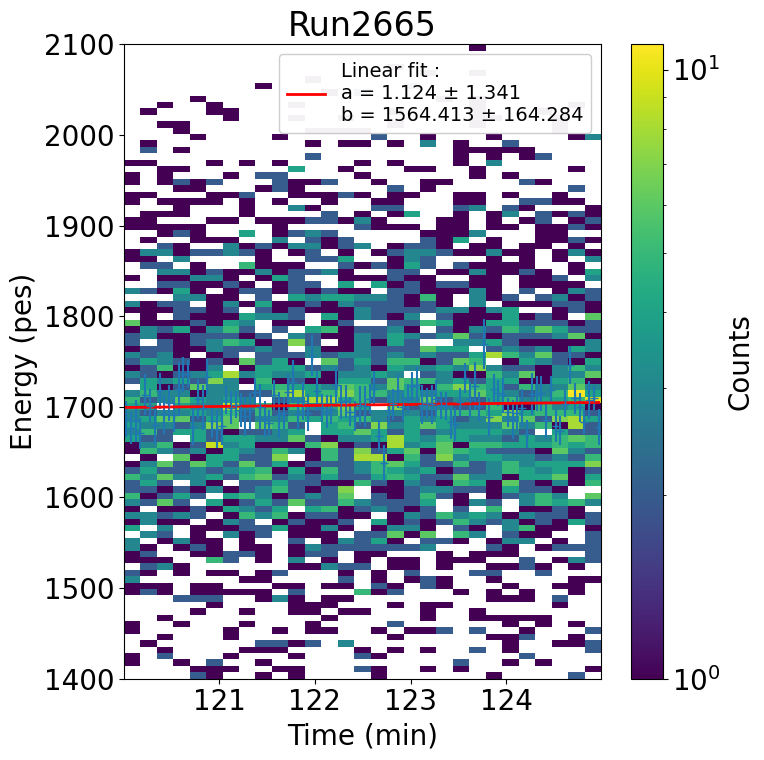

125.00426396200001


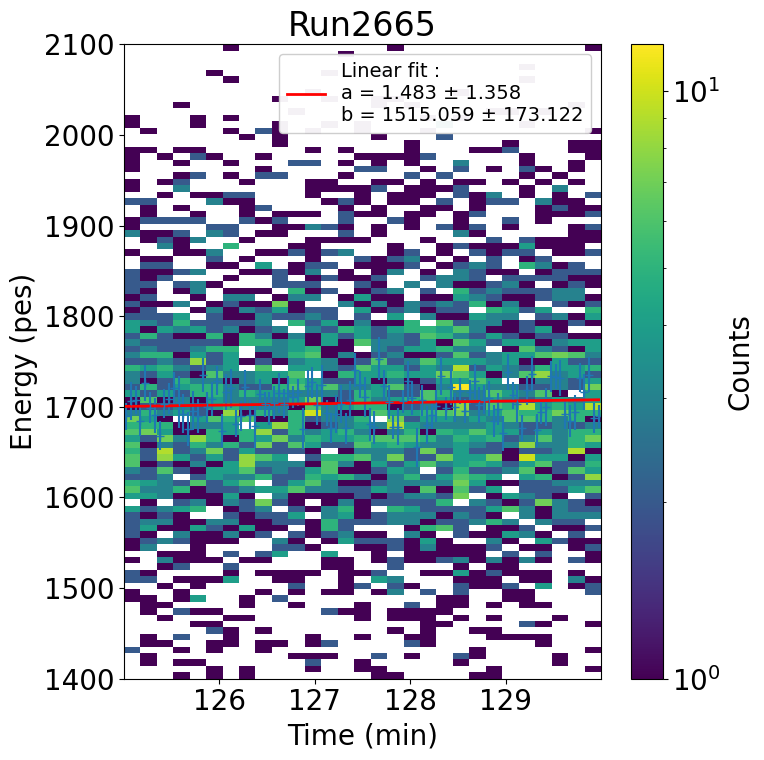

130.0067139598667


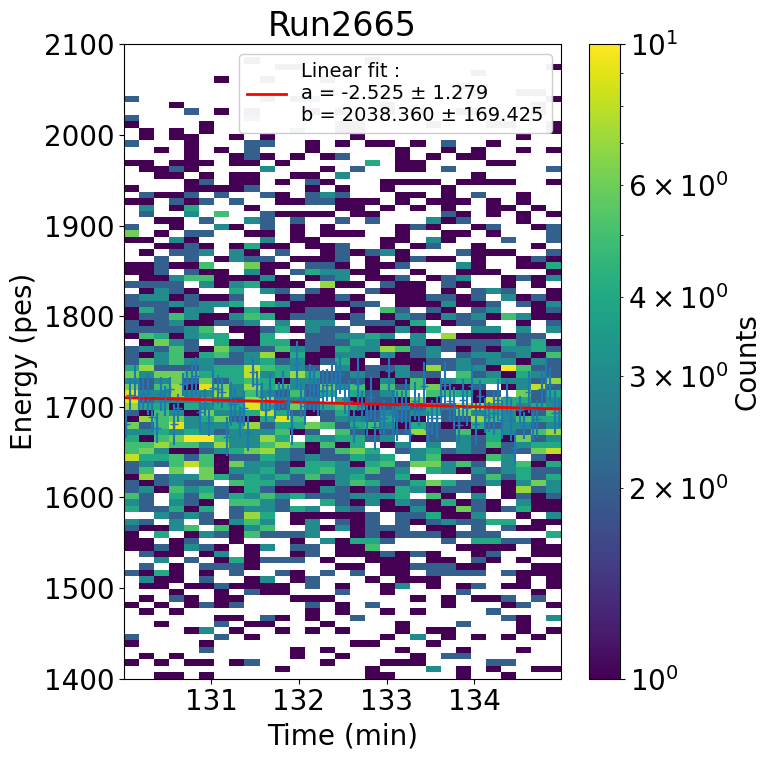

27 27


In [40]:
#To cut runs in periods of time
run_nb = 2665

dst = '/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R'+str(run_nb)+'/octavia/DST_run_'+str(run_nb)+'_pmaps.h5'
dst      = pd.read_hdf(dst, 'WVF')
dst['time_min'] = (dst['timestamp'] - dst['timestamp'].min())*8e-9/60

#print(dst.time_min.max() - dst.time_min.min())

div = 5
max_time = (dst.time_min.max() - dst.time_min.min()) / div
x_axis = []
labels = []
coef_a_store = []
coef_b_store = []
sigma_a_store = []
sigma_b_store = []


for i in range(0, int(max_time)):
    x_axis.append(i)
    
    labels.append(str(i * div)+' - '+str((i+1) * div))
    
    ene_min = 1400
    ene_max = 2100
    
    mask = (dst.time_min >= i * div) & (dst.time_min <= (i+1) * div)
    
    tbins     = np.linspace(np.min(dst.time_min[mask]), np.max(dst.time_min[mask]), 30)
    ebins     = np.linspace(np.min(dst.energy[mask]), np.max(dst.energy), 200)
    erange = [ene_min, ene_max]
    sel1 = np.full(len(dst_rd_hot), True)

    enebins   = np.linspace(ene_min, ene_max, 100)

    plt.figure(figsize=(8, 8))

    h = plt.hist2d(dst.time_min[mask], dst.energy[mask], [tbins, enebins], norm=LogNorm(), cmap='viridis')
    tprof = fitf.profileX(dst.time_min[mask], dst.energy[mask], xrange=[tbins[0], tbins[-1]], yrange=erange, nbins=100)
    plt.errorbar(tprof[0], tprof[1], yerr=tprof[2], linestyle='', marker='+')
    plt.colorbar(h[3], label='Counts')
    x = tprof[0]
    y = tprof[1]

    popt, pcov = np.polyfit(x, y, deg=1, cov=True)
    a, b = popt
    sigma_a, sigma_b = np.sqrt(np.diag(pcov))

    plt.plot(x, a * x + b, '-', label=f'Linear fit :\na = {a:.3f} ± {sigma_a:.3f}\nb = {b:.3f} ± {sigma_b:.3f}', color='red', linewidth=2)
    coef_a_store.append(a)
    coef_b_store.append(b)
    sigma_a_store.append(sigma_a)
    sigma_b_store.append(sigma_b)



    plt.xlabel('Time (min)')
    plt.ylabel('Energy (pes)')
    plt.title('Run'+str(run_nb))
    plt.xlim(np.min(dst.time_min[mask]), np.max(dst.time_min[mask]))
    plt.legend(fontsize=14, framealpha=0.95)
    plt.tight_layout()
    #plt.savefig('/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/Energy_vs_Time/Single_Run_'+str(run_nb[i])+'.png', bbox_inches='tight')


    plt.show()
    
print(len(x_axis), len(labels))

    




In [41]:
#To cut runs in periods of time
from matplotlib.colors import LogNorm

def sample_fit(divtime, run_nb):

    dst = '/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R'+str(run_nb)+'/octavia/DST_run_'+str(run_nb)+'_pmaps.h5'
    dst      = pd.read_hdf(dst, 'WVF')
    dst['time_min'] = (dst['timestamp'] - dst['timestamp'].min())*8e-9/60

    #print(dst.time_min.max() - dst.time_min.min())

    div = divtime
    max_time = (dst.time_min.max() - dst.time_min.min()) / div
    x_axis = []
    labels = []
    coef_a_store = []
    coef_b_store = []
    sigma_a_store = []
    sigma_b_store = []


    for i in range(0, int(max_time)):
        x_axis.append(i)

        labels.append(str(i * div)+' - '+str((i+1) * div))
        ene_min = 1400
        ene_max = 2100

        mask = (dst.time_min >= i * div) & (dst.time_min <= (i+1) * div)
        print(np.min(dst.time_min[mask]))

        tbins     = np.linspace(np.min(dst.time_min[mask]), np.max(dst.time_min[mask]), 30)
        ebins     = np.linspace(np.min(dst.energy[mask]), np.max(dst.energy), 200)
        erange = [ene_min, ene_max]

        enebins   = np.linspace(ene_min, ene_max, 100)

        plt.figure(figsize=(8, 8))

        h = plt.hist2d(dst.time_min[mask], dst.energy[mask], [tbins, enebins], norm=LogNorm(), cmap='viridis')
        tprof = fitf.profileX(dst.time_min[mask], dst.energy[mask], xrange=[tbins[0], tbins[-1]], yrange=erange, nbins=100)
        plt.errorbar(tprof[0], tprof[1], yerr=tprof[2], linestyle='', marker='+')
        plt.colorbar(h[3], label='Counts')
        x = tprof[0]
        y = tprof[1]

        popt, pcov = np.polyfit(x, y, deg=1, cov=True)
        a, b = popt
        sigma_a, sigma_b = np.sqrt(np.diag(pcov))

        plt.plot(x, a * x + b, '-', label=f'Linear fit :\na = {a:.3f} ± {sigma_a:.3f}\nb = {b:.3f} ± {sigma_b:.3f}', color='red', linewidth=2)
        coef_a_store.append(a)
        coef_b_store.append(b)
        sigma_a_store.append(sigma_a)
        sigma_b_store.append(sigma_b)



        plt.xlabel('Time (min)')
        plt.ylabel('Energy (pes)')
        plt.title('Run'+str(run_nb))
        plt.xlim(np.min(dst.time_min[mask]), np.max(dst.time_min[mask]))
        plt.legend(fontsize=14, framealpha=0.95)
        plt.tight_layout()
        #plt.savefig('/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/Energy_vs_Time/Single_Run_'+str(run_nb[i])+'.png', bbox_inches='tight')


        plt.show()
    return run_nb, div, coef_a_store, coef_b_store, sigma_a_store, sigma_b_store, x_axis, labels



0.0


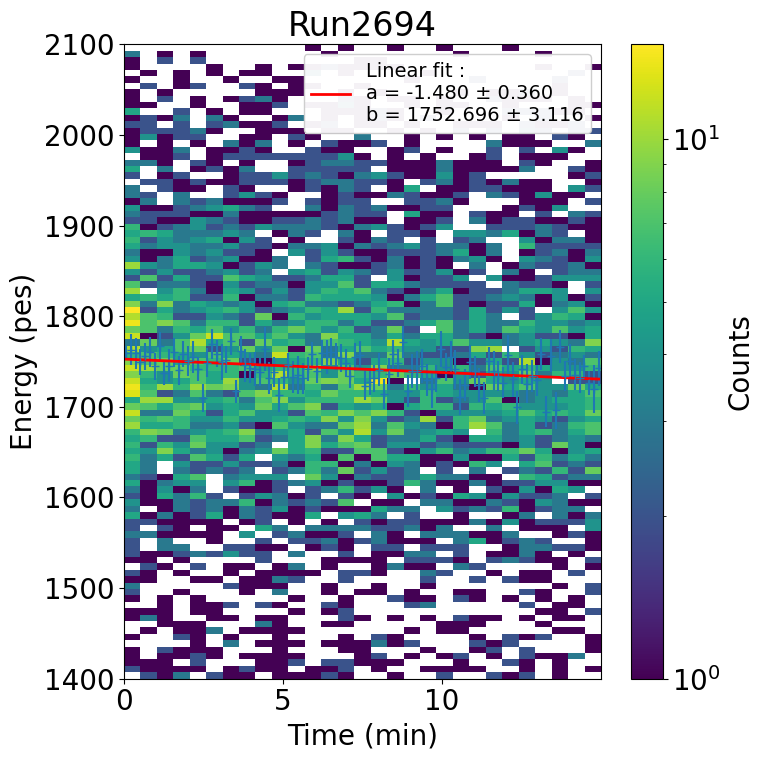

15.006159827866668


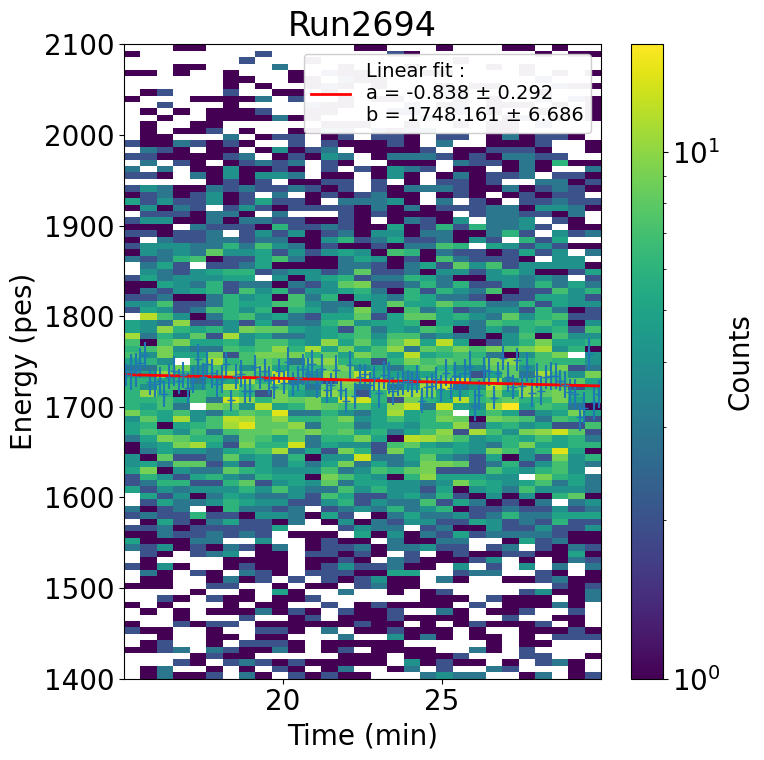

30.00400156466667


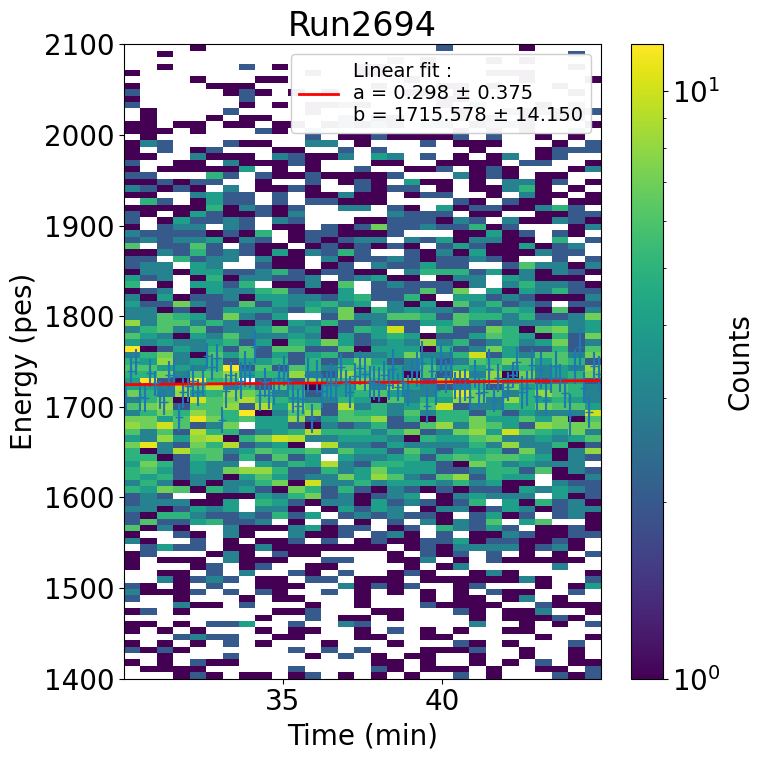

45.00073982053333


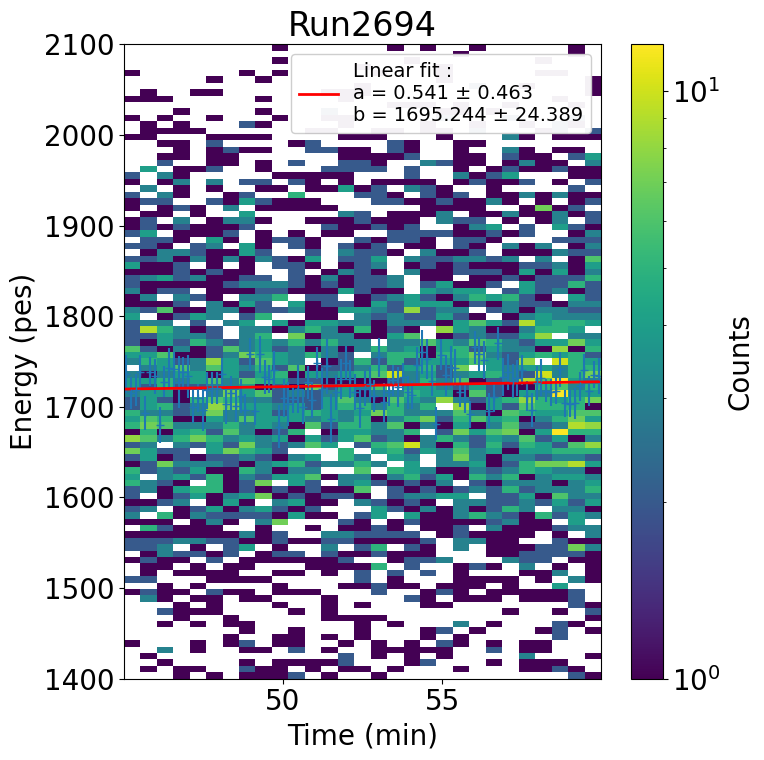

60.00321356773334


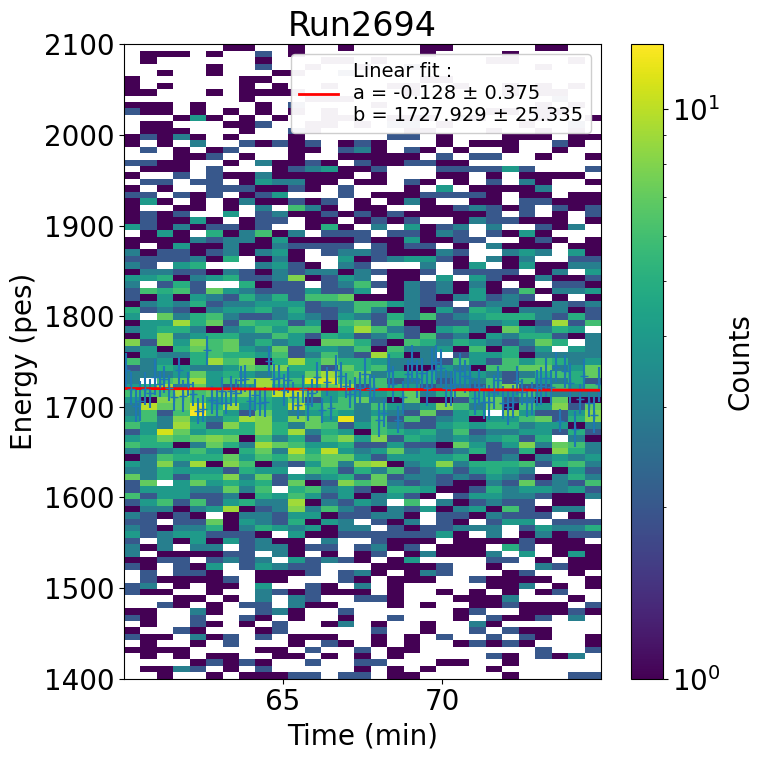

75.01328589746667


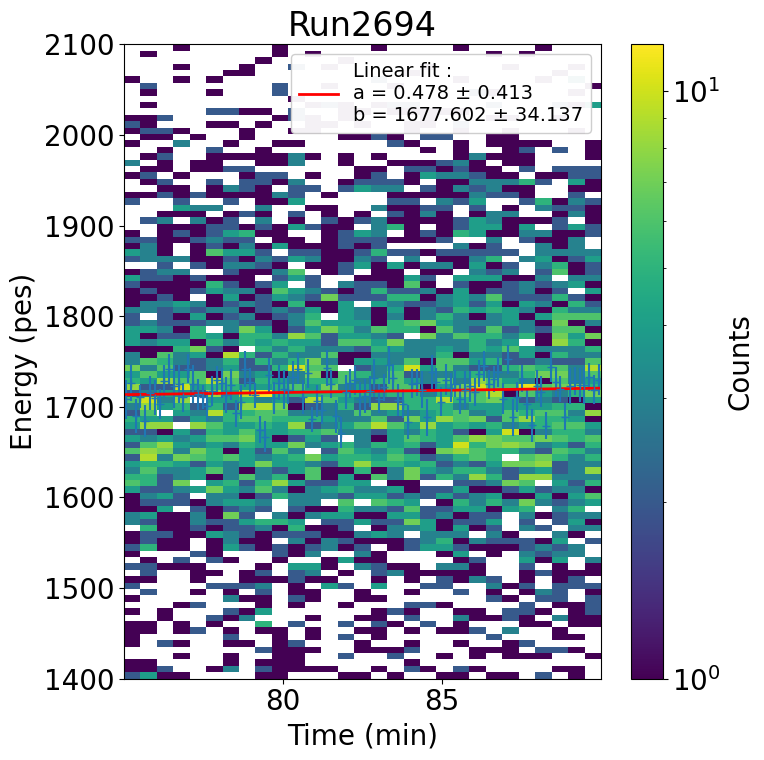

90.00247073266668


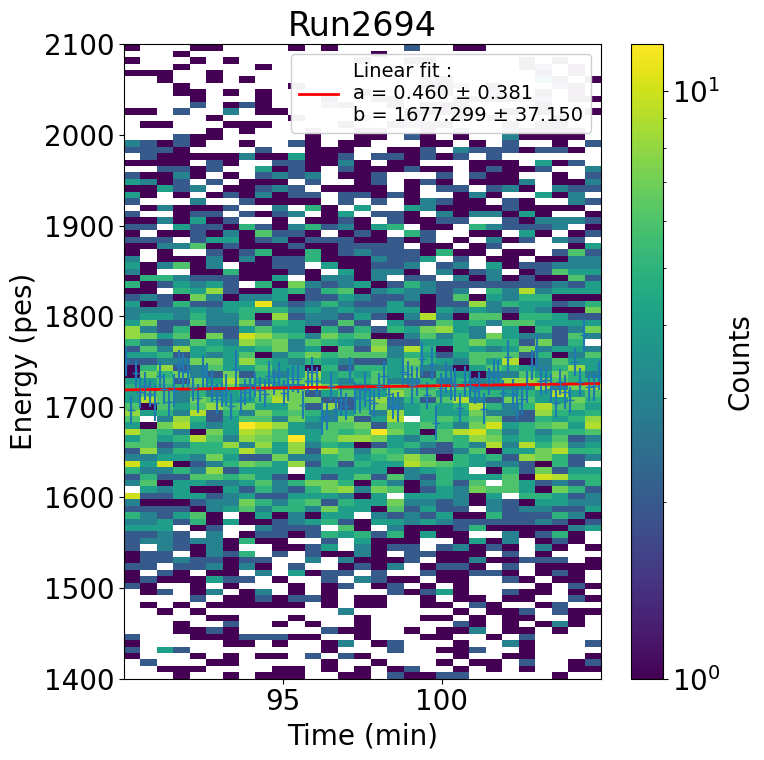

105.01376639213335


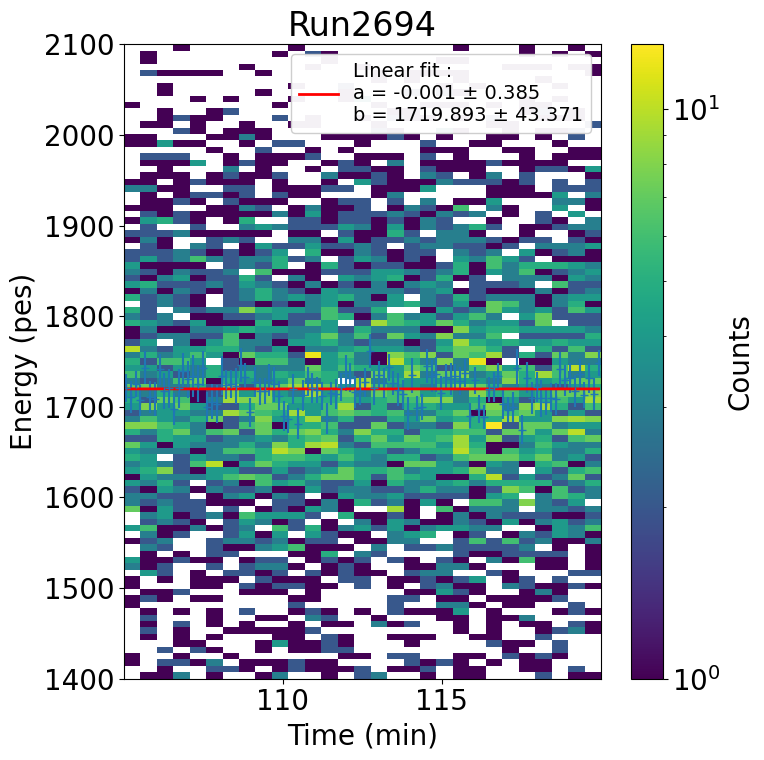

120.00536151720001


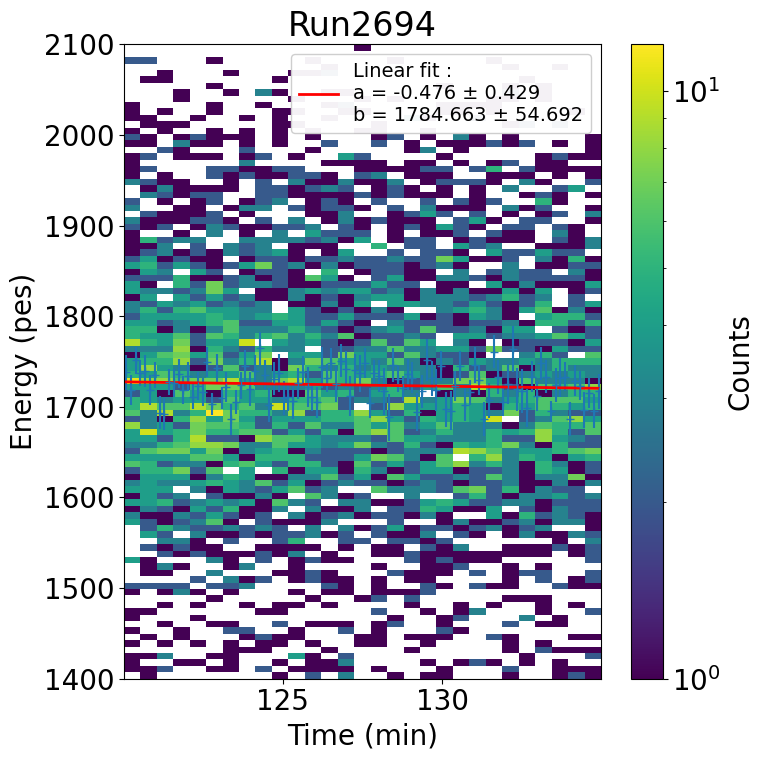

135.01020175946667


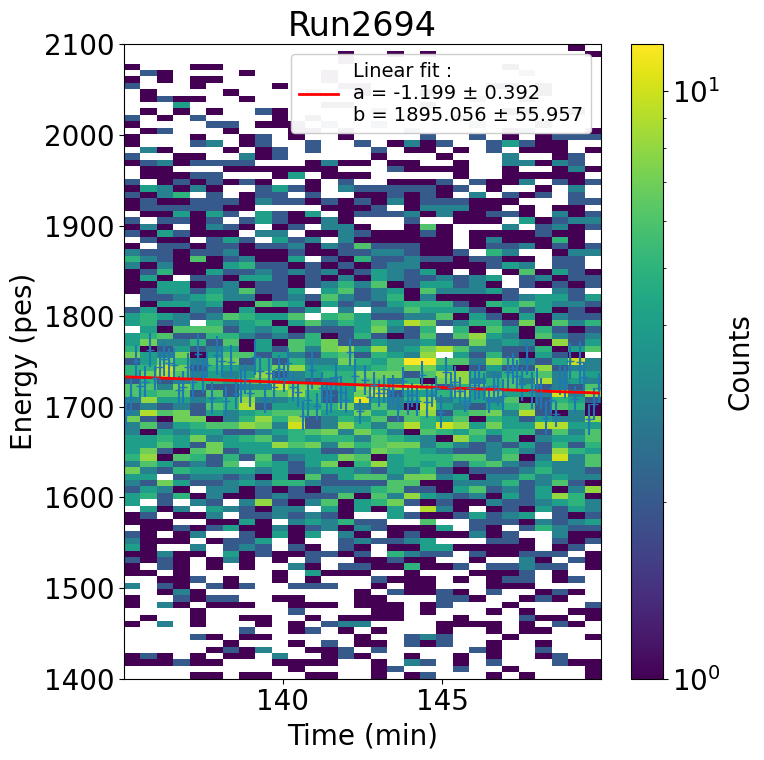

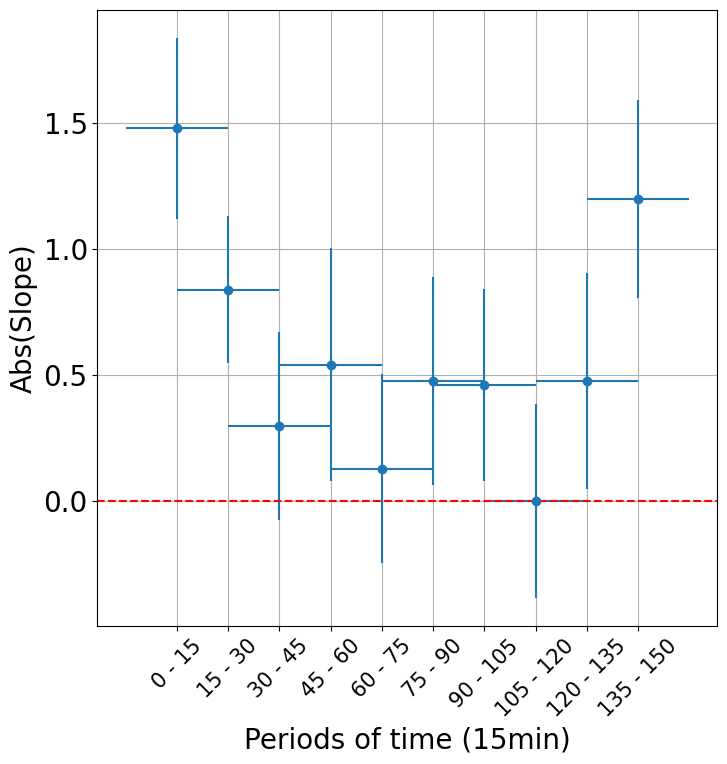

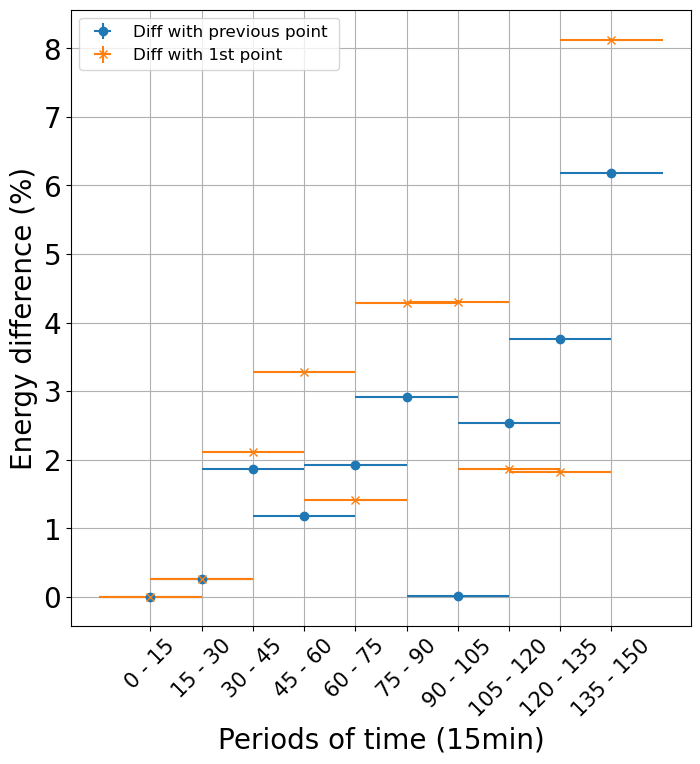

In [93]:
plot_path = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/Energy_vs_Time/'
run = [2694]
div_in = 15


labels_plot = []
for j in range(len(run)):
    
    run_nb, div, coef_a_store, coef_b_store, sigma_a_store, sigma_b_store, x_axis, labels = sample_fit(div_in, run[j])
   
    #print(coef_a_store)
    plt.figure(figsize=(8,8))
    plt.errorbar(x_axis, np.abs(coef_a_store), xerr=1, yerr=sigma_a_store, linestyle='', marker='o')
    plt.xticks(x_axis, labels, fontsize=15, rotation=45)
    plt.ylabel('Abs(Slope)')
    plt.xlabel('Periods of time ('+str(div)+'min)')
    plt.axhline(0, color='red', linestyle='--')
    plt.grid()
    #plt.xlim(, 6)
    plt.savefig(plot_path + 'Slope_vs_samples_of_'+str(div)+'min_'+str(run_nb)+'.png', bbox_inches='tight')

    plt.show()
    plt.figure(figsize=(8,8))

    diff = []
    diff1 = []
    err = []
    err1 = []
    diff.append(0)
    diff1.append(0)

    err.append(np.sqrt((sigma_b_store[0]/coef_b_store[0])**2 + (coef_b_store[0] * sigma_b_store[0]/coef_b_store[0]**2)**2))
    err1.append(np.sqrt((sigma_b_store[0]/coef_b_store[0])**2 + (coef_b_store[0] * sigma_b_store[0]/coef_b_store[0]**2)**2))

    for i in range(1, len(coef_b_store)):
        A = coef_b_store[i]
        B = coef_b_store[i - 1]
        sigA = sigma_b_store[i]
        sigB = sigma_b_store[i - 1]
        ref = np.abs(A - B)
        diff.append(np.abs(ref) * 100 / B)
        err.append(np.sqrt( (sigA/B)**2 + (A*sigB/B**2)**2 ))

        A = coef_b_store[i]
        B = coef_b_store[0]
        sigA = sigma_b_store[i]
        sigB = sigma_b_store[0]
        ref1 = np.abs(A - B)
        diff1.append(np.abs(ref1) * 100 /B) 
        err1.append(np.sqrt( (sigA/B)**2 + (A*sigB/B**2)**2 ))

    plt.errorbar(x_axis, diff, yerr=err, xerr=1, linestyle='', marker='o', label='Diff with previous point ')
    plt.errorbar(x_axis, diff1, yerr=err1, xerr=1, linestyle='', marker='x', label='Diff with 1st point ')
    plt.xticks(x_axis, labels, fontsize=15, rotation=45)
    plt.xlabel('Periods of time ('+str(div)+'min)')
    plt.ylabel('Energy difference (%)')
    plt.legend(loc='upper left', fontsize=12)
    plt.savefig(plot_path + 'Constant_vs_samples_of_'+str(div)+'min_'+str(run_nb)+'.png', bbox_inches='tight')
    plt.grid()
    plt.show()
    

In [ ]:
plt.show()
    plt.figure(figsize=(8,8))

    diff = []
    diff1 = []
    err = []
    err1 = []
    diff.append(0)
    diff1.append(0)

    err.append(np.sqrt((sigma_b_store[0]/coef_b_store[0])**2 + (coef_b_store[0] * sigma_b_store[0]/coef_b_store[0]**2)**2))
    err1.append(np.sqrt((sigma_b_store[0]/coef_b_store[0])**2 + (coef_b_store[0] * sigma_b_store[0]/coef_b_store[0]**2)**2))

    for i in range(1, len(coef_b_store)):
        A = coef_b_store[i]
        B = coef_b_store[i - 1]
        sigA = sigma_b_store[i]
        sigB = sigma_b_store[i - 1]
        ref = np.abs(A - B)
        diff.append(np.abs(ref) * 100 / B)
        err.append(np.sqrt( (sigA/B)**2 + (A*sigB/B**2)**2 ))

        A = coef_b_store[i]
        B = coef_b_store[0]
        sigA = sigma_b_store[i]
        sigB = sigma_b_store[0]
        ref1 = np.abs(A - B)
        diff1.append(np.abs(ref1) * 100 /B) 
        err1.append(np.sqrt( (sigA/B)**2 + (A*sigB/B**2)**2 ))

    plt.errorbar(x_axis, diff, yerr=err, xerr=1, linestyle='', marker='o', label='Diff with previous point ')
    plt.errorbar(x_axis, diff1, yerr=err1, xerr=1, linestyle='', marker='x', label='Diff with 1st point ')
    plt.xticks(x_axis, labels, fontsize=15, rotation=45)
    plt.xlabel('Periods of time ('+str(div)+'min)')
    plt.ylabel('Energy difference (%)')
    plt.legend(loc='upper left', fontsize=12)
    plt.savefig(plot_path + 'Constant_vs_samples_of_'+str(div)+'min_'+str(run_nb)+'.png', bbox_inches='tight')
    plt.grid()
    plt.show()


    print(plot_path)

3.254788888888889e-06
0.2834066244933333
<bound method NDFrame._add_numeric_operations.<locals>.max of 0       8.492605
1       2.923518
2     -25.513470
3     -43.610921
4      -1.691438
         ...    
995   -20.032506
996     0.478941
997    64.202452
998    -4.737159
999    -0.248210
Name: energy, Length: 31716, dtype: float64>


/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_3257/3999452677.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


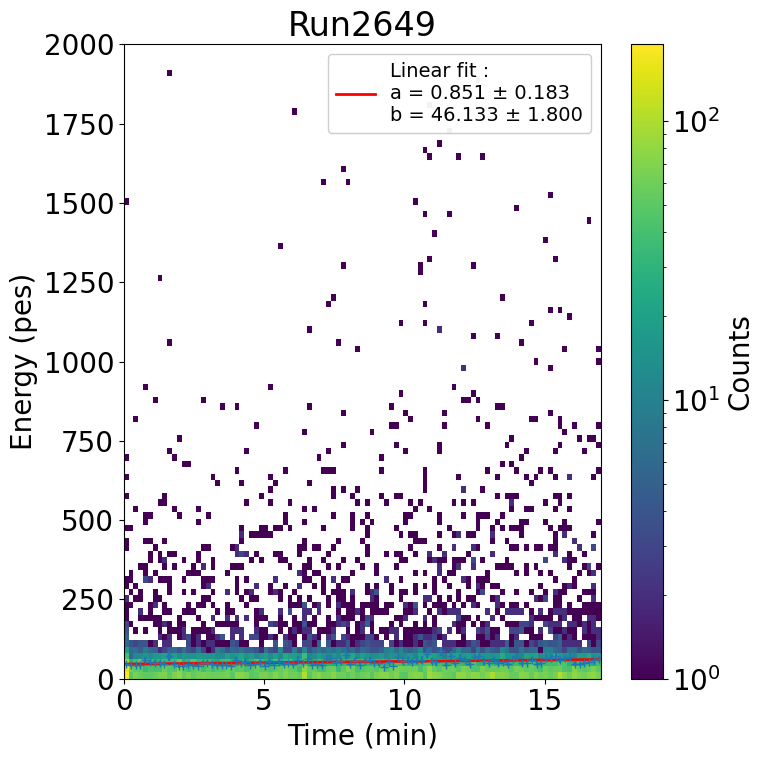

4.196066666666667e-07
0.24828322810000003
<bound method NDFrame._add_numeric_operations.<locals>.max of 0      10.848687
1     -32.364135
2      -7.307241
3      16.538792
4      48.968970
         ...    
995    38.300136
996     5.666116
997   -20.230512
998    35.028730
999    26.504331
Name: energy, Length: 31663, dtype: float64>


/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_3257/3999452677.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


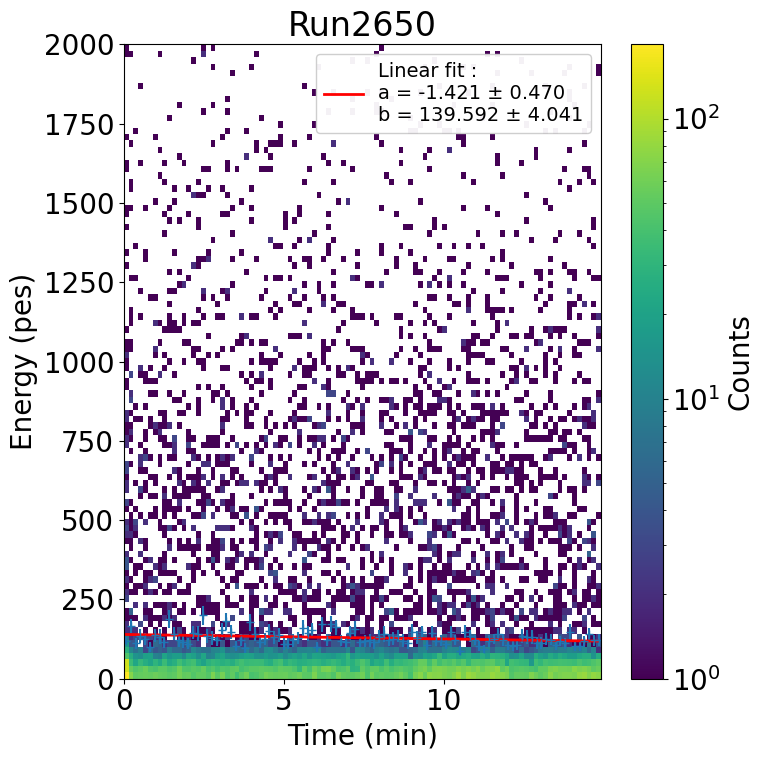

1.931777777777778e-07
0.24861773015333336
<bound method NDFrame._add_numeric_operations.<locals>.max of 0        23.830693
1        31.338908
2       -29.983573
3      2582.971859
4       226.741339
          ...     
995     171.211351
996     -14.085820
997      -7.265235
998      49.281683
999     195.210026
Name: energy, Length: 35720, dtype: float64>


/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_3257/3999452677.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


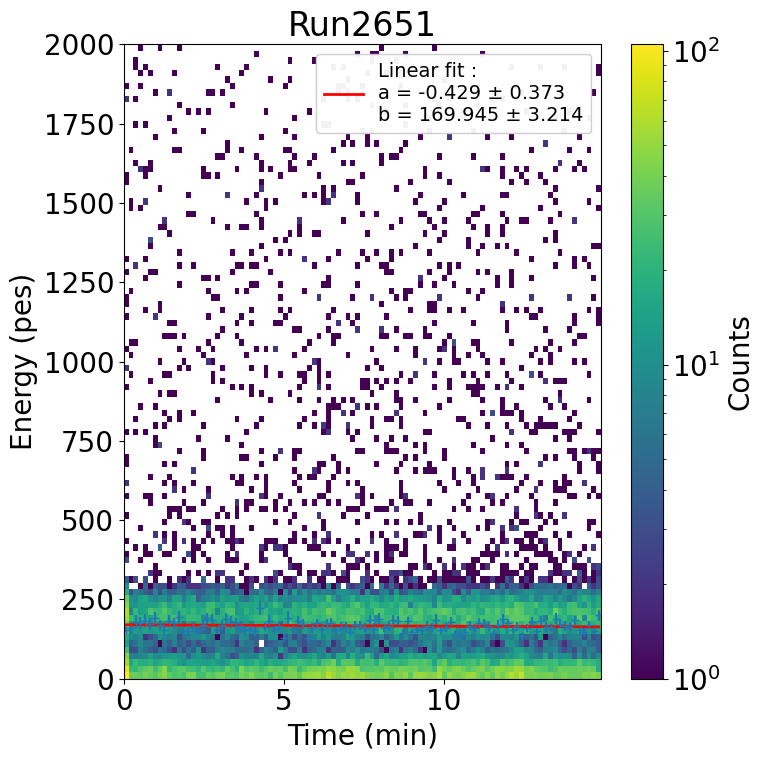

1.3639733333333332e-06
1.4413201858755558
<bound method NDFrame._add_numeric_operations.<locals>.max of 0       40.228721
1      -63.784195
2       59.186954
3      524.379519
4      527.925156
          ...    
995    566.404376
996    592.714861
997    643.083446
998    596.467133
999    622.476968
Name: energy, Length: 185000, dtype: float64>


/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_3257/3999452677.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


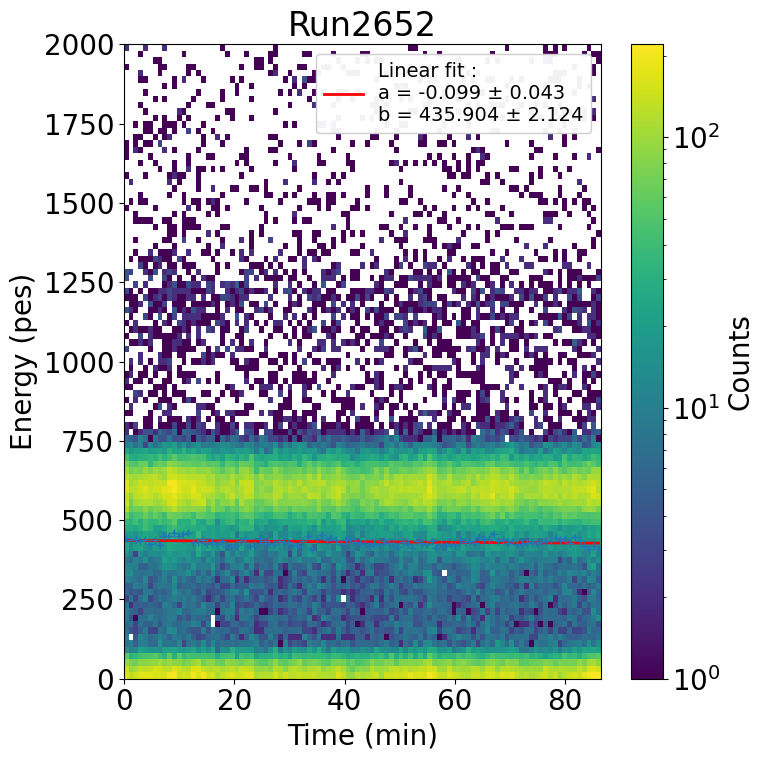

8.172511111111111e-07
0.34524720515777785
<bound method NDFrame._add_numeric_operations.<locals>.max of 0      1028.187694
1      1146.846896
2      1094.155271
3        78.308159
4        34.238727
          ...     
995      18.385864
996      -3.903980
997     -10.354380
998    1054.245414
999    1216.395209
Name: energy, Length: 53223, dtype: float64>


/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_3257/3999452677.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


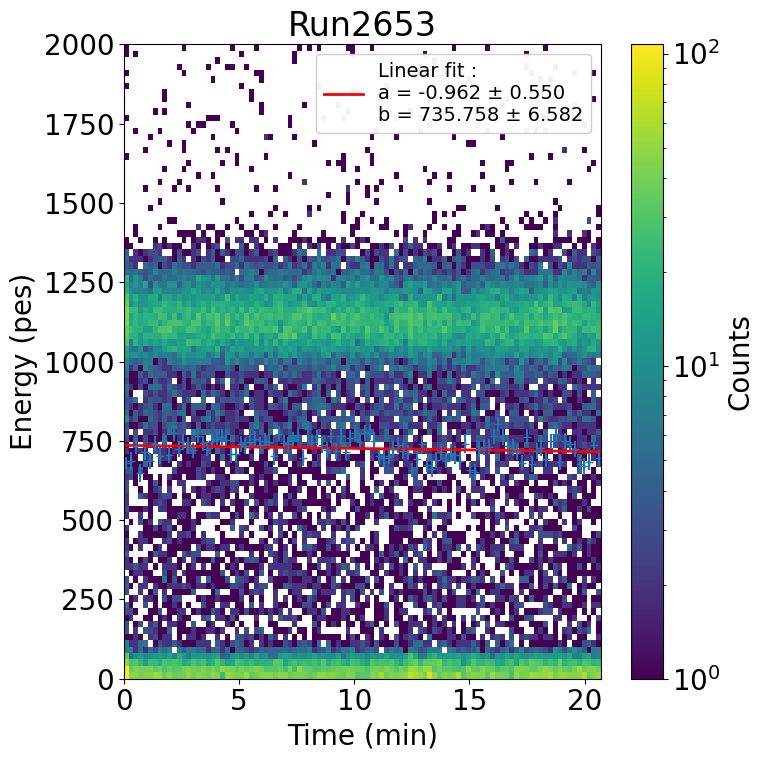

1.015888888888889e-07
0.21486316801333336
<bound method NDFrame._add_numeric_operations.<locals>.max of 0        10.457923
1      1691.914306
2       147.261841
3       429.447991
4        -6.980194
          ...     
114    1800.670550
115    1716.853894
116    1848.582377
117     490.516686
118      41.760565
Name: energy, Length: 30119, dtype: float64>


/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_3257/3999452677.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


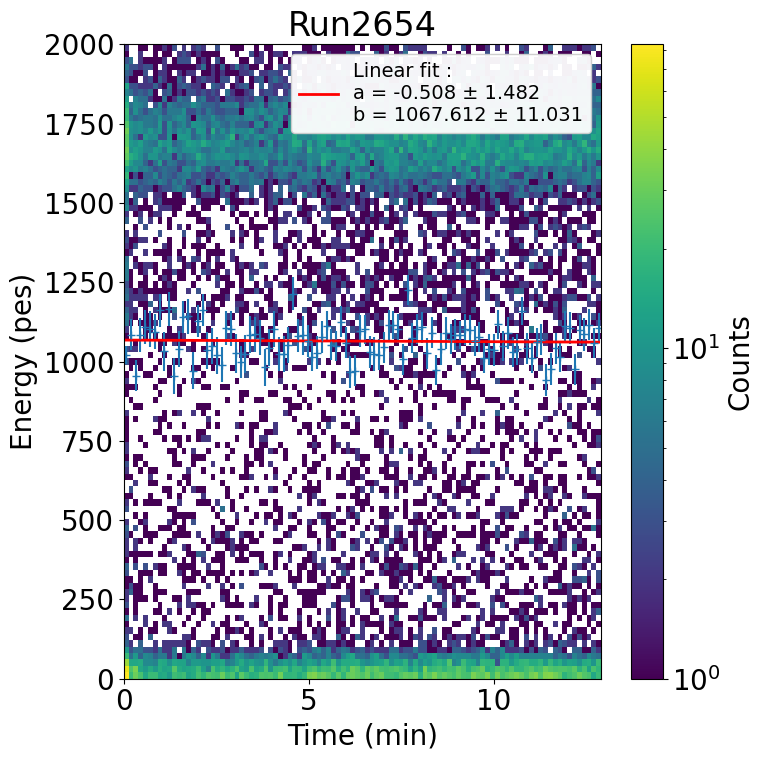

9.502888888888889e-07
0.21586915356666667
<bound method NDFrame._add_numeric_operations.<locals>.max of 0      2299.258326
1       -31.638157
2         5.010710
3         3.480600
4        48.318701
          ...     
447    2153.767564
448     475.315245
449    2171.557890
450    2145.181153
451      90.875915
Name: energy, Length: 34452, dtype: float64>


/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_3257/3999452677.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


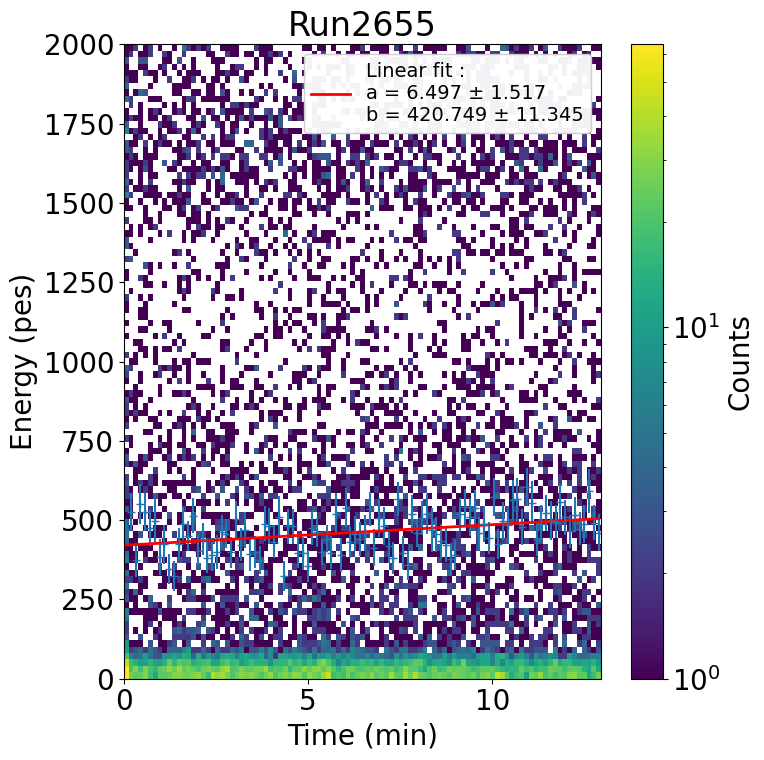

6.765022222222222e-07
0.21476333271333337
<bound method NDFrame._add_numeric_operations.<locals>.max of 0        151.643577
1        -27.786507
2         41.852759
3         42.084228
4         48.149296
           ...     
855     2235.413072
856    31408.624686
857      367.277984
858     2713.206756
859     3020.257113
Name: energy, Length: 31860, dtype: float64>


/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_3257/3999452677.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


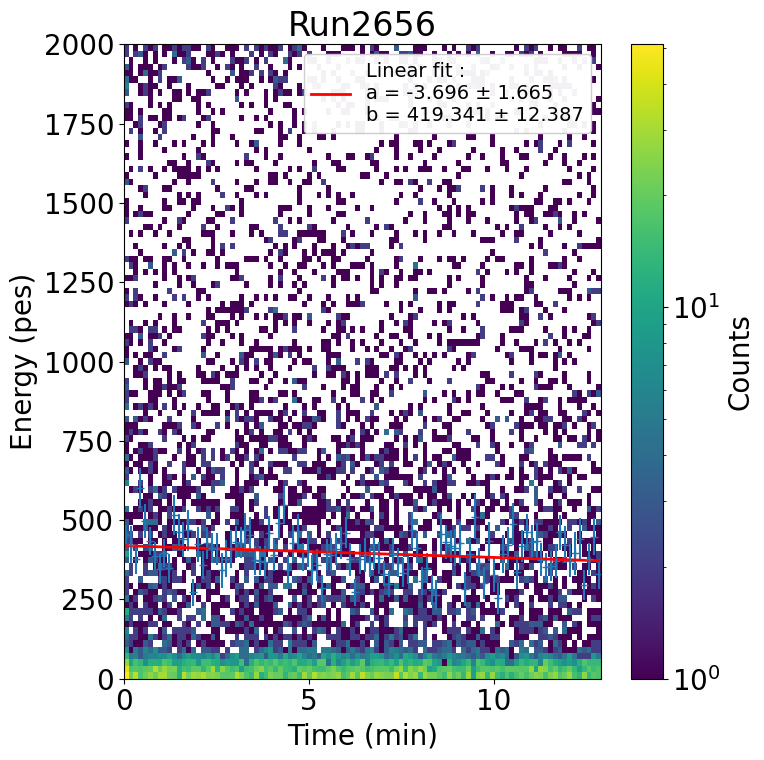

6.765777777777778e-07
0.21581428828666668
<bound method NDFrame._add_numeric_operations.<locals>.max of 0        44.229213
1       -19.898592
2        39.660324
3       -10.319569
4         8.582584
          ...     
995    2890.125873
996    3408.809488
997      35.968424
998      54.953164
999       3.915382
Name: energy, Length: 30275, dtype: float64>


/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_3257/3999452677.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


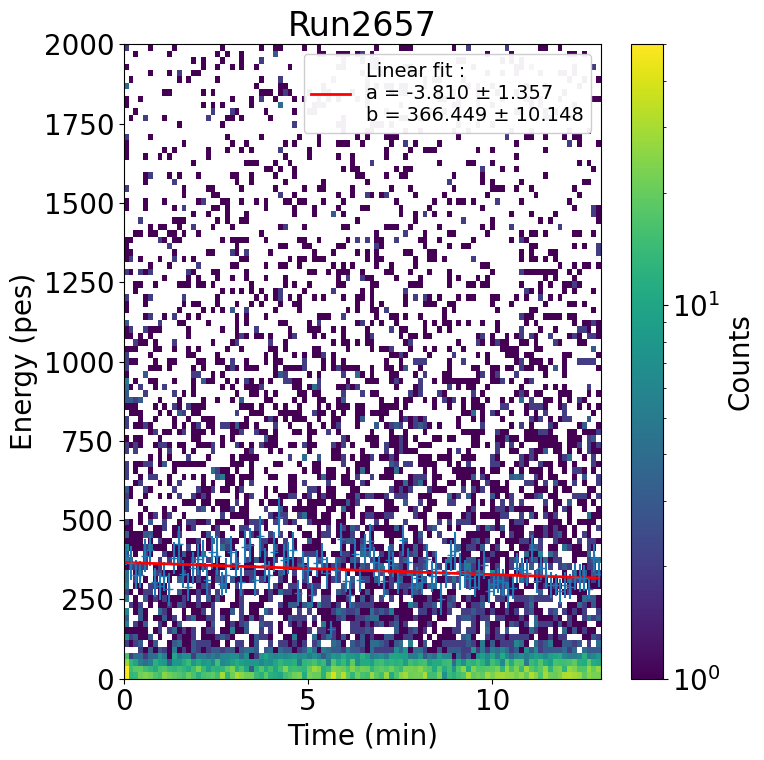

2.1048000000000002e-07
0.2356748789466667
<bound method NDFrame._add_numeric_operations.<locals>.max of 0         58.696578
1       3974.449668
2        224.908271
3      17693.492032
4         60.559455
           ...     
995        7.474240
996    11114.455170
997       63.145962
998       37.390994
999     3598.045957
Name: energy, Length: 32906, dtype: float64>


/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_3257/3999452677.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


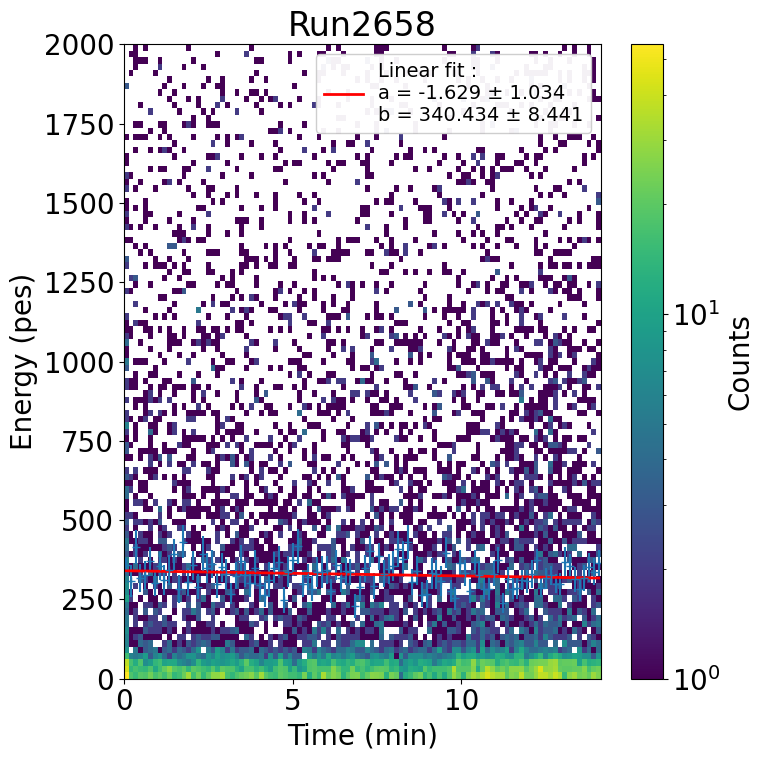

4.352666666666667e-08
0.21542579950444446
<bound method NDFrame._add_numeric_operations.<locals>.max of 0        -5.865306
1        27.697917
2        14.311423
3        26.124512
4        26.231695
          ...     
995      90.712113
996    2999.746287
997     -15.411052
998     -30.080742
999      30.028801
Name: energy, Length: 33313, dtype: float64>


/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_3257/3999452677.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60


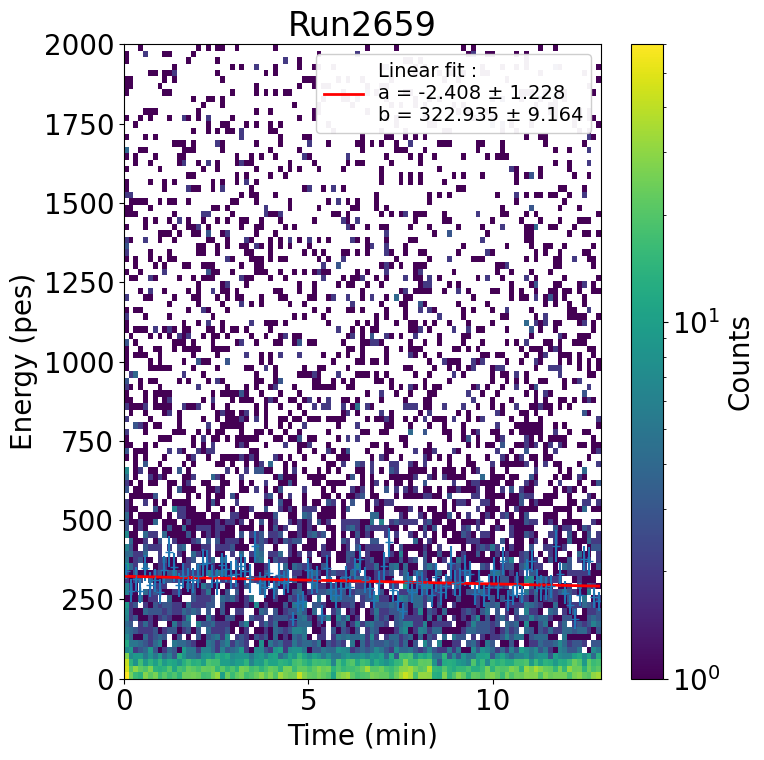

In [46]:
#To have look to a run separated in different samples of time to apply cut on unstable 
#periods (mainly due to when we switch on things)

from matplotlib.colors import LogNorm
all_run = runs
coef_a_store = []
sigma_a_store = []
coef_b_store = []
sigma_b_store = []

for run in range(len(all_run)):
    run_nb = [all_run[run]]
    
    ene_min = 0
    ene_max = 2000 #scale of the plot
    
    for i in range(len(run_nb)):
        dst_hot = '/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R'+str(run_nb[i])+'/octavia/DST_run_'+str(run_nb[i])+'_pmaps.h5'
        dst_hot      = pd.read_hdf(dst_hot, 'WVF')

        dst_rd_hot = dst_hot[['timestamp', 'energy']]
        print(dst_rd_hot['timestamp'].min()*8e-9/(60*60))
        print(dst_rd_hot['timestamp'].max()*8e-9/(60*60))


        #dst_rd_cold = dst_cold[['timestamp', 'energy']]
        dst_rd_hot['time'] = (dst_rd_hot['timestamp'] - dst_rd_hot['timestamp'].min())*8e-9/60
        print(dst_rd_hot['time'].max)
        tbins     = np.linspace(dst_rd_hot['time'].min(), dst_rd_hot['time'].max(), 100)
        ebins     = np.linspace(dst_rd_hot['energy'].min(),dst_rd_hot['energy'].max(), 1000)
        erange = [ene_min, ene_max]
        sel1 = np.full(len(dst_rd_hot), True)

        enebins   = np.linspace(ene_min, ene_max, 100)

        plt.figure(figsize=(8, 8))
        
        h = plt.hist2d(dst_rd_hot['time'], dst_rd_hot['energy'], [tbins, enebins], norm=LogNorm(), cmap='viridis')
        tprof = fitf.profileX(dst_rd_hot['time'], dst_rd_hot['energy'], xrange=[tbins[0], tbins[-1]], yrange=erange, nbins=100)
        plt.errorbar(tprof[0], tprof[1], yerr=tprof[2], linestyle='', marker='+')
        plt.colorbar(h[3], label='Counts')
        x = tprof[0]
        y = tprof[1]

        popt, pcov = np.polyfit(x, y, deg=1, cov=True)
        a, b = popt
        sigma_a, sigma_b = np.sqrt(np.diag(pcov))

        plt.plot(x, a * x + b, '-', label=f'Linear fit :\na = {a:.3f} ± {sigma_a:.3f}\nb = {b:.3f} ± {sigma_b:.3f}', color='red', linewidth=2)
        coef_a_store.append(a)
        coef_b_store.append(b)
        sigma_a_store.append(sigma_a)
        sigma_b_store.append(sigma_b)
        


        plt.xlabel('Time (min)')
        plt.ylabel('Energy (pes)')
        plt.title('Run'+str(run_nb[i]))
        plt.xlim(np.min(dst_rd_hot['time']), np.max(dst_rd_hot['time']))
        plt.legend(fontsize=14, framealpha=0.95)
        plt.tight_layout()
        #plt.savefig('/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/Energy_vs_Time/Single_Run_'+str(run_nb[i])+'.png', bbox_inches='tight')


        plt.show()



In [99]:
import numpy as np
from scipy.interpolate import make_interp_spline
import matplotlib.pyplot as plt
%matplotlib inline

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


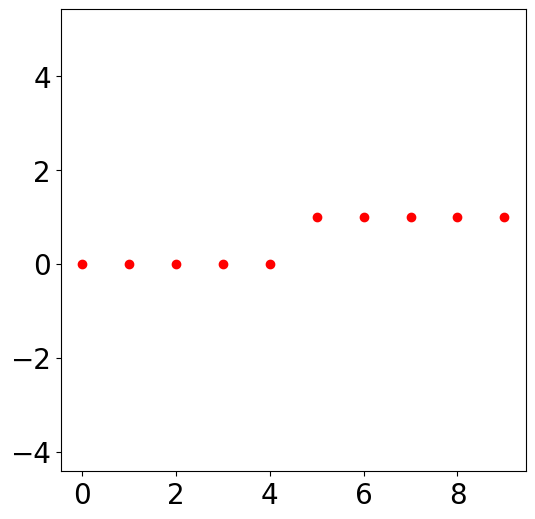

In [144]:
x = np.arange(10, dtype=float)
print(x)
y = np.zeros_like(x)
print(y)
y[5:] = 1.

plt.figure(figsize=(6,6))
plt.plot(x,y,'ro')
plt.axis('equal');

In [113]:
# Simple (default) spline
cs = make_interp_spline(x,y)

In [124]:


# It returns a function
cs
print(cs)


In [115]:


cs(3.5)



array(-0.10060976)

In [116]:


cs([5.3, 2.11])



array([1.10397561, 0.0060889 ])

In [146]:
print(x, y)

xx = np.linspace(x[0],x[-1],100)
yy = [cs(x) for x in xx]
print(xx, yy)


[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.] [0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]
[0.         0.09090909 0.18181818 0.27272727 0.36363636 0.45454545
 0.54545455 0.63636364 0.72727273 0.81818182 0.90909091 1.
 1.09090909 1.18181818 1.27272727 1.36363636 1.45454545 1.54545455
 1.63636364 1.72727273 1.81818182 1.90909091 2.         2.09090909
 2.18181818 2.27272727 2.36363636 2.45454545 2.54545455 2.63636364
 2.72727273 2.81818182 2.90909091 3.         3.09090909 3.18181818
 3.27272727 3.36363636 3.45454545 3.54545455 3.63636364 3.72727273
 3.81818182 3.90909091 4.         4.09090909 4.18181818 4.27272727
 4.36363636 4.45454545 4.54545455 4.63636364 4.72727273 4.81818182
 4.90909091 5.         5.09090909 5.18181818 5.27272727 5.36363636
 5.45454545 5.54545455 5.63636364 5.72727273 5.81818182 5.90909091
 6.         6.09090909 6.18181818 6.27272727 6.36363636 6.45454545
 6.54545455 6.63636364 6.72727273 6.81818182 6.90909091 7.
 7.09090909 7.18181818 7.27272727 7.36363636 7.45454545 7.54545455
 7.63636364 7.

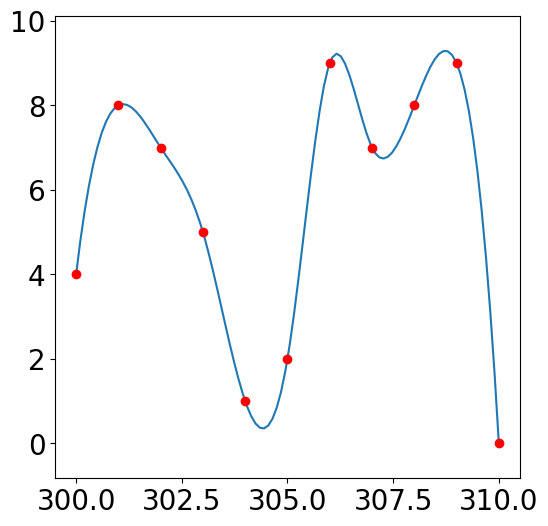

In [127]:
plt.figure(figsize=(6,6))

plt.plot(xx,yy)
plt.plot(x,y, 'ro')
plt.axis('equal');



In [128]:


# Spline with specified boundary conditions
left = [(1,1)]  # First deriv = 1
right = [(1,-10.2)] # First deriv = -10.2
cs = make_interp_spline(x,y, bc_type=(left, right))



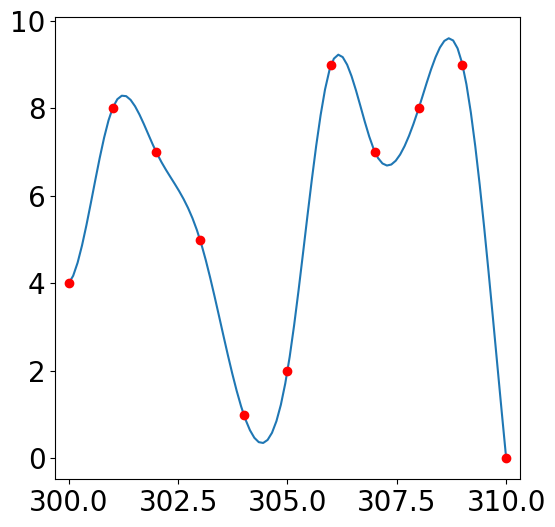

In [129]:

plt.figure(figsize=(6,6))
xx = np.linspace(x[0],x[-1],100)
yy = [cs(x) for x in xx]
plt.plot(xx,yy)
plt.plot(x,y, 'ro')
plt.axis('equal');



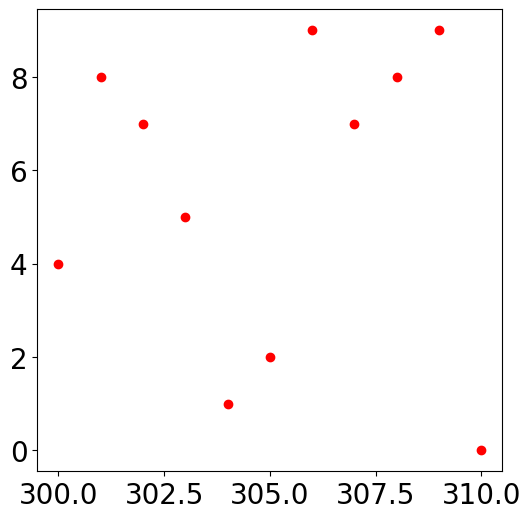

In [149]:
plt.figure(figsize=(6,6))
y = [4, 8, 7, 5, 1, 2, 9, 7, 8, 9, 0]
N = len(y)
x = np.arange(300, N+300)

plt.plot(x, y, 'ro');


In [150]:


cs = make_interp_spline(x, y)



[-2, 8, 7, 5, 1, 2, 9, 7, 8, 9, 0]


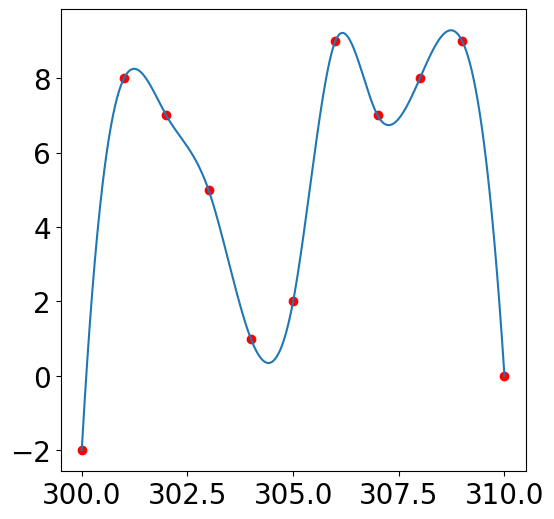

In [168]:
plt.figure(figsize=(6,6))

xx = np.linspace(x[0], x[-1], 1000)
y = [-2, 8, 7, 5, 1, 2, 9, 7, 8, 9, 0]
cs = make_interp_spline(x, y)
plt.plot(x, y, 'ro')
print(y)
plt.plot(xx, cs(xx));
#plt.savefig('spline_example.png')

